# **The Single-File Test: Longitudinal Evaluation of LLM Web Generation Under a First-Output-Only and Social Protocol**

This research studies how frontier LLMs generate complete, web applications when tested exclusively through their public web UIs, mirroring how non-technical end users naturally interact with these systems. It focuses on first-output reliability, holistic application quality, and how technical performance translates into real-world social engagement.

---

### **Supervised Learning ML**



#### **Data:** `12/10/2025 - 02/04/2026`


#### **Code:** [Github](https://github.com/diegocp01/html_ai_battle)


#### **By:** [Diego Cabezas](https://x.com/diegocabezas01)

---

### **Dataset:** [<button style="background-color: #4CAF50; color: white; padding: 10px 20px; text-align: center; text-decoration: none; display: inline-block; font-size: 16px;">Dataset file</button>](https://docs.google.com/spreadsheets/d/1txE-fjK28aDZmN_uMXsaONNofNVAhD1K/edit?usp=sharing&ouid=111148286428280258126&rtpof=true&sd=true)


## Scope

- The tracker currently contains **17 complete experiments** (`68 rows = 17 experiments × 4 models`).


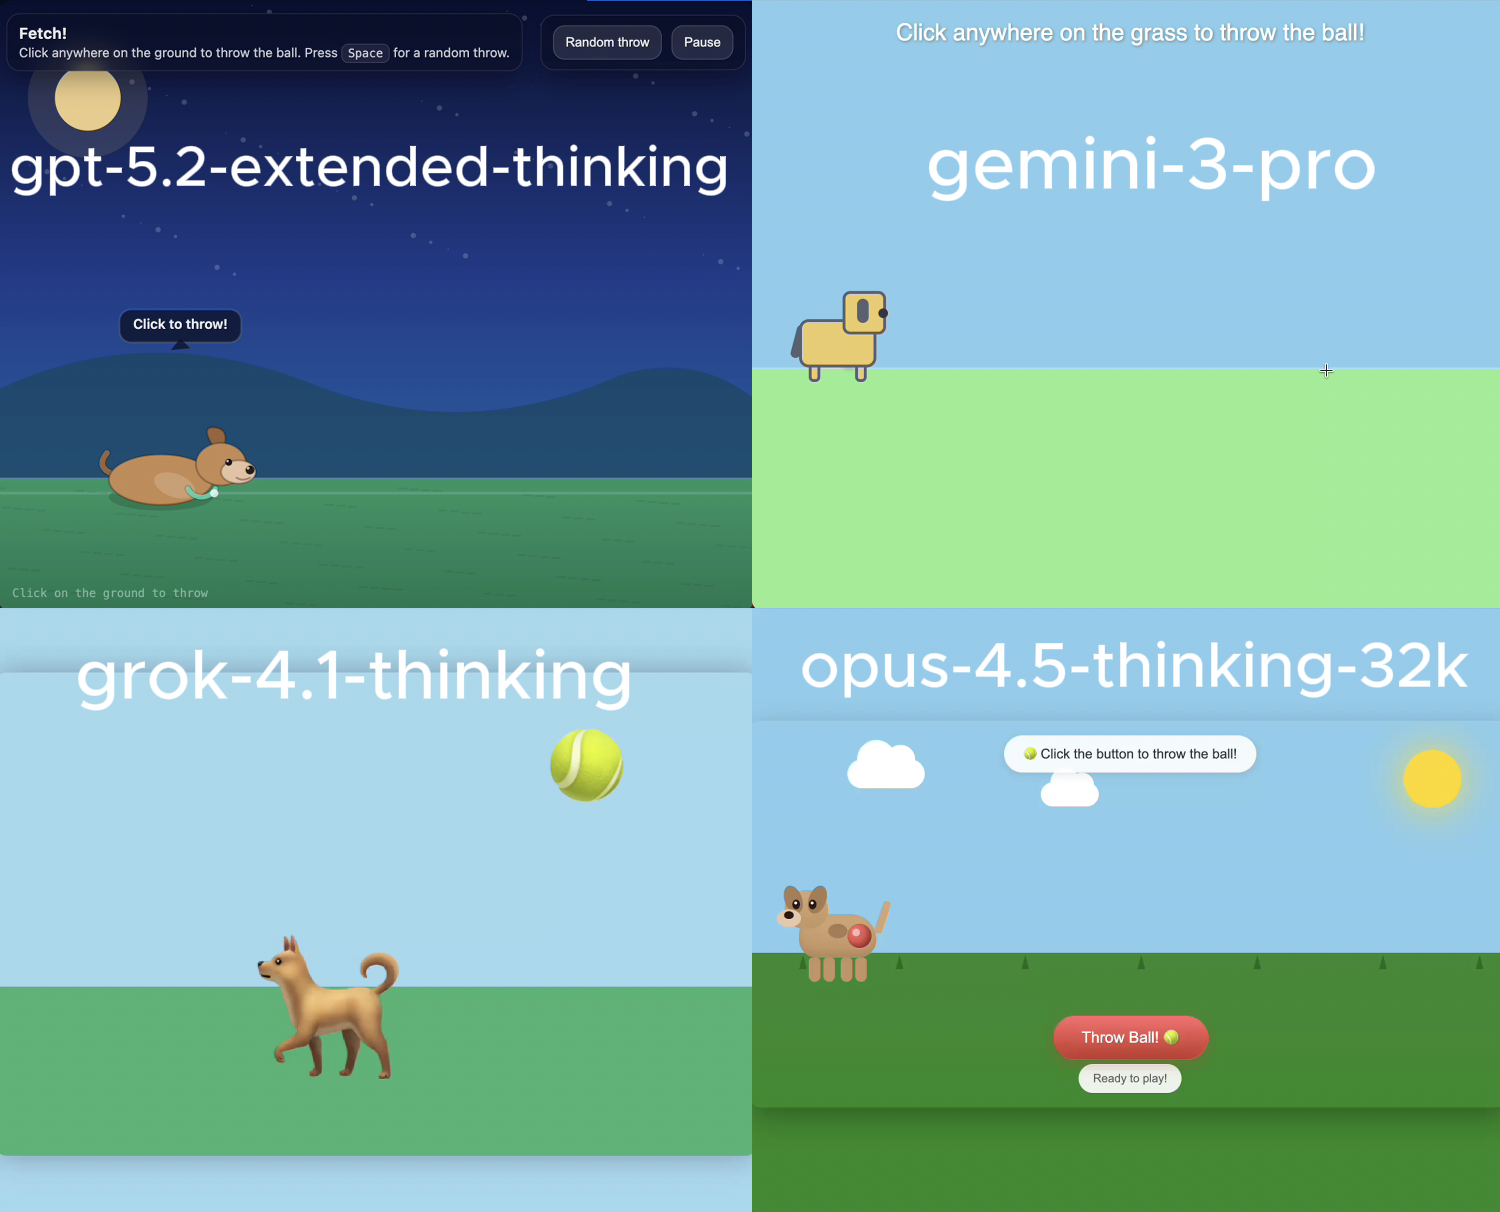

## Predicting Virality from Technical Generation Metrics

**Goal:** Given a single “HTML AI Battle” experiment, this project aims to quantify which **technical generation parameters** (e.g., model reasoning time, code verbosity, audio engine) actually drive **24-hour engagemen**t on X (Twitter). Unlike standard social media analysis that focuses on hashtags or posting times, this study isolates the **intrinsic properties of the AI-generated content** to see if "smarter" models or "complex" code correlate with real-world attention.

**Methodology:** Due to the micro-dataset size ($N=17$ experiments), we utilize **Ridge Regression (L2 Regularization)** validated via **Leave-One-Out Cross-Validation (LOOCV)**. This approach prevents overfitting while allowing us to measure the directional impact of our technical features on social reach.

**Target Variable (Log-Regression):**

* **$\log(1 + \text{X Impressions})$:** We apply a log transformation to X Impressions (24 h) to stabilize the heavy-tailed distribution caused by extreme viral outliers (ranging from 214 to 206,000 impressions).

**Selected Features (Technical & Audio):** We narrowed our feature space to four key pre-publication variables:

* **ReasonTime_mean:** The average time (seconds) models spent "thinking" before generating code.
* **Reasoning_Ratio_mean:** The percentage of total inference time dedicated to reasoning vs. generating.
* **Suno_version:** Binary encoding of the AI audio engine used (v5 vs. v4.5).
* **Song_BPM:** The tempo of the background track.

**Key Hypothesis Tested:** Does "better" code (higher human evaluation scores) or "deeper" thought (longer reasoning time) translate to higher social media engagement? Or is virality decoupled from technical quality?

# Table of Contents
- [ 1 - Exploratory Data Analysis](#1)
  - [ 1.1 - Data input](#1.1)
  - [ 1.2 - Data Cleaning (EDA)](#1.2)
  - [ 1.3 - Data Exploration (EDA)](#1.3)
  - [ 1.4 - Feature Engineering (EDA)](#1.4)
- [ 2 - Modeling](#2)
- [ 3 - Predictions Playground](#3)
- [ 4 - Conclusion](#4)

<a name='1'></a>
# 1 - Exploratory Data Analysis

<a name='1.1'></a>
## 1.1 - Data input

The data comes from “[HTML AI Battle](https://github.com/diegocp01/html_ai_battle)” longitudinal experiments and currently contains [17] experiments (each with 4 models) and 48 variables (model metadata, generation stats, quality scores, and 24-hour engagement on X, TikTok, and YouTube).

(Data was collected manually twice per week from the public web UIs of each model (except from Antropic, used arena.ai for UI with Claude models), then appended to the dataset. For the 24h data points, these are collected 24 hours after the video and analytics are posted on each platform)

### **Column Details**

1. **Experiment ID**
   Unique identifier for each experiment **[name_posteddateMMYY]** (e.g., `flappy_bird_1210`, `dvd_logo_1220`).

2. **LLM Model**
   Specific model used for the experiment (e.g., `gpt-5.2-extended-thinking`, `gemini-3-pro`, `grok-4.1-thinking`, `opus-4.5-thinking-32k`).

3. **Model Family**
   High-level model family classification.
   Values: `GPT`, `Gemini`, `Grok`, `Opus`.

4. **Experiment Type**
   Type of task requested.
   Values: `game`, `simulation detailed`.

5. **Visual Type**
   Describes the perceptual complexity of the rendered scene based on focal dominance and visual density.
   Values:
   
   `simple` One dominant visual element occupying most of the visual space, clear focal point, low background noise.


   `complex` Multiple competing elements, dispersed focal points, or high visual density requiring greater visual parsing.  

6. **Prompt**
   Full natural-language prompt given to the model (text).

7. **Input Word Count**
   Number of words in the prompt.

8. **Platform**
   Number of words in the prompt.

---

**Generation Timing and Complexity**

9. **LLM Reasoning Time (s)**
   Time spent by the model in reasoning mode (seconds).

10. **LLM Response Time (s)**
   Total time from prompt submission to full output completion, including reasoning (seconds).

11. **Date Generated**
   Calendar date when the experiment was generated using each LLM Web App UI.

12. **Time ET of the Generation**
    Clock time (Eastern Time) when the generation was executed.

13. **Lines of HTML**
    Number of lines in the generated HTML output.

---

**Reasoning Analysis (Model Output Internals)**

14. **Reasoning Total words**
    Total number of words in the reasoning section.

15. **Reasoning Total characters**
    Total character count of the reasoning section.

16. **Reasoning Total sentences**
    Total number of sentences in the reasoning section.

17. **Reasoning top keyword**
    Most frequent keyword appearing in the reasoning text.

18. **Reasoning top keyword repetitions**
    Number of times the top keyword appears.

19. **Code in Reasoning?**
    Whether code appears inside the reasoning section.
    Values: `y`, `n` (binary).

---

**Human Evaluation Scores (Primary)**

20. **prompt_adherence_score (0–10)**
    Human-assigned score measuring how well the output follows the prompt.

21. **functional_correctness_score (0–10)**
    Human-assigned score evaluating whether the output works as intended.

22. **ui_score (0–10)**
    Human-assigned score evaluating UI/visual quality.

23. **Performance Score (0–10)**
    Overall human evaluation score (aggregated judgment).

---

**Secondary / Gemini-Based Evaluation Scores**

24. **gemini_pa (0–10)**
    Gemini-assigned prompt adherence score.

25. **gemini_fc (0–10)**
    Gemini-assigned functional correctness score.

26. **gemini_ui (0–10)**
    Gemini-assigned UI quality score.

27. **gemini perf (0–10)**
    Gemini-assigned overall performance score.

---

**Audio and Song Packaging**

28. **Male / Female Song's Voice**
    Voice gender used in the soundtrack.
    Values: `m`, `f`.

29. **Song Key**
    Musical key of the song.
    Examples: `G Major`, `G minor`, `A major`, `E♭ major`.

30. **Song BPM**
    Tempo of the song in beats per minute.

31. **Song style**
    Style of the song e.g. Hip Hop.

32. **Lyrics number of words**
    Number of words in the song lyrics.

33. **LLM used for song**
    Model used to generate the song lyrics.

34. **Suno version**
    Version of the AI tool Suno used for music generation (e.g., `4.5-all, 5`).

---

**Posting Context (Distribution Metadata)**

35. **Date posted**
    Calendar date when the video was posted.

36. **Day of the week posted**
    Day of the week the content was posted.
    Examples: `Wednesday`, `Saturday`.

37. **Time ET posted on X**
    Clock time (Eastern Time) when the post was published on X.

38. **Video Duration (s)**
    Length of the video in the post in seconds.

---

**Audience Size at Posting Time**

39. **X Followers posted**
    Number of X followers at posting time.

40. **Tik Tok Followers posted**
    Number of TikTok followers at posting time.

41. **Youtube Followers posted**
    Number of YouTube subscribers at posting time.

---

**Engagement Targets (24h Post-Publish)**

42. **X Impressions (24 h)**
    Number of impressions on X within 24 hours.

43. **X Likes (24h)**
    Number of likes on X within 24 hours.

44. **X Shares (24h)**
    Number of shares on X within 24 hours.

45. **Tik Tok Views (24 h)**
    Number of TikTok views within 24 hours.

46. **Tik Tok Likes (24h)**
    Number of TikTok likes within 24 hours.

47. **Youtube short views (24 h)**
    Number of YouTube Shorts views within 24 hours.

48. **Youtube short Likes (24h)**
    Number of YouTube Shorts likes within 24 hours.


### Column grouping schema (Experiment-level vs Model-level)

#### Experiment columns (shared context, does not vary by model)

* Experiment ID
* Experiment Type
* Visual Type
* Prompt
* Input Word Count
* Date posted
* Day of the week posted
* Time ET posted on X
* Video Duration (s)
* X Followers posted
* Tik Tok Followers posted
* Youtube Followers posted
* X Impressions (24 h)
* X Likes (24h)
* X Shares (24h)
* Tik Tok Views (24 h)
* Tik Tok Likes (24h)
* Youtube short views (24 h)
* Youtube short Likes (24h)
* Male / Female Song's Voice
* Song Key
* Song BPM
* Song style
* Lyrics number of words
* LLM used for song
* Suno version

---

#### Model columns (varies per model)

* LLM Model
* Model Family
* Platform
* LLM Reasoning Time (s)
* LLM Response Time (s)
* Date Generated
* Time ET of the Generation
* Lines of HTML
* Reasoning Total words
* Reasoning Total characters
* Reasoning Total sentences
* Reasoning top keyword
* Reasoning top keyword repetitions
* Code in Reasoning?
* prompt_adherence_score (0–10)
* functional_correctness_score (0–10)
* ui_score (0–10)
* Performance Score (0–10)
* gemini_pa (0–10)
* gemini_fc (0–10)
* gemini_ui (0–10)
* gemini perf (0–10)

### Data Ingestion

In [58]:
import pandas as pd
df = pd.read_excel("experiment_tracker.xlsx")

print(f'Loaded df shape: {df.shape}')
df.head()

Loaded df shape: (68, 48)


,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,Tik Tok Followers posted,Youtube Followers posted,Video Duration (s),X Impressions (24 h),X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h)
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,game,simple,44,106,2025-12-10,17:01:00,326,...,64,955,133,135606,433,22,259,9,265,3
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,game,simple,17,44,2025-12-10,16:54:00,261,...,64,955,133,135606,433,22,259,9,265,3
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,game,simple,11,19,2025-12-10,17:50:00,114,...,64,955,133,135606,433,22,259,9,265,3
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,game,simple,61,124,2025-12-10,17:36:00,1363,...,64,955,133,135606,433,22,259,9,265,3
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,simulation,simple,23,102,2025-12-11,19:33:00,229,...,70,959,63,206661,1396,78,14,0,106,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     object        
 1   LLM Model                            68 non-null     object        
 2   Prompt                               68 non-null     object        
 3   Experiment Type                      68 non-null     object        
 4   Visual type                          68 non-null     object        
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[ns]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total 

<a name='1.2'></a>
## 1.2 - Data Cleaning (EDA)

In [60]:
# The columns with number aren't showing are numeric, same for the dates here we will convert them
numeric_cols = [
    'LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words',
    'Reasoning Total characters', 'Reasoning Total sentences', 'Reasoning top keyword repetitions',
    'Input Word Count', 'Lines of HTML', 'prompt_adherence_score (0-10)',
    'gemini_pa (0-10)', 'functional_correctness_score (0-10)', 'gemini_fc (0-10)',
    'ui_score (0-10)', 'gemini_ui (0-10)', 'Performance Score (0-10)',
    'gemini perf (0-10)', 'Song BPM', 'Lyrics number of words',
    'X Followers posted', 'Tik Tok Followers posted', 'Youtube Followers posted',
    'Video Duration (s)', 'X Impressions (24 h)', 'X Likes (24h)',
    'X Shares (24h)', 'Tik Tok Views (24 h)', 'Tik Tok Likes (24h)',
    'Youtube short views (24 h)', 'Youtube short Likes (24h)'
]

time_cols = [
    'Time ET of the Generation',
    'Time ET posted on X'
]

binary_cols = {
    'Code in Reasoning?': {'y': 1, 'n': 0},
    "Male / Female Song's Voice": {'m': 1, 'f': 0},
    'Experiment Type': {'game': 1, 'simulation': 0},
    'Visual type': {'simple': 1, 'complex': 0},
    'Platform': {'Web UI': 1, 'LMArena': 0},
    'Suno version': {'4.5-all': 1, '5': 0},
    'Day of the week posted': {'Wednesday': 1, 'Saturday': 0}
}

categorical_cols = [
    'LLM Model',
    'Model Family',
    'Song Key',
    'LLM used for song',
    'Song style'
]

datetime_cols = [
    'Date Generated', 'Date posted'
]

print("Numeric columns:", numeric_cols)
print("Datetime columns:", datetime_cols)
print("Time columns:", time_cols)
print("Binary columns:", list(binary_cols.keys()))
print("Categorical columns:", categorical_cols)

Numeric columns: ['LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words', 'Reasoning Total characters', 'Reasoning Total sentences', 'Reasoning top keyword repetitions', 'Input Word Count', 'Lines of HTML', 'prompt_adherence_score (0-10)', 'gemini_pa (0-10)', 'functional_correctness_score (0-10)', 'gemini_fc (0-10)', 'ui_score (0-10)', 'gemini_ui (0-10)', 'Performance Score (0-10)', 'gemini perf (0-10)', 'Song BPM', 'Lyrics number of words', 'X Followers posted', 'Tik Tok Followers posted', 'Youtube Followers posted', 'Video Duration (s)', 'X Impressions (24 h)', 'X Likes (24h)', 'X Shares (24h)', 'Tik Tok Views (24 h)', 'Tik Tok Likes (24h)', 'Youtube short views (24 h)', 'Youtube short Likes (24h)']
Datetime columns: ['Date Generated', 'Date posted']
Time columns: ['Time ET of the Generation', 'Time ET posted on X']
Binary columns: ['Code in Reasoning?', "Male / Female Song's Voice", 'Experiment Type', 'Visual type', 'Platform', 'Suno version', 'Day of the week po

In [61]:
df['Time ET posted on X'].head(10)

,Time ET posted on X
0,20:19:00
1,20:19:00
2,20:19:00
3,20:19:00
4,07:55:00
5,07:55:00
6,07:55:00
7,07:55:00
8,16:12:00
9,16:12:00


In [62]:
# =========================
# Numeric conversion
# =========================

for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================
# Date conversion
# =========================

for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# =========================
# Time conversion (HH:MM:SS AM/PM → hour features)
# =========================

def parse_time_flexible(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # Try 24-hour first: HH:MM:SS
    t24 = pd.to_datetime(s, format="%H:%M:%S", errors="coerce")

    # Fallback: 12-hour with AM/PM
    t12 = pd.to_datetime(s, format="%I:%M:%S %p", errors="coerce")

    # Combine (prefer 24h where available)
    return t24.fillna(t12)

for col in time_cols:
    if col in df.columns:
        parsed = parse_time_flexible(df[col])
        df[f"{col}_hour"] = parsed.dt.hour
        df[f"{col}_minute"] = parsed.dt.minute

# =========================
# Clean Suno version BEFORE mapping
# =========================
if "Suno version" in df.columns:
    s = df["Suno version"].astype(str).str.strip().str.lower()

    # normalize common variants to the exact keys your map expects
    s = s.replace({
        "4.5 all": "4.5-all",
        "4.5-all ": "4.5-all",
        "v4.5-all": "4.5-all",
        "4.5": "4.5-all",
        "5.0": "5",
        "v5": "5",
        "version 5": "5",
    })

    # turn empty-ish strings into real missing values
    s = s.replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})

    df["Suno version"] = s

# =========================
# Binary encoding
# =========================

for col, mapping in binary_cols.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).astype('Int64')

# =========================
# Force evaluation scores to float
# =========================

score_cols = [
    'prompt_adherence_score (0-10)',
    'gemini_pa (0-10)',
    'functional_correctness_score (0-10)',
    'gemini_fc (0-10)',
    'ui_score (0-10)',
    'gemini_ui (0-10)',
    'Performance Score (0-10)',
    'gemini perf (0-10)'
]

for col in score_cols:
    if col in df.columns:
        df[col] = df[col].astype(float)

# =========================
# Final validation
# =========================

print("Data type conversion complete.\n")
df.info()

Data type conversion complete.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     object        
 1   LLM Model                            68 non-null     object        
 2   Prompt                               68 non-null     object        
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[ns]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int6

In [63]:
df.head()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,44,106,2025-12-10,17:01:00,326,...,433,22,259,9,265,3,17,1,20,19
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,1,1,17,44,2025-12-10,16:54:00,261,...,433,22,259,9,265,3,16,54,20,19
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,11,19,2025-12-10,17:50:00,114,...,433,22,259,9,265,3,17,50,20,19
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,1,1,61,124,2025-12-10,17:36:00,1363,...,433,22,259,9,265,3,17,36,20,19
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,0,1,23,102,2025-12-11,19:33:00,229,...,1396,78,14,0,106,0,19,33,7,55


In [64]:
# -----------------------------
# Coverage and quality checks
# -----------------------------

tracker_experiments = sorted(df['Experiment ID'].dropna().unique())



print(f'Rows in tracker table: {len(df)}')
print(f'Unique experiments in tracker: {len(tracker_experiments)}')



rows_per_experiment = df['Experiment ID'].value_counts().sort_index()
print('\nRows per experiment (should be 4 each):')
print(rows_per_experiment.to_string())




Rows in tracker table: 68
Unique experiments in tracker: 17

Rows per experiment (should be 4 each):
Experiment ID
airplane_0117           4
backflip_1014           4
basketball_0131         4
blooming_flower_1217    4
dna_0124                4
dog_fetch_0103          4
drifting_car_1213       4
dvd_logo_1220           4
flappy_bird_1210        4
gravity_cloth_0107      4
new_years_1231          4
paper_airplane_0204     4
pirate_ship_0110        4
snake_0121              4
spaceship_1227          4
spongebob_0128          4
super_mario_1224        4


Target variable is numeric -> Regression

In [65]:
# UNIQUE VALUES
df.nunique()

,0
Experiment ID,17
LLM Model,5
Prompt,17
Experiment Type,2
Visual type,2
LLM Reasoning Time (s),49
LLM Response Time (s),62
Date Generated,17
Time ET of the Generation,64
Reasoning Total words,68


### Taget Variable

In [66]:
# Unique values and their counts for the target variable
impressions_counts = (
    df["X Impressions (24 h)"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Unique X Impressions (24 h) values and their counts:")
print(impressions_counts)


Unique X Impressions (24 h) values and their counts:
X Impressions (24 h)
214       4
346       4
851       4
2093      4
5502      8
15636     4
21741     4
24987     4
27182     4
30701     4
38167     4
75948     4
97813     4
135606    4
164249    4
206661    4
Name: count, dtype: int64


In [67]:
# bins
target = "X Impressions (24 h)"

bins = [0, 50_000, 100_000, 150_000, 200_000, df[target].max() + 1]

binned_counts = (
    pd.cut(df[target], bins=bins, right=False)
      .value_counts()
      .sort_index()
)

print("Binned X Impressions (24 h) counts:")
print(binned_counts)


Binned X Impressions (24 h) counts:
X Impressions (24 h)
[0, 50000)          48
[50000, 100000)      8
[100000, 150000)     4
[150000, 200000)     4
[200000, 206662)     4
Name: count, dtype: int64


Table has 1 experiment 4 lines 1 per model, we will collapse the 4 model rows into 1 per row

In [68]:
# verify the target is identical inside each experiment
target = "X Impressions (24 h)"

df.groupby("Experiment ID")[target].nunique().sort_values(ascending=False)


,X Impressions (24 h)
Experiment ID,
airplane_0117,1
backflip_1014,1
basketball_0131,1
blooming_flower_1217,1
dna_0124,1
dog_fetch_0103,1
drifting_car_1213,1
dvd_logo_1220,1
flappy_bird_1210,1


##Experiment Level DF
Colapsed Dataframe **exp_df**

These Columns wont be used from the df, as they are model specific and/or not numeric and/or dont add relevant information to the agregated table:



* LLM Model
* Model Family
* Platform
* Time ET of the Generation
* Reasoning top keyword
* Code in Reasoning?
* Time ET of the Generation
* Time ET of the Generation_hour
* Time ET of the Generation_minute

In [112]:
# colapse 4 rows into 1 new df = exp_df

target = "X Impressions (24 h)"

# custom aggregator for 'Code in Reasoning?'
def same_value_or_not_unique(s):
    # keeps the repeated value if all 4 rows match, otherwise returns "not unique"
    return s.iloc[0] if s.nunique(dropna=False) == 1 else "not unique"


exp_df = (
    df.groupby("Experiment ID", as_index=False)
      .agg(
          # -----------------------
          # TARGET (experiment-level, same across the 4 model rows)
          # -----------------------
          X_Impressions_24h=(target, "first"),

          # -----------------------
          # Experiment/post metadata (same across the 4 model rows)
          # -----------------------
          Prompt=("Prompt", "first"),
          Experiment_Type=("Experiment Type", "first"),
          Visual_Type=("Visual type", "first"),
          Input_Word_Count=("Input Word Count", "first"),

          Date_Generated=("Date Generated", "min"),
          Date_posted=("Date posted", "first"),
          Day_of_week_posted=("Day of the week posted", "first"),
          Time_posted_X_hour=("Time ET posted on X_hour", "first"),
          Time_posted_X_minute=("Time ET posted on X_minute", "first"),

          X_followers=("X Followers posted", "first"),
          TikTok_followers=("Tik Tok Followers posted", "first"),
          YouTube_followers=("Youtube Followers posted", "first"),
          Video_duration_s=("Video Duration (s)", "first"),

          MaleFemale_song_voice=("Male / Female Song's Voice", "first"),
          Song_Key=("Song Key", "first"),
          Song_BPM=("Song BPM", "first"),
          Song_style=("Song style", "first"),
          Lyrics_words=("Lyrics number of words", "first"),
          LLM_used_for_song=("LLM used for song", "first"),
          Suno_version=("Suno version", "first"),

          # -----------------------
          # Model-varying signals (aggregate across the 4 models)
          # -----------------------
          Perf_mean=("Performance Score (0-10)", "mean"),
          Perf_max=("Performance Score (0-10)", "max"),
          Perf_min=("Performance Score (0-10)", "min"),

          PA_mean=("prompt_adherence_score (0-10)", "mean"),
          FC_mean=("functional_correctness_score (0-10)", "mean"),
          UI_mean=("ui_score (0-10)", "mean"),

          LinesHTML_mean=("Lines of HTML", "mean"),
          LinesHTML_max=("Lines of HTML", "max"),

          ReasonTime_mean=("LLM Reasoning Time (s)", "mean"),
          RespTime_mean=("LLM Response Time (s)", "mean"),

          Reason_words_mean=("Reasoning Total words", "mean"),
          Reason_chars_mean=("Reasoning Total characters", "mean"),
          Reason_sentences_mean=("Reasoning Total sentences", "mean"),
          Reason_topkw_rep_mean=("Reasoning top keyword repetitions", "mean"),

          gemini_pa_mean=("gemini_pa (0-10)", "mean"),
          gemini_fc_mean=("gemini_fc (0-10)", "mean"),
          gemini_ui_mean=("gemini_ui (0-10)", "mean"),
          gemini_perf_mean=("gemini perf (0-10)", "mean"),

          # -----------------------
          # Engagement metadata (experiment-level)
          # -----------------------
          X_Likes_24h=("X Likes (24h)", "first"),
          X_Shares_24h=("X Shares (24h)", "first"),
          TikTok_Views_24h=("Tik Tok Views (24 h)", "first"),
          TikTok_Likes_24h=("Tik Tok Likes (24h)", "first"),
          YouTube_Views_24h=("Youtube short views (24 h)", "first"),
          YouTube_Likes_24h=("Youtube short Likes (24h)", "first"),

          Code_in_Reasoning_unique=("Code in Reasoning?", same_value_or_not_unique),

      )
)
print("Rows before:", df.shape[0], "| Rows after:", exp_df.shape[0])
print("Columns before:", df.shape[1], "| Columns after:", exp_df.shape[1])
exp_df



Rows before: 68 | Rows after: 17
Columns before: 53 | Columns after: 47


,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,Time_posted_X_minute,X_followers,TikTok_followers,YouTube_followers,Video_duration_s,MaleFemale_song_voice,Song_Key,Song_BPM,Song_style,Lyrics_words,LLM_used_for_song,Suno_version,Perf_mean,Perf_max,Perf_min,PA_mean,FC_mean,UI_mean,LinesHTML_mean,LinesHTML_max,ReasonTime_mean,RespTime_mean,Reason_words_mean,Reason_chars_mean,Reason_sentences_mean,Reason_topkw_rep_mean,gemini_pa_mean,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,airplane_0117,15636,Create a 3D simulation of an airplane landing ...,0,1,10,2026-01-15,2026-01-17,0,9,11,4787,95,1022,93,0,D♯ minor,96,"hip hop, pop",244,gpt-5.2-extended-thinking,0,5.4775,9.33,0.00,5.625,5.375,5.375,622.50,1254,39.50,153.50,225.25,1445.50,13.25,6.50,7.75,7.50,6.00,7.2250,128,3,990,44,188,1,0
1,backflip_1014,214,Create a slow-motion simulation of a stick-fig...,0,1,43,2026-01-10,2026-01-14,1,12,27,4755,94,1016,92,1,D♯ minor,146,"Trap, Southern hip-hop, Atlanta rap, Melodic r...",241,opus-4.5-thinking-32k,0,6.6450,8.13,3.85,6.625,6.500,6.875,501.75,827,213.25,338.25,1084.25,7011.75,46.75,21.25,10.00,9.00,8.25,9.2125,5,1,197,8,20,0,not unique
2,basketball_0131,346,Create a simulation of a basketball free-throw...,1,0,36,2026-01-31,2026-01-31,0,11,49,4961,97,1034,112,1,D♯ minor,87,"hip hop, pop",251,gemini-3-pro,1,7.1525,9.38,5.00,7.250,6.875,7.375,495.25,862,144.25,210.25,1282.00,9642.00,47.25,23.00,6.75,5.25,7.00,6.2875,8,0,197,3,165,0,not unique
3,blooming_flower_1217,97813,Create an animation of a single flower bloomin...,0,1,18,2025-12-12,2025-12-17,1,16,12,4082,77,974,93,1,A major,91,"hip hop, pop",304,gpt-5.2-extended-thinking,1,9.0275,9.93,7.98,9.250,9.375,8.175,366.50,554,25.75,62.00,375.75,2715.75,11.00,8.50,10.00,10.00,9.00,9.7500,650,20,180,5,284,0,not unique
4,dna_0124,5502,Create a rotating 3D animation of a Double Hel...,0,1,19,2026-01-22,2026-01-24,0,9,10,4836,96,1026,77,1,B minor,97,"hip hop, pop",229,opus-4.5-thinking-32k,0,6.2575,9.53,0.00,6.250,6.250,6.275,331.00,549,44.25,88.50,558.50,3976.75,23.25,10.00,7.75,7.75,7.75,7.7500,39,2,835,48,208,2,not unique
5,dog_fetch_0103,24987,Animate a dog fetching a ball. Using HTML/CSS/...,0,1,13,2025-12-26,2026-01-03,0,8,12,4554,82,995,106,0,B minor,94,"hip hop, pop",349,gpt-5.2-extended-thinking,0,8.3600,9.28,7.28,9.125,8.000,7.625,415.50,615,50.00,105.00,338.25,2015.00,22.00,14.50,8.25,8.50,7.25,8.0875,149,5,178,5,0,0,0
6,drifting_car_1213,206661,Create a 3D simulation of a formula 1 car perf...,0,1,24,2025-12-11,2025-12-13,0,7,55,3760,70,959,63,0,G minor,94,"hip hop, pop",205,gemini-3-pro,1,5.0000,10.00,0.25,5.000,5.000,5.000,438.75,682,25.25,83.25,454.50,3919.00,14.50,15.25,6.25,7.00,6.00,6.4500,1396,78,14,0,106,0,not unique
7,dvd_logo_1220,21741,Create a physics-accurate “Bouncing DVD Logo” ...,0,1,36,2025-12-15,2025-12-20,0,8,5,4205,79,979,103,1,G Major,87,"hip hop, pop",253,opus-4.5-thinking-32k,1,9.1650,10.00,7.28,9.250,9.625,8.375,274.75,479,27.25,63.75,321.25,2229.00,13.25,7.75,8.25,8.25,6.75,7.8750,45,3,392,11,425,0,not unique
8,flappy_bird_1210,135606,Make a game like flappy bird using HTML/CSS/JS...,1,1,13,2025-12-10,2025-12-10,1,20,19,3570,64,955,133,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,8.9575,9.33,8.65,10.000,9.250,6.875,363.75,503,33.25,73.25,516.00,4243.50,17.75,11.25,10.00,10.00,8.75,9.6875,433,22,259,9,265,3,not unique
9,gravity_cloth_0107,27182,Create an interactive 'Tearable Cloth' simulat...,0,0,44,2025-12-30,2026-01-07,1,17,14,4603,90,1003,83,1,C major,94,"hip hop, pop",274,opus-4.5-thinking-32k,0,7.9350,8.83,5.88,8.125,7.750,7.875,477.50,795,48.25,130.00,531.00,4561.50,18.00,14.00,10.00,10.00,9.25,9.8125,273,7,433,12,3,0,not unique


In [70]:
exp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Experiment ID             17 non-null     object        
 1   X_Impressions_24h         17 non-null     int64         
 2   Prompt                    17 non-null     object        
 3   Experiment_Type           17 non-null     Int64         
 4   Visual_Type               17 non-null     Int64         
 5   Input_Word_Count          17 non-null     int64         
 6   Date_Generated            17 non-null     datetime64[ns]
 7   Date_posted               17 non-null     datetime64[ns]
 8   Day_of_week_posted        17 non-null     Int64         
 9   Time_posted_X_hour        17 non-null     int32         
 10  Time_posted_X_minute      17 non-null     int32         
 11  X_followers               17 non-null     int64         
 12  TikTok_followers        

2 Dataframes:


*   df = Model Level
*   exp_df = Experiment level



In [71]:
# df, display unique values and their counts for
# categorical columns model specific

categorical_cols_model = [
    'LLM Model',
    'Model Family',
    'Platform',
    'Code in Reasoning?',
]

for col in categorical_cols_model:
    if col not in df.columns:
        print(f"\nColumn not found in df: {col}")
        continue

    counts = df[col].value_counts(dropna=False)

    print(f"\nUnique {col} and their counts:")
    print('=====')
    print(counts)



Unique LLM Model and their counts:
=====
LLM Model
gemini-3-pro                 17
opus-4.5-thinking-32k        17
grok-4.1-thinking            17
gpt-5.2-extended-thinking    16
gpt-5.1-extended-thinking     1
Name: count, dtype: int64

Unique Model Family and their counts:
=====
Model Family
GPT       17
Gemini    17
Grok      17
Opus      17
Name: count, dtype: int64

Unique Platform and their counts:
=====
Platform
1    51
0    17
Name: count, dtype: Int64

Unique Code in Reasoning? and their counts:
=====
Code in Reasoning?
0    53
1    15
Name: count, dtype: Int64


In [73]:
# exp_df, display unique values and their counts for
# categorical columns experiment specific

categorical_cols_exp = [
    'Experiment ID',
    'Experiment_Type',
    'Visual_Type',
    'Date_posted',
    'Song_Key',
    'LLM_used_for_song',
    'Suno_version',
    'Day_of_week_posted',
    'MaleFemale_song_voice',
    'Song_style',
    'LLM_used_for_song',
]

for col in categorical_cols_exp:
    if col not in exp_df.columns:
        print(f"\nColumn not found in df: {col}")
        continue

    exp_counts = exp_df[col].value_counts(dropna=False)

    print(f"\nUnique {col} and their counts:")
    print('=====')
    print(exp_counts)



Unique Experiment ID and their counts:
=====
Experiment ID
airplane_0117           1
backflip_1014           1
basketball_0131         1
blooming_flower_1217    1
dna_0124                1
dog_fetch_0103          1
drifting_car_1213       1
dvd_logo_1220           1
flappy_bird_1210        1
gravity_cloth_0107      1
new_years_1231          1
paper_airplane_0204     1
pirate_ship_0110        1
snake_0121              1
spaceship_1227          1
spongebob_0128          1
super_mario_1224        1
Name: count, dtype: int64

Unique Experiment_Type and their counts:
=====
Experiment_Type
0    13
1     4
Name: count, dtype: Int64

Unique Visual_Type and their counts:
=====
Visual_Type
1    13
0     4
Name: count, dtype: Int64

Unique Date_posted and their counts:
=====
Date_posted
2026-01-17    1
2026-01-14    1
2026-01-31    1
2025-12-17    1
2026-01-24    1
2026-01-03    1
2025-12-13    1
2025-12-20    1
2025-12-10    1
2026-01-07    1
2025-12-31    1
2026-02-04    1
2026-01-10    1
2026

### Missing Values

In [74]:
# Detect missing values in df

# This function returns True if an element has no value; otherwise,
# it returns None or False for each element in a DataFrame.
df.isnull()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,...,X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
66,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Experiment ID                          0
LLM Model                              0
Prompt                                 0
Experiment Type                        0
Visual type                            0
LLM Reasoning Time (s)                 0
LLM Response Time (s)                  0
Date Generated                         0
Time ET of the Generation              0
Reasoning Total words                  0
Reasoning Total characters             0
Reasoning Total sentences              0
Reasoning top keyword                  0
Reasoning top keyword repetitions      0
Input Word Count                       0
Lines of HTML                          0
Model Family                           0
Platform                               0
Code in Reasoning?                     0
prompt_adherence_score (0-10)          0
gemini_pa (0-10)                       0
functional_correctness_score (0-10)    0
gemini_fc (0-10)                       0
ui_score (0-10)                        0
gemini_ui (0-10)

In [76]:
# Check for duplicate rows
duplicates = df[df.duplicated(keep=False)]

# Display the appropriate message
if duplicates.empty:
    print("NO DUPLICATES FOUND")
else:
    print("Here are the duplicates:")
    print(duplicates)


NO DUPLICATES FOUND


In [77]:
# Initialize a flag to check if any columns with empty or trailing spaces are found
found = False

# Loop through each column in the DataFrame
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is of type 'object'
        value_counts = df[column].value_counts()  # Calculate value counts
        # Check for empty strings or strings that might contain only spaces
        if '' in value_counts.index or ' ' in value_counts.index:
            print(f"Value counts for column {column} (including empty/trailing spaces):\n{value_counts}\n")
            found = True  # Set the flag to True if such a column is found

# If no columns with empty or trailing spaces were found, print message
if not found:
    print("No variables found with empty strings or strings that contain only spaces.")


No variables found with empty strings or strings that contain only spaces.


In [78]:
# Detect missing values in exp_df

# This function returns True if an element has no value; otherwise,
# it returns None or False for each element in a DataFrame.
exp_df.isnull()

,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,...,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [79]:
# Check for missing values
missing_values = exp_df.isnull().sum()
print(missing_values)

Experiment ID               0
X_Impressions_24h           0
Prompt                      0
Experiment_Type             0
Visual_Type                 0
Input_Word_Count            0
Date_Generated              0
Date_posted                 0
Day_of_week_posted          0
Time_posted_X_hour          0
Time_posted_X_minute        0
X_followers                 0
TikTok_followers            0
YouTube_followers           0
Video_duration_s            0
MaleFemale_song_voice       0
Song_Key                    0
Song_BPM                    0
Song_style                  0
Lyrics_words                0
LLM_used_for_song           0
Suno_version                0
Perf_mean                   0
Perf_max                    0
Perf_min                    0
PA_mean                     0
FC_mean                     0
UI_mean                     0
LinesHTML_mean              0
LinesHTML_max               0
ReasonTime_mean             0
RespTime_mean               0
Reason_words_mean           0
Reason_cha

In [80]:
# Check for duplicate rows
duplicates = exp_df[exp_df.duplicated(keep=False)]

# Display the appropriate message
if duplicates.empty:
    print("NO DUPLICATES FOUND")
else:
    print("Here are the duplicates:")
    print(duplicates)


NO DUPLICATES FOUND


In [81]:
# Initialize a flag to check if any columns with empty or trailing spaces are found
found = False

# Loop through each column in the DataFrame
for column in exp_df.columns:
    if exp_df[column].dtype == 'object':  # Check if the column is of type 'object'
        value_counts = exp_df[column].value_counts()  # Calculate value counts
        # Check for empty strings or strings that might contain only spaces
        if '' in value_counts.index or ' ' in value_counts.index:
            print(f"Value counts for column {column} (including empty/trailing spaces):\n{value_counts}\n")
            found = True  # Set the flag to True if such a column is found

# If no columns with empty or trailing spaces were found, print message
if not found:
    print("No variables found with empty strings or strings that contain only spaces.")


No variables found with empty strings or strings that contain only spaces.


No missing values in any df

### '0' values

In [82]:
# df
# Find columns that contain at least one '0' value

# Detect binary numeric columns (values are only 0/1, ignoring NaNs)
binary_cols_detected = [
    c for c in df.select_dtypes(include="number").columns
    if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2
]

columns_with_zeros = [
    c for c in df.select_dtypes(include="number").columns
    if c not in binary_cols_detected and (df[c] == 0).any()
]

# Print the names of the columns that contain '0' values
print("Binary columns ignored:")
print(binary_cols_detected)

print("\nColumns with at least one 0 (excluding binary cols):")
for c in columns_with_zeros:
    print(c)

Binary columns ignored:
['Experiment Type', 'Visual type', 'Platform', 'Code in Reasoning?', "Male / Female Song's Voice", 'Suno version', 'Day of the week posted']

Columns with at least one 0 (excluding binary cols):
prompt_adherence_score (0-10)
functional_correctness_score (0-10)
ui_score (0-10)
Performance Score (0-10)
X Shares (24h)
Tik Tok Likes (24h)
Youtube short views (24 h)
Youtube short Likes (24h)


These columns can be 0 if the model has a bad score or no social media interaction

In [83]:
# exp_df
# Find columns that contain at least one '0' value

# Detect binary numeric columns (values are only 0/1, ignoring NaNs)
binary_cols_detected = [
    c for c in exp_df.select_dtypes(include="number").columns
    if set(exp_df[c].dropna().unique()).issubset({0, 1}) and exp_df[c].nunique(dropna=True) <= 2
]

columns_with_zeros = [
    c for c in exp_df.select_dtypes(include="number").columns
    if c not in binary_cols_detected and (exp_df[c] == 0).any()
]

# Print the names of the columns that contain '0' values
print("Binary columns ignored:")
print(binary_cols_detected)

print("\nColumns with at least one 0 (excluding binary cols):")
for c in columns_with_zeros:
    print(c)

Binary columns ignored:
['Experiment_Type', 'Visual_Type', 'Day_of_week_posted', 'MaleFemale_song_voice', 'Suno_version']

Columns with at least one 0 (excluding binary cols):
Perf_min
X_Shares_24h
TikTok_Likes_24h
YouTube_Views_24h
YouTube_Likes_24h


These columns can be 0 if the model has no social media interaction

### Outliers

df

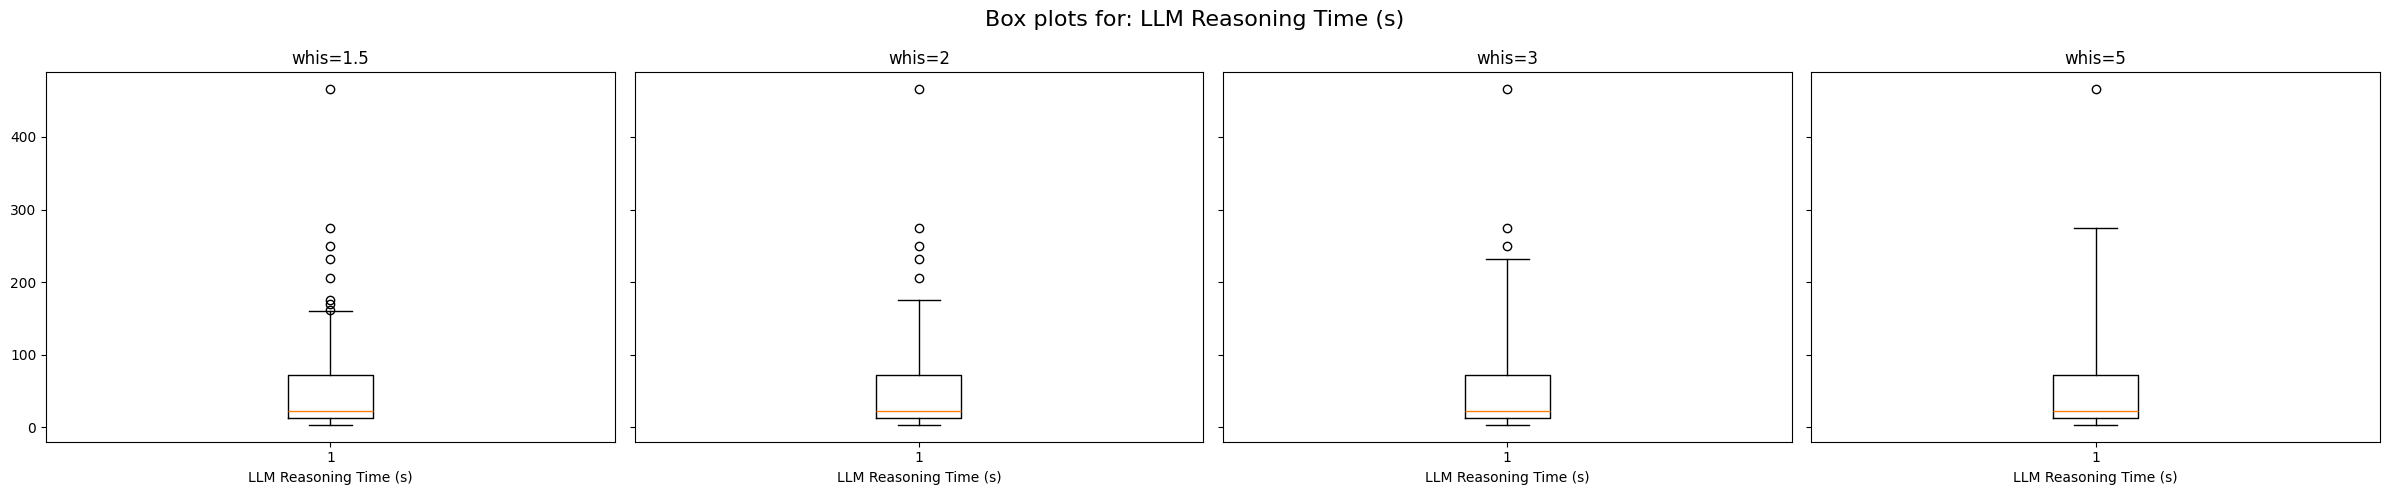

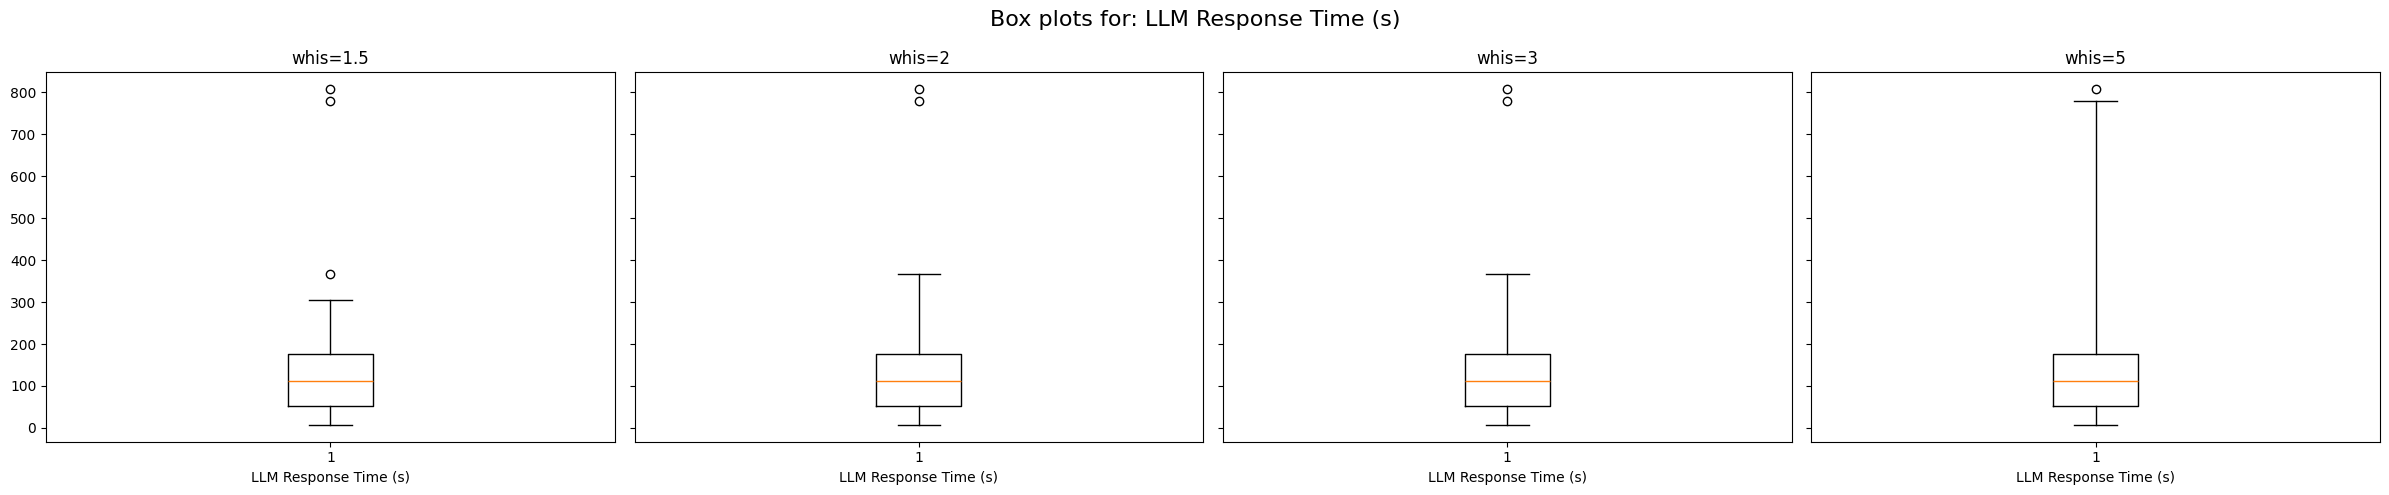

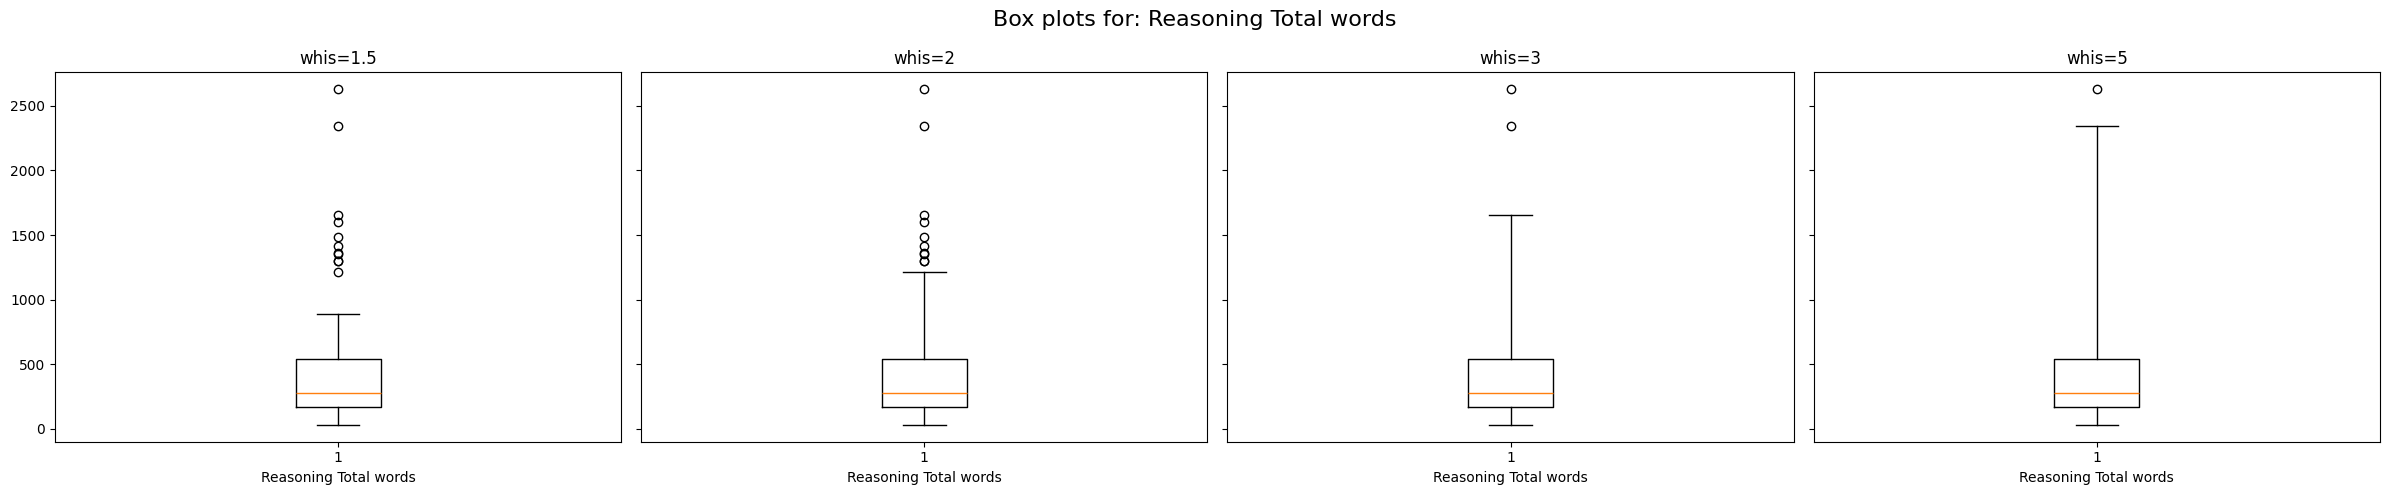

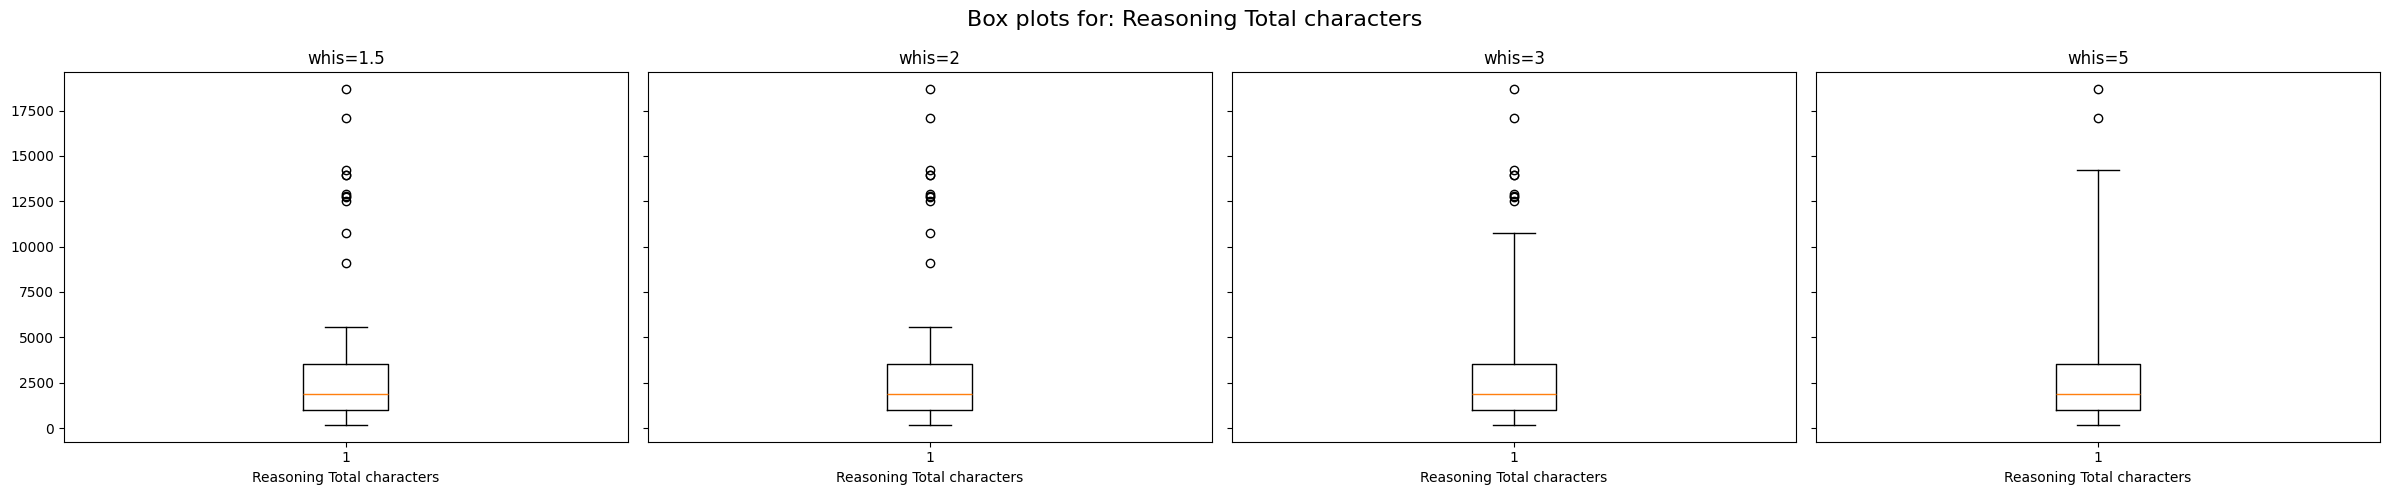

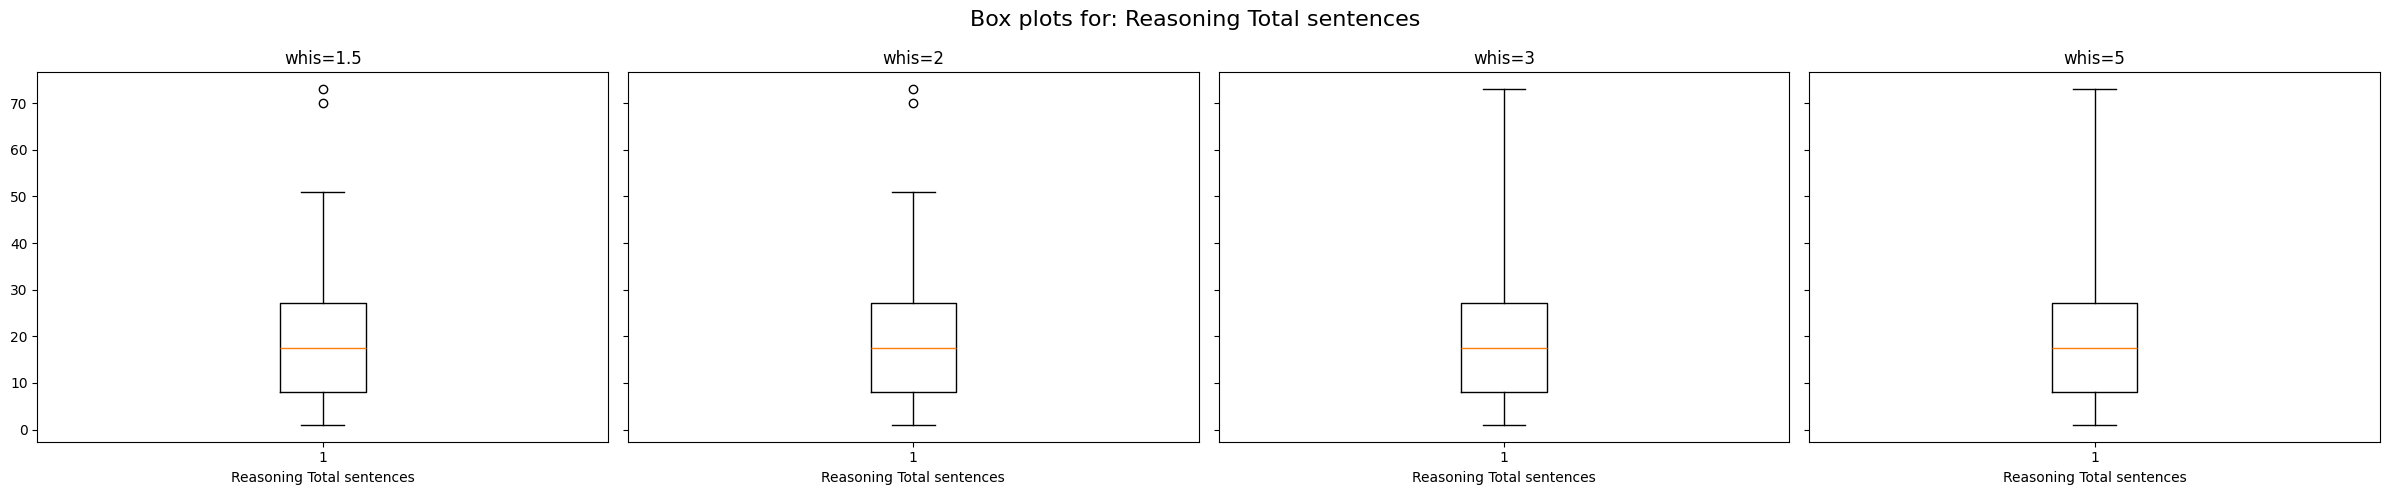

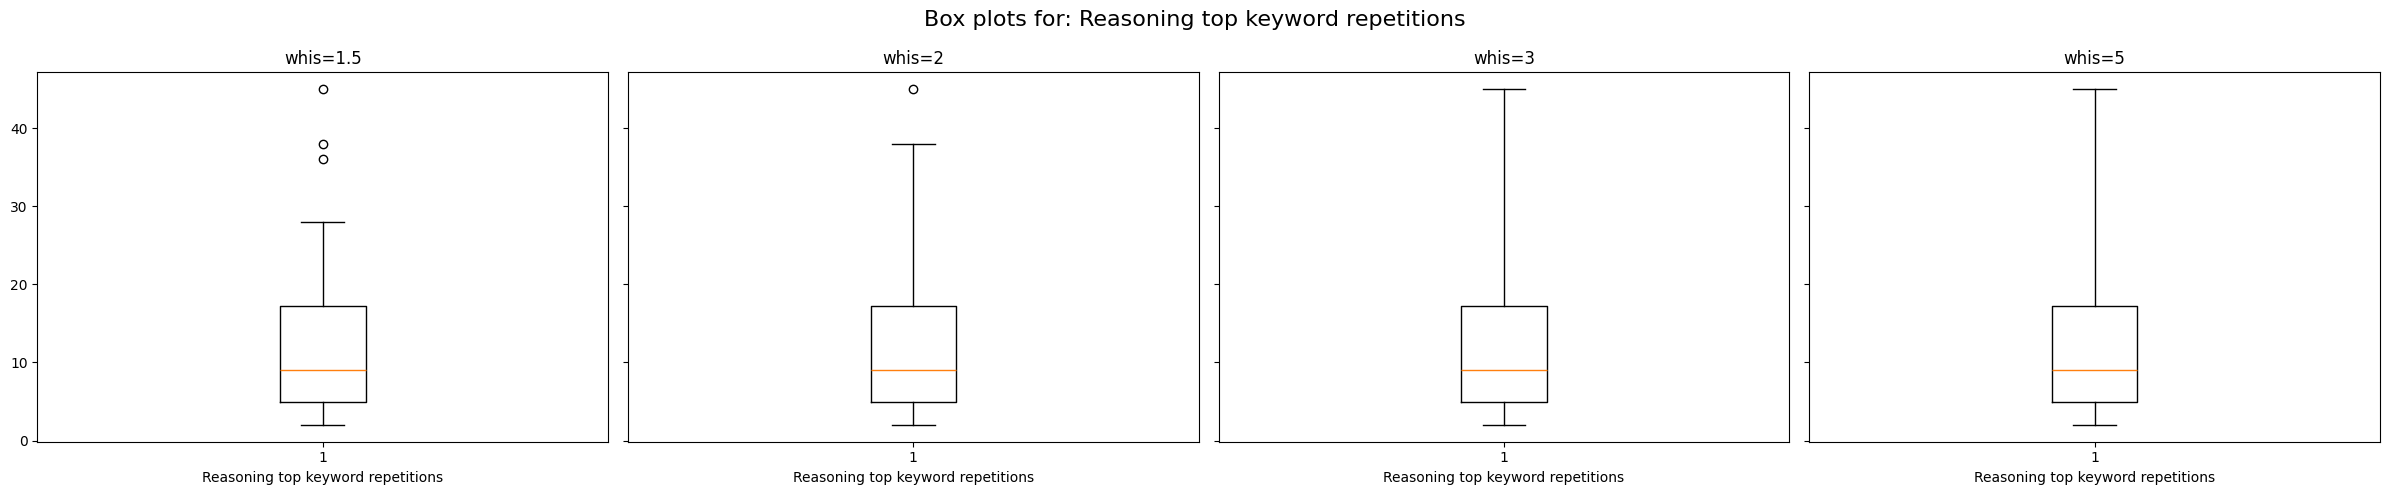

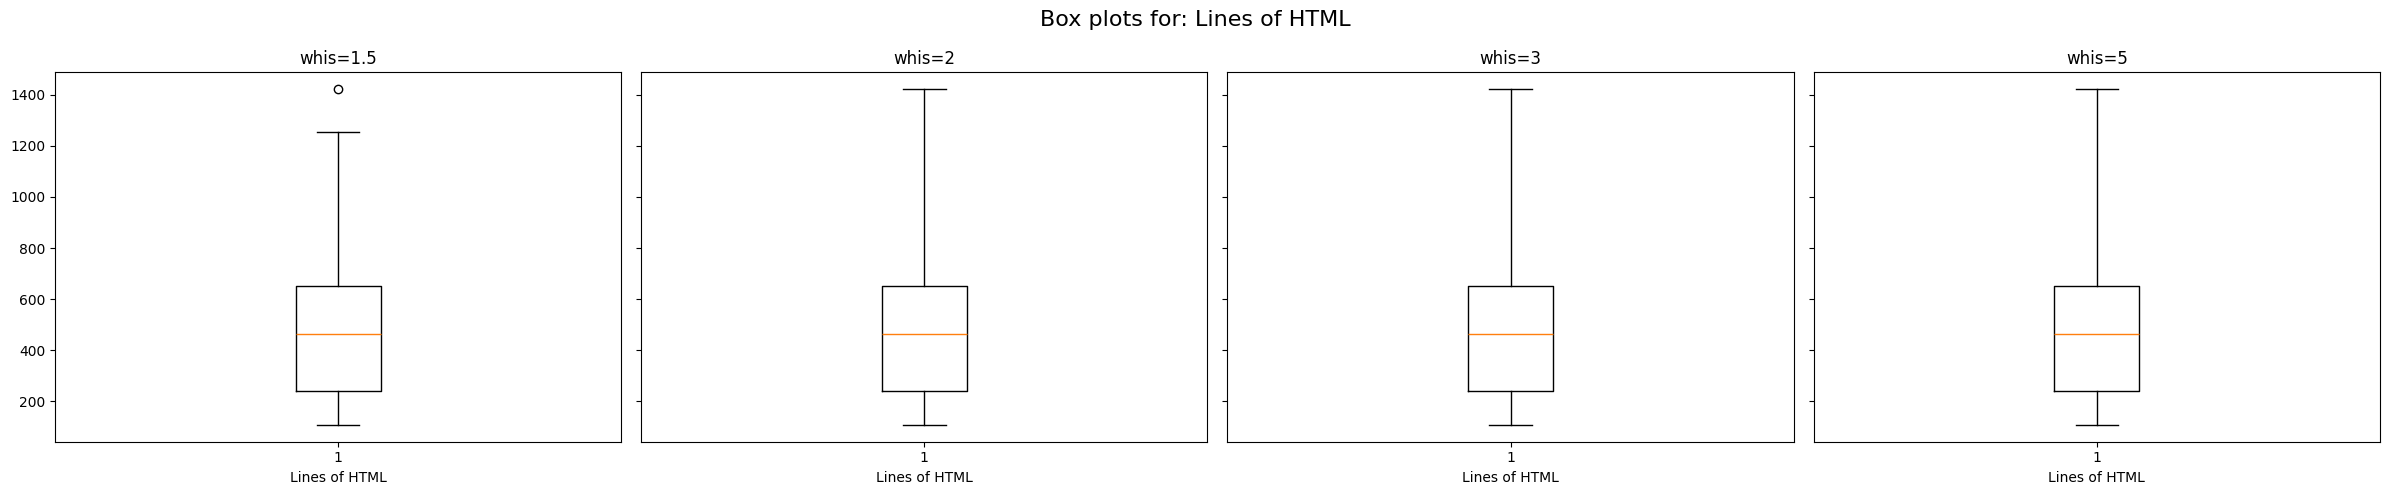

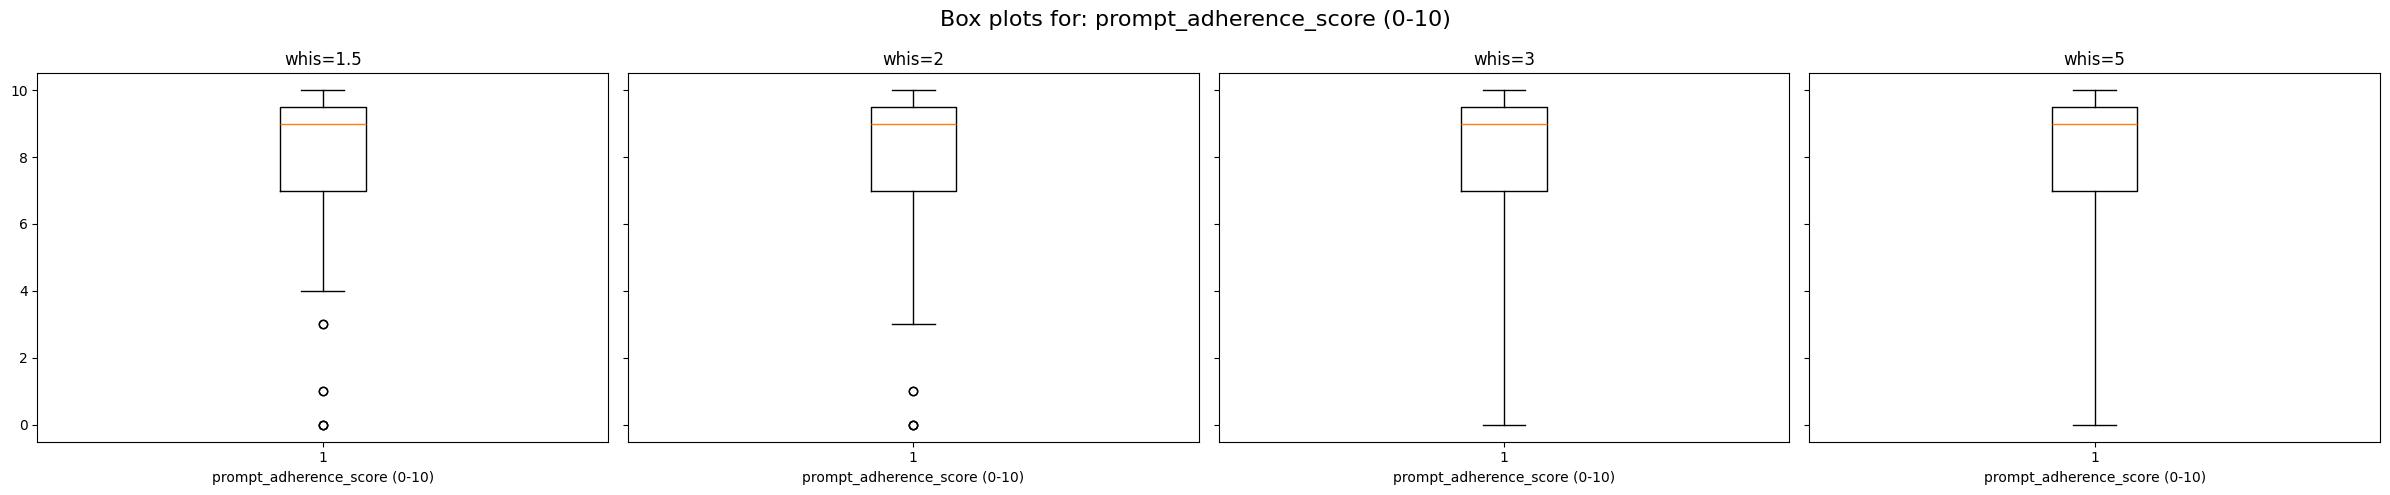

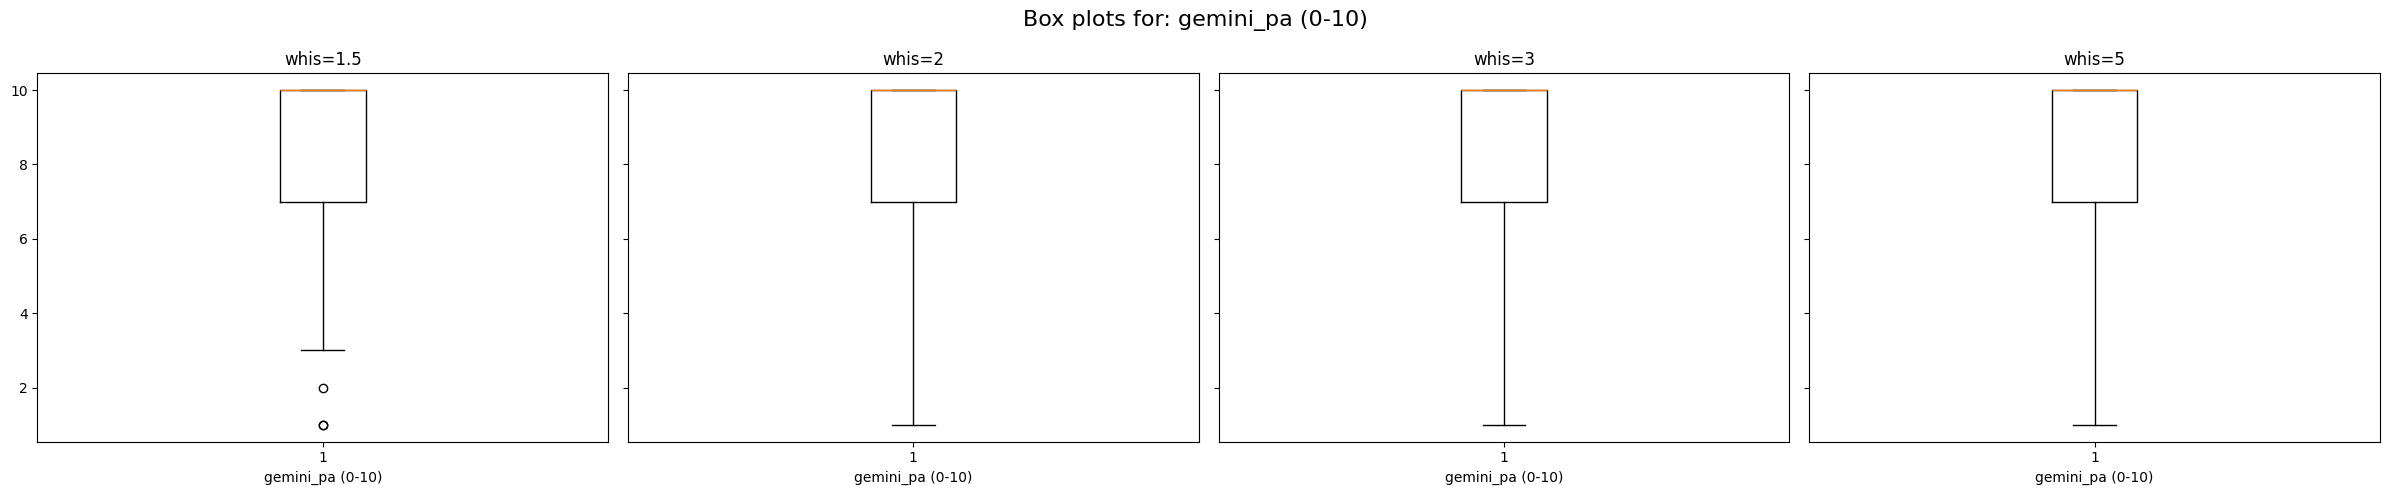

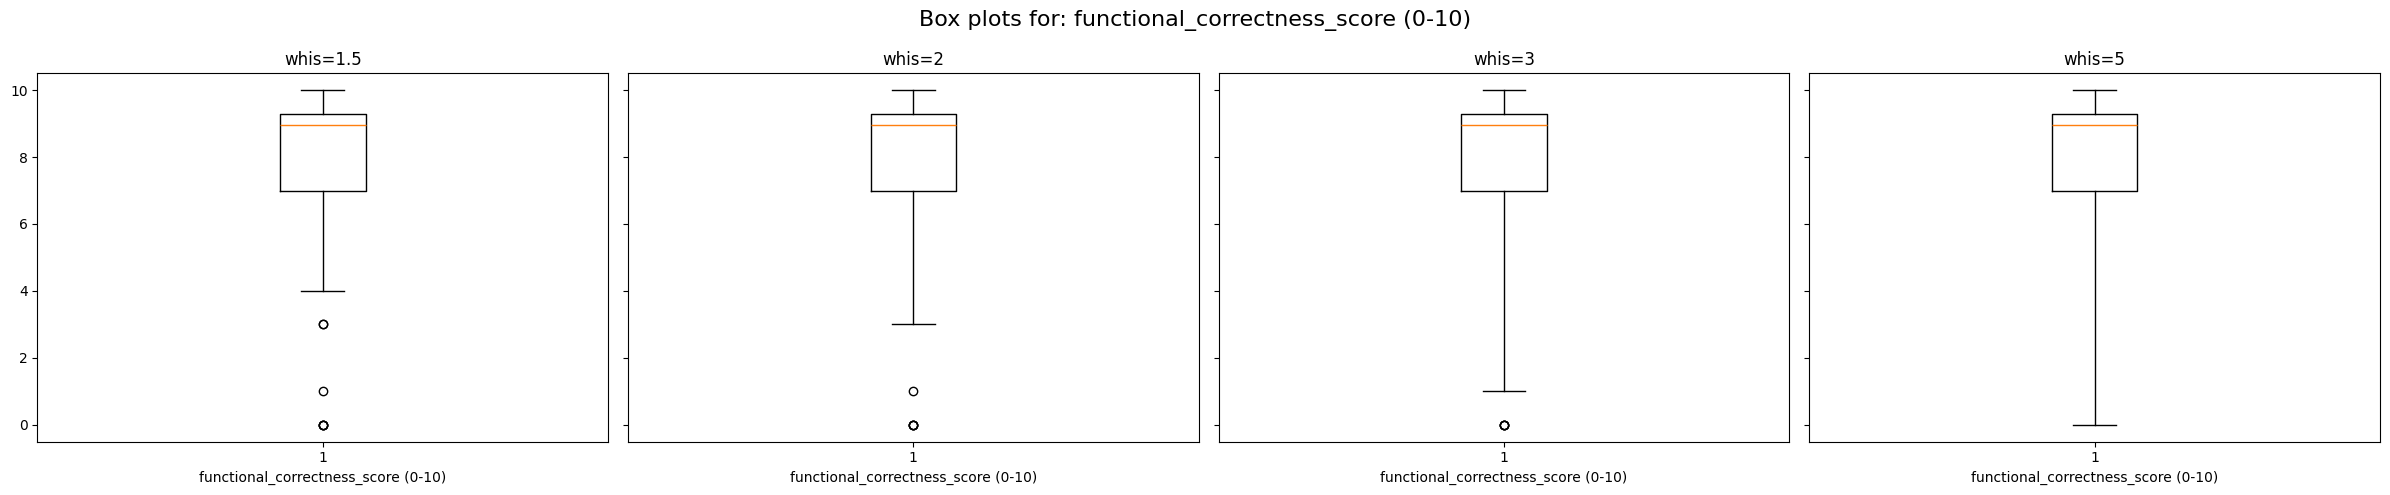

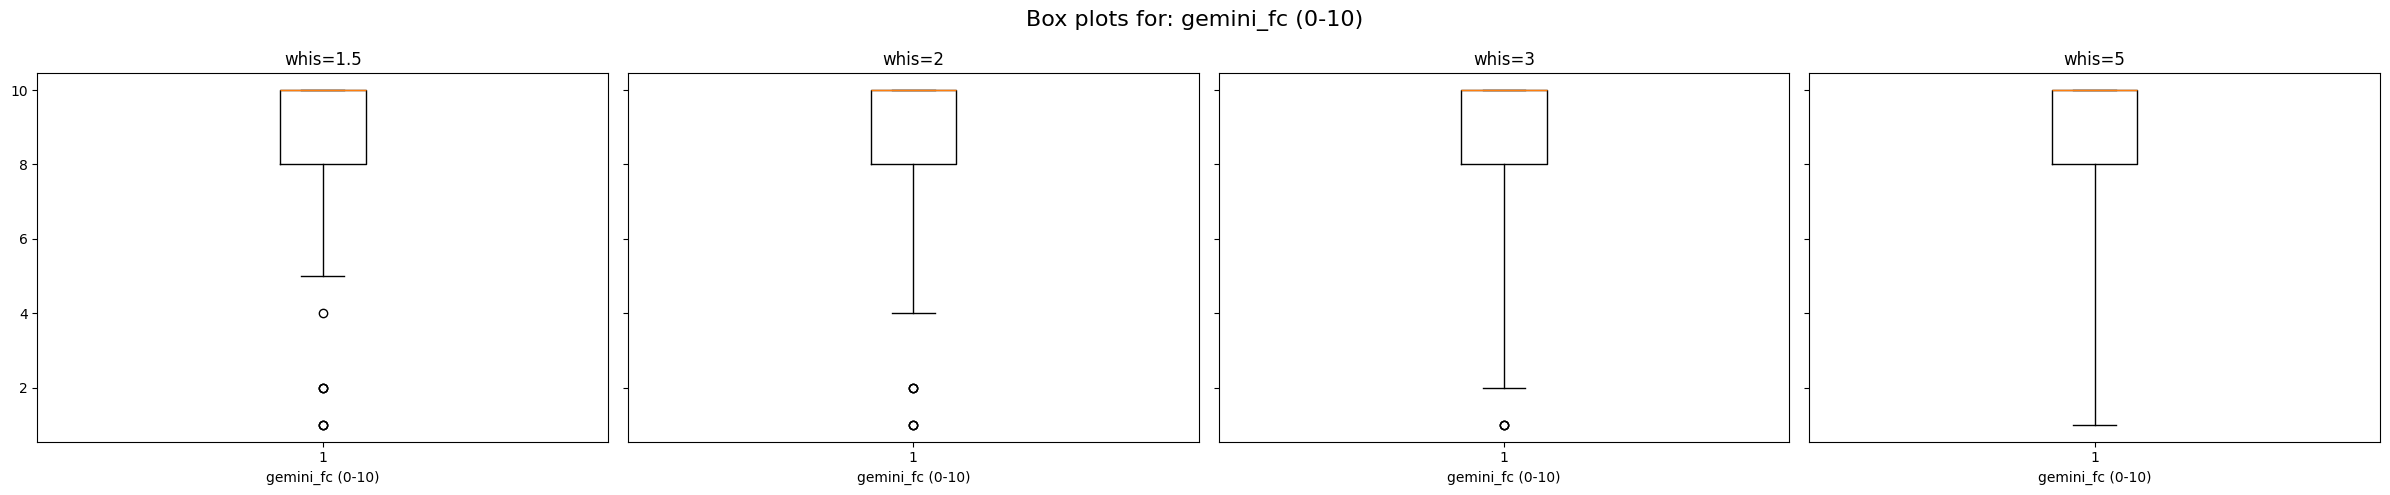

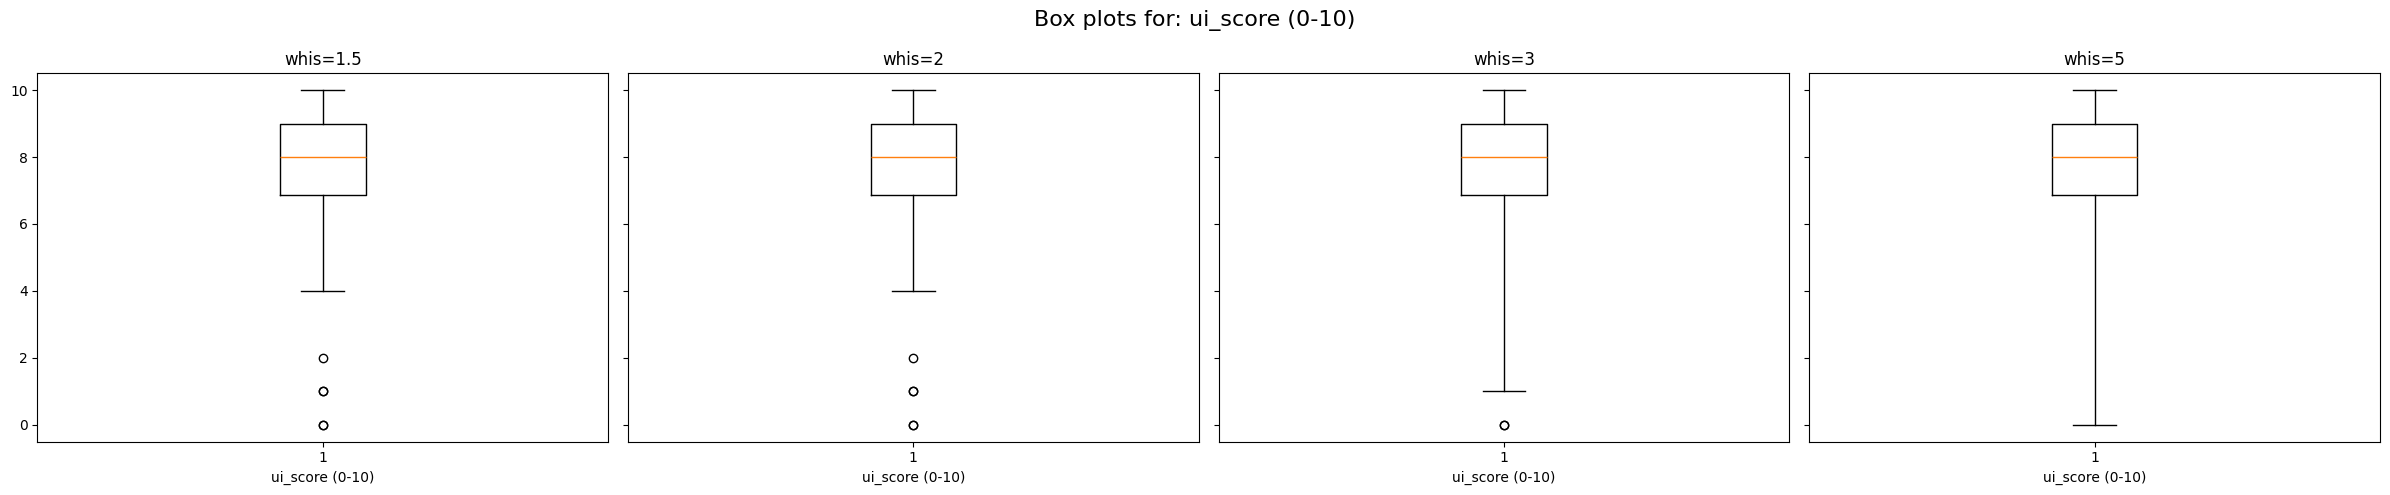

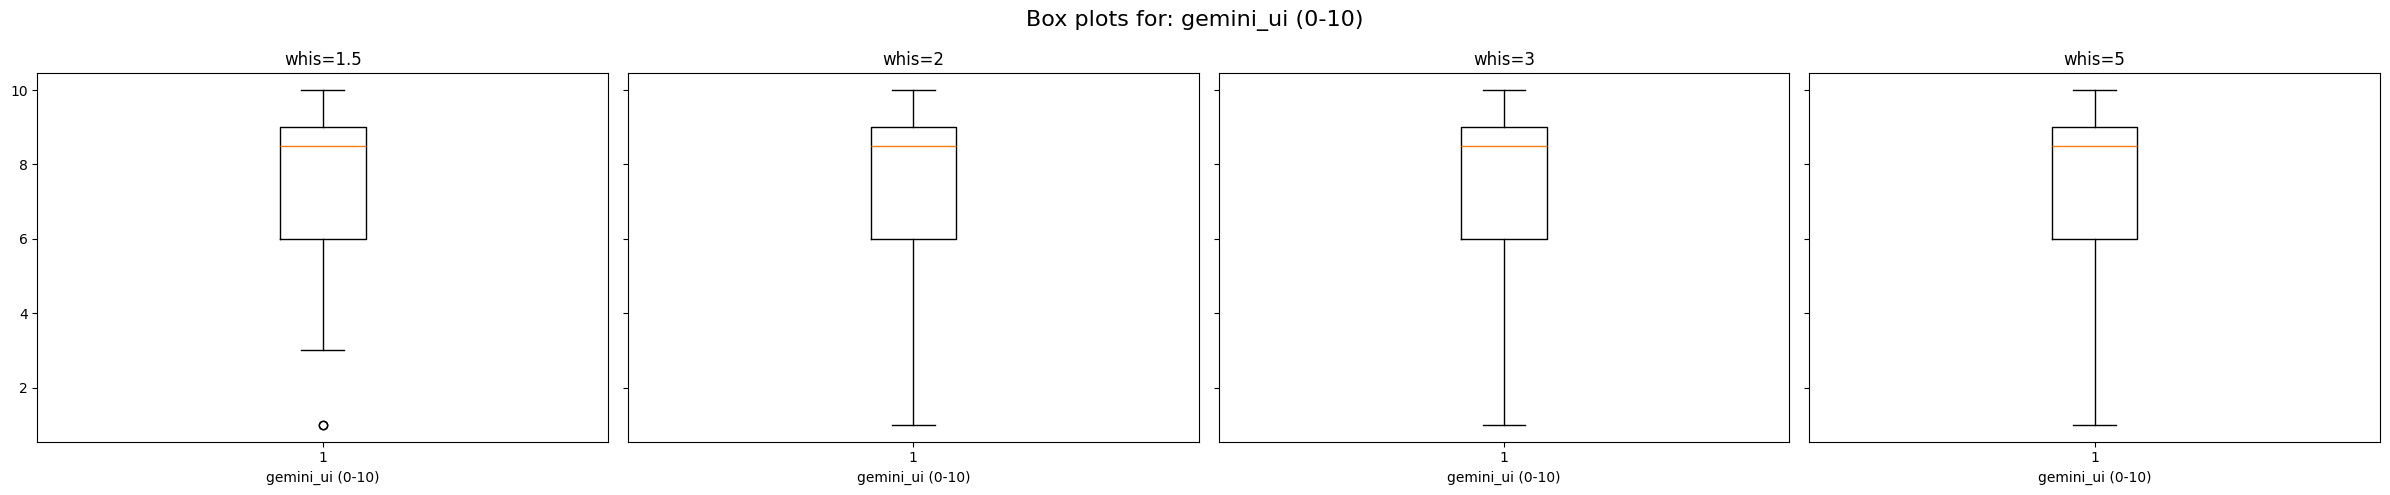

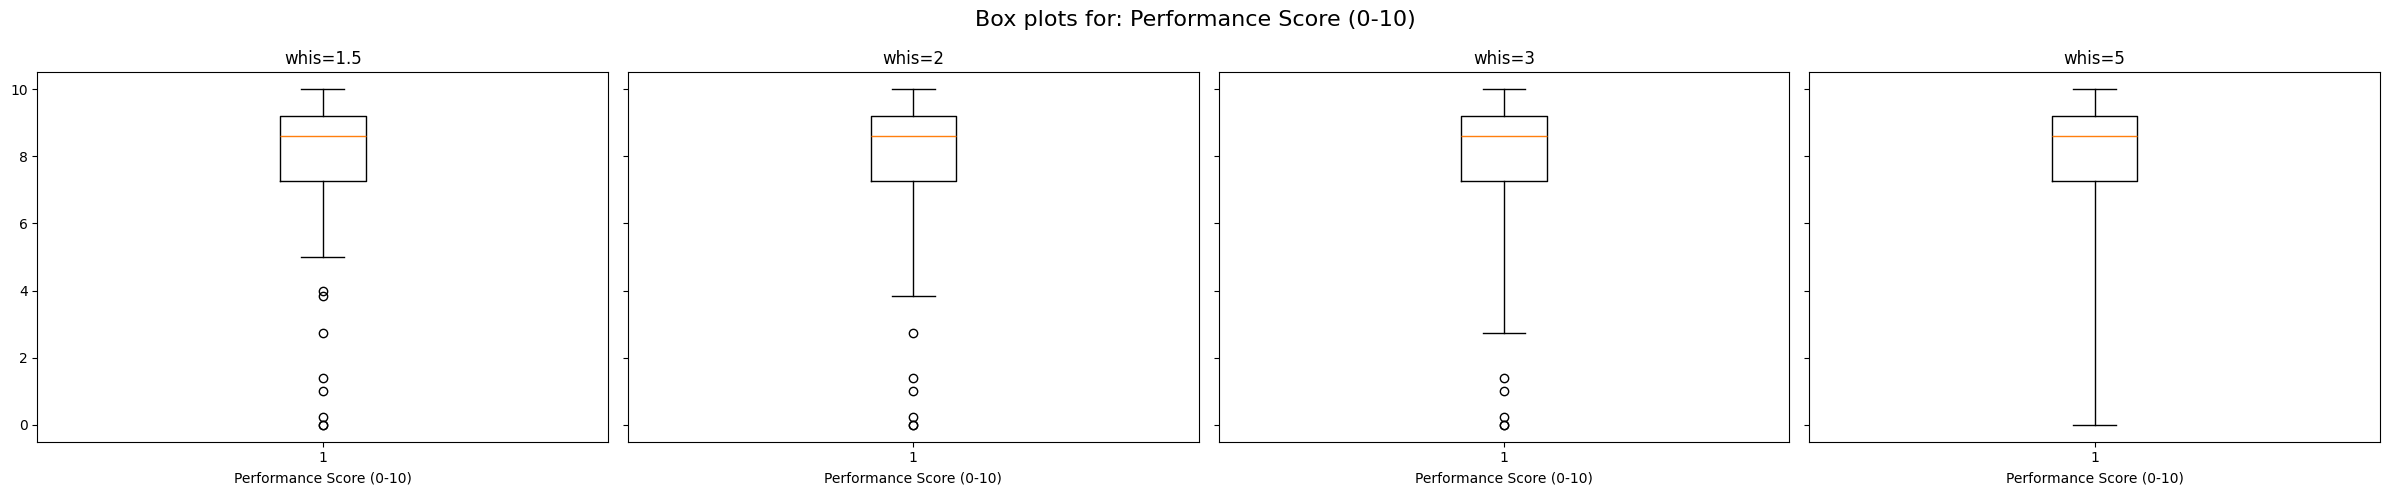

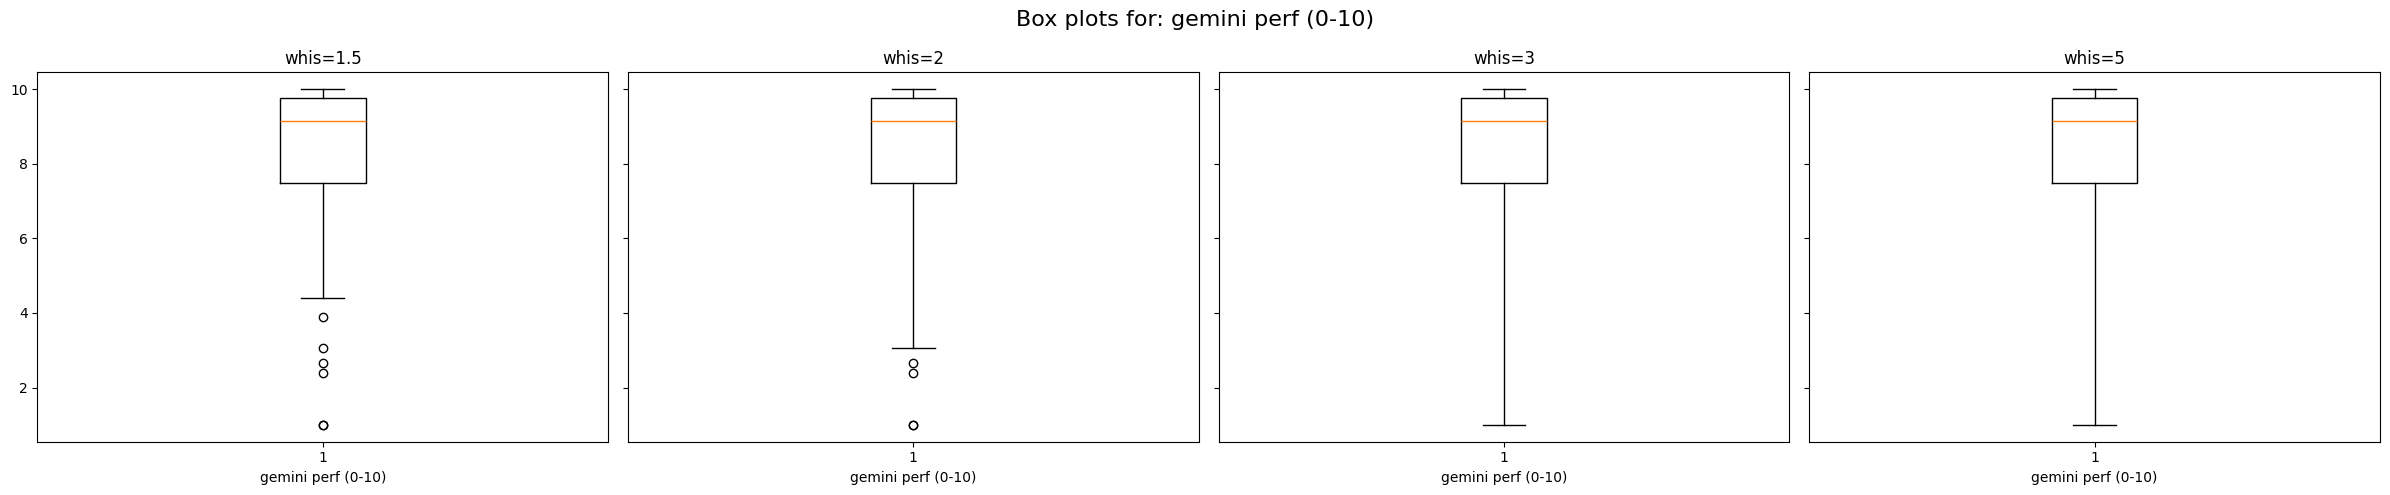

In [84]:
import matplotlib.pyplot as plt

# Only model-level numeric cols (exclude experiment-level metrics)
numeric_cols_model = [
    'LLM Reasoning Time (s)', 'LLM Response Time (s)', 'Reasoning Total words',
    'Reasoning Total characters', 'Reasoning Total sentences',
    'Reasoning top keyword repetitions', 'Lines of HTML',
    'prompt_adherence_score (0-10)', 'gemini_pa (0-10)',
    'functional_correctness_score (0-10)', 'gemini_fc (0-10)',
    'ui_score (0-10)', 'gemini_ui (0-10)',
    'Performance Score (0-10)', 'gemini perf (0-10)'
]

# Keep only columns that actually exist in df
numerical_cols = [c for c in numeric_cols_model if c in df.columns]
missing = [c for c in numeric_cols_model if c not in df.columns]
if missing:
    print("Missing columns in df (skipped):")
    for c in missing:
        print(" -", c)

# Whisker values to test
whis_values = [1.5, 2, 3, 5]

for col in numerical_cols:
    fig, axes = plt.subplots(1, len(whis_values), figsize=(24, 5), sharey=True)

    for ax, whis in zip(axes, whis_values):
        ax.boxplot(df[col].dropna(), whis=whis)
        ax.set_title(f"whis={whis}", fontsize=12)
        ax.set_xlabel(col, fontsize=10)
        ax.tick_params(labelsize=10)

    fig.suptitle(f"Box plots for: {col}", fontsize=16)
    plt.tight_layout()
    plt.show()

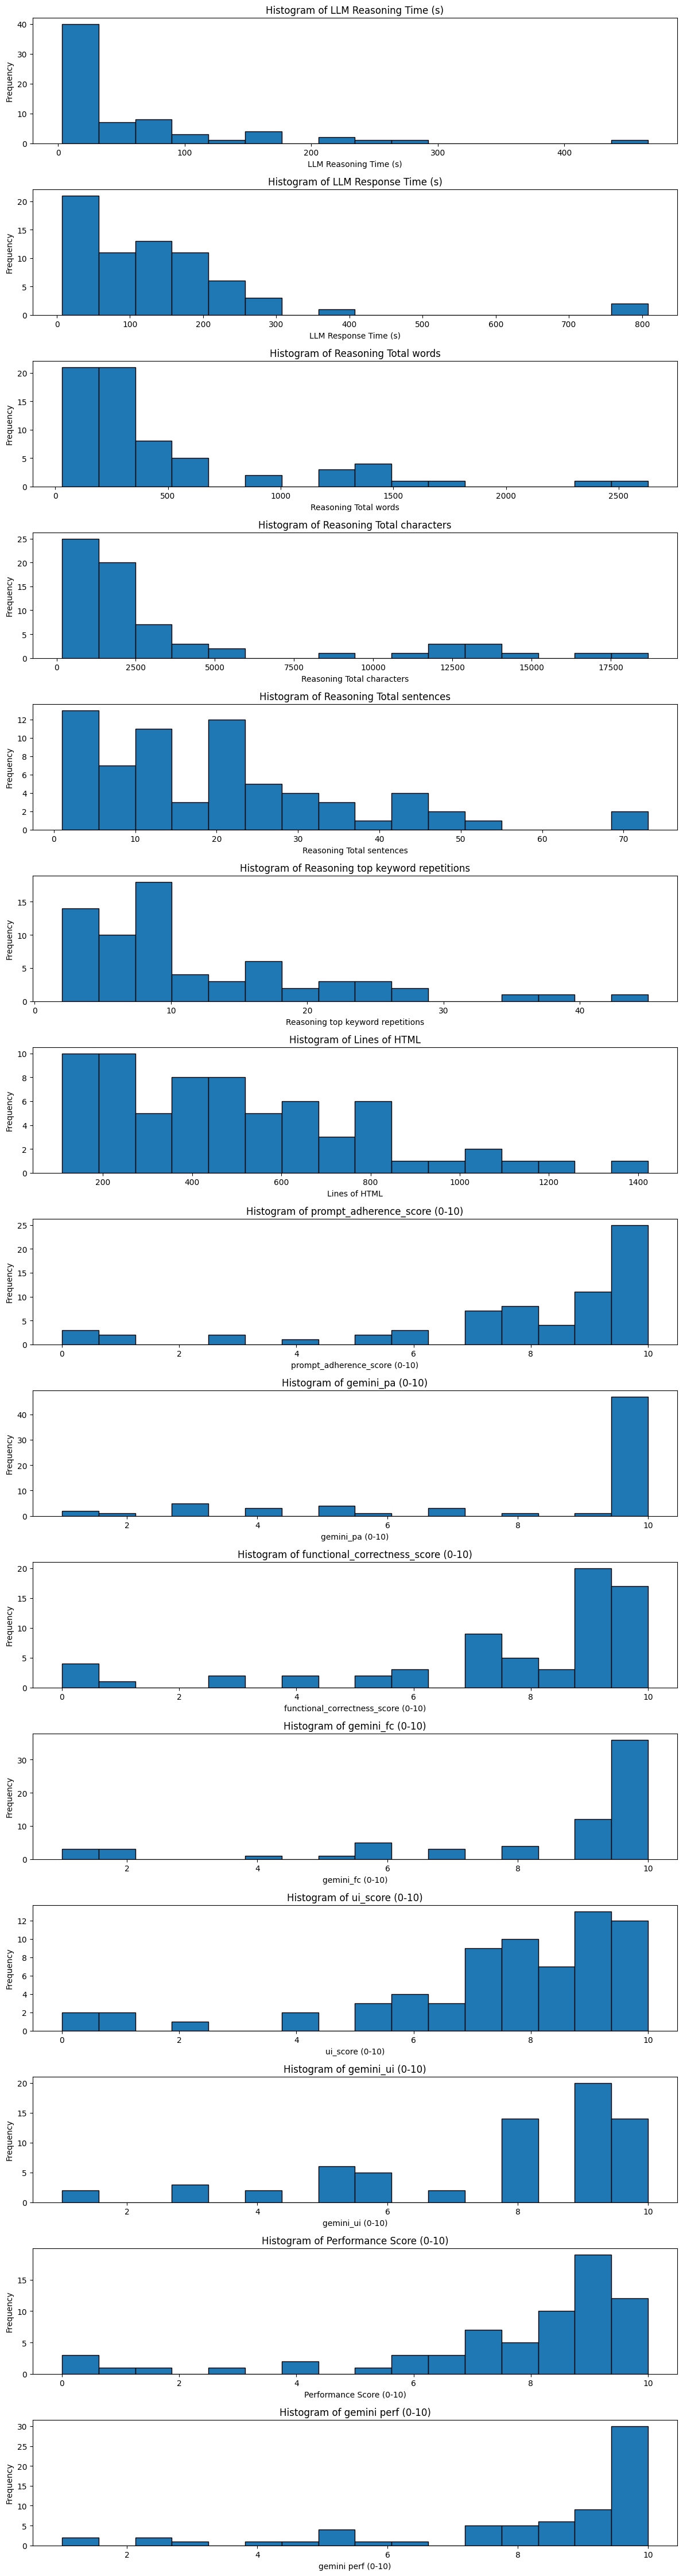

In [85]:
import numpy as np

n = len(numerical_cols)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3 * n))

# If there's only 1 column, axes is not a list, normalize it
if n == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols):
    s = df[col].dropna()

    # With only ~20 rows, 30 bins can be too many, so use a safe bin count
    bins = min(30, max(5, int(np.sqrt(len(s)) * 2)))

    ax.hist(s, bins=bins, edgecolor='black')
    ax.set_title(f"Histogram of {col}")
    ax.set_ylabel("Frequency")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


exp_df

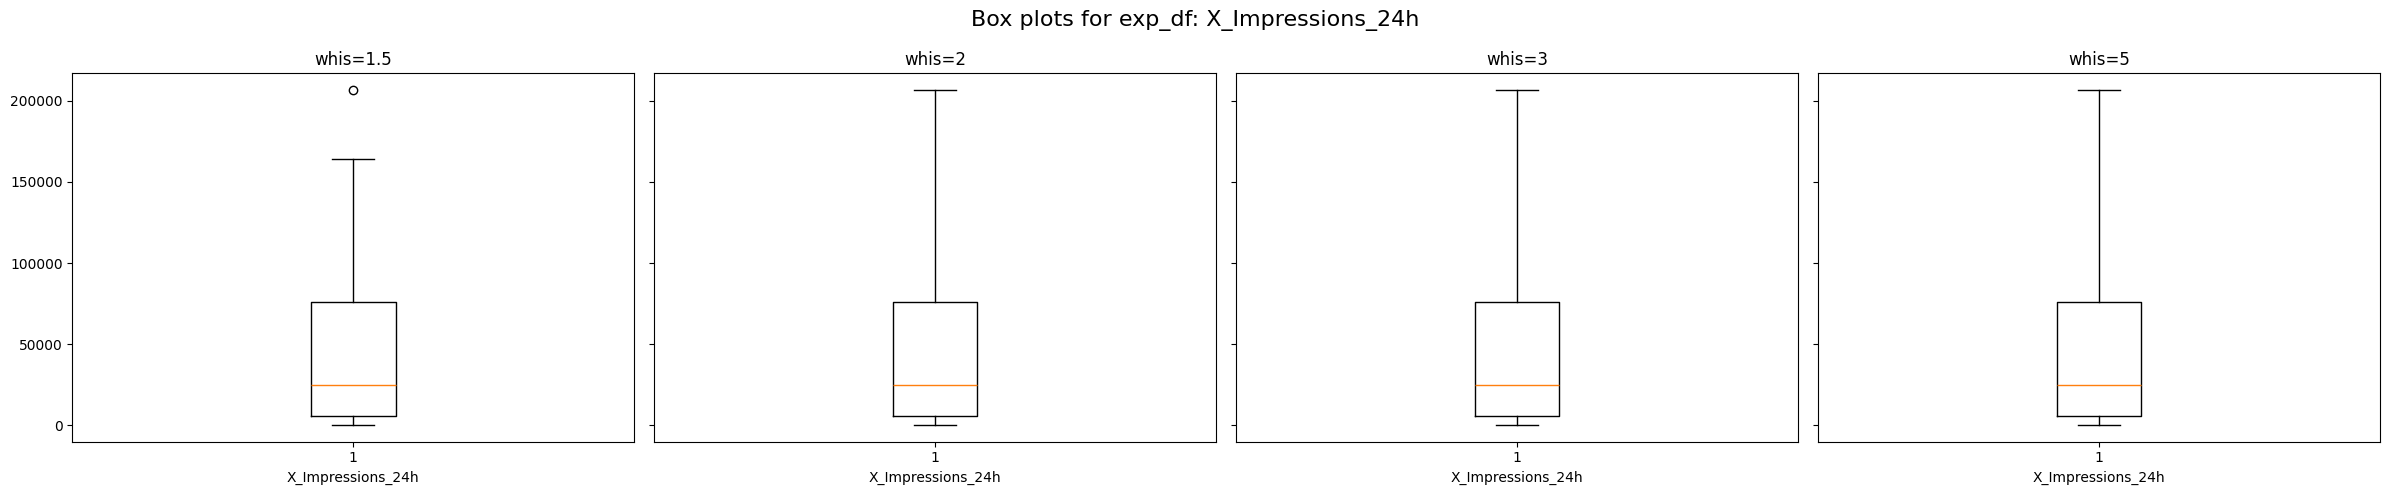

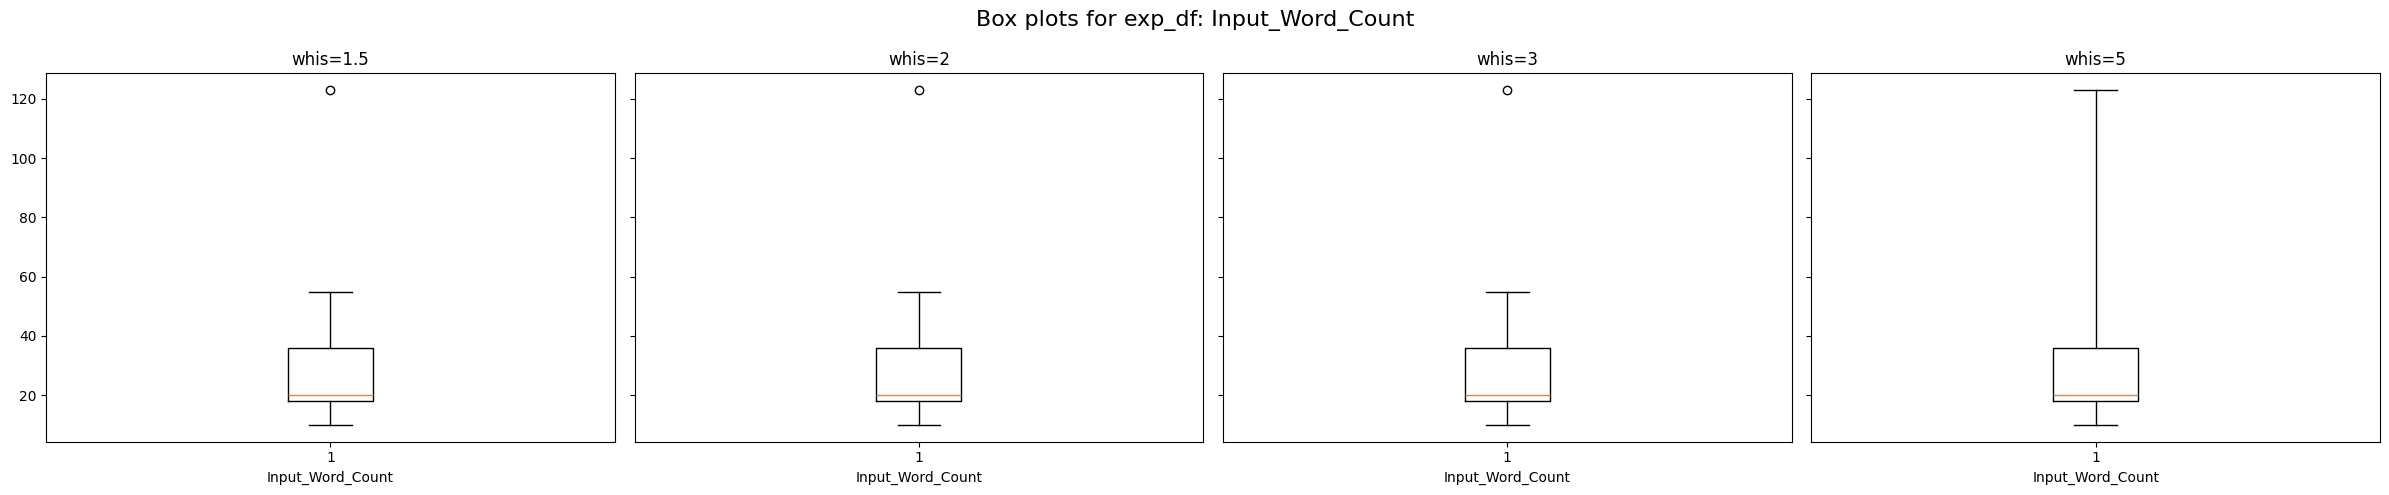

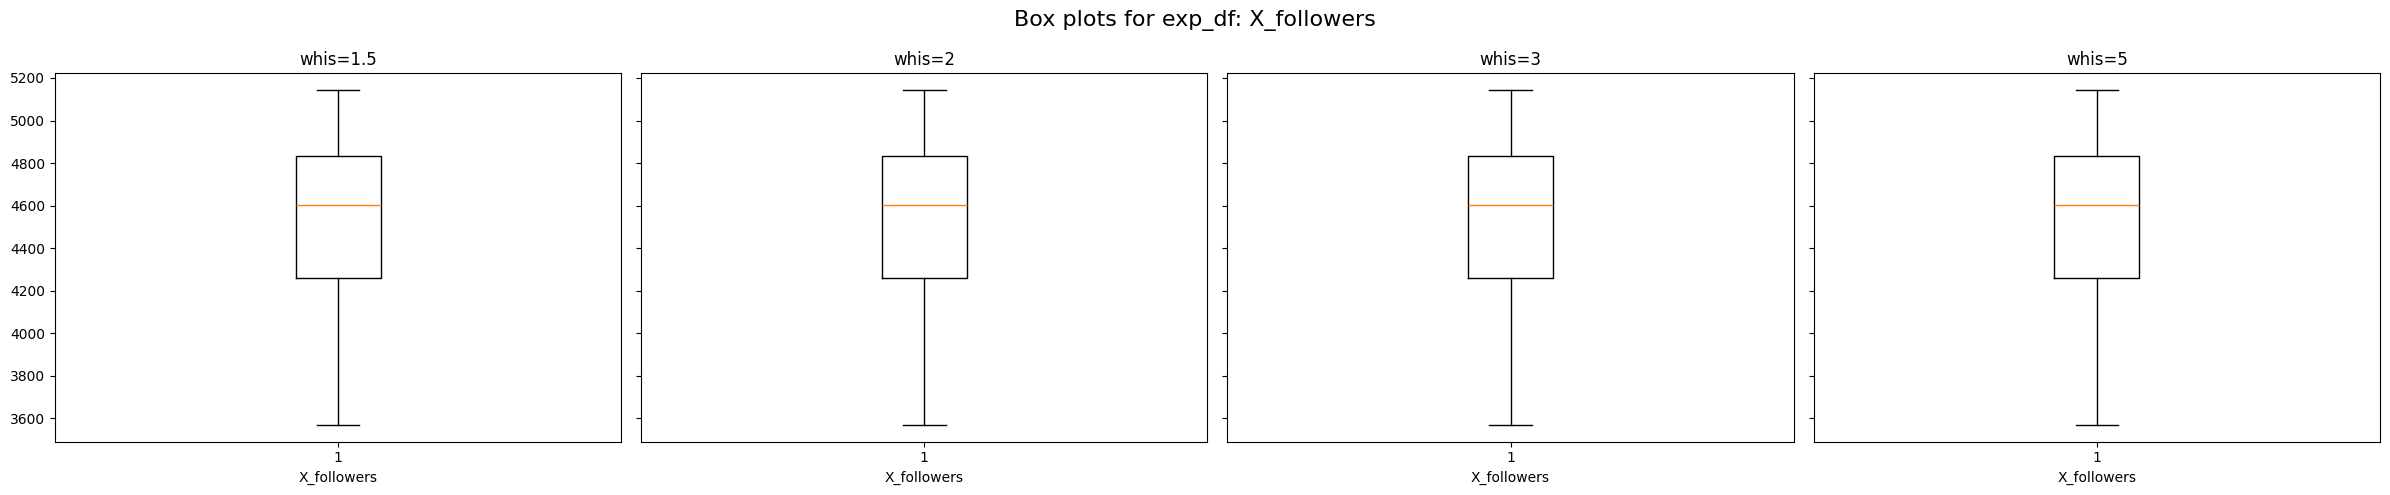

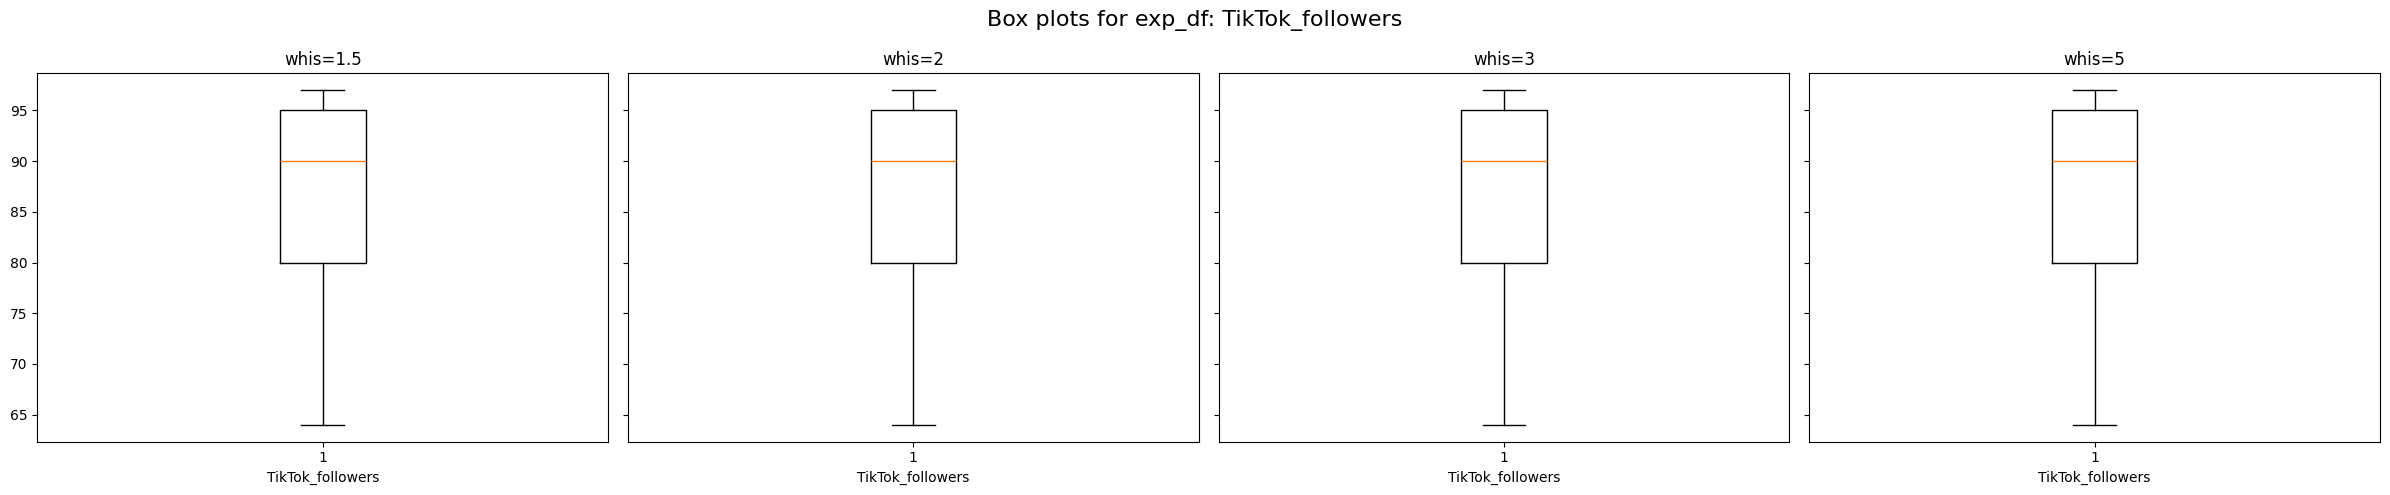

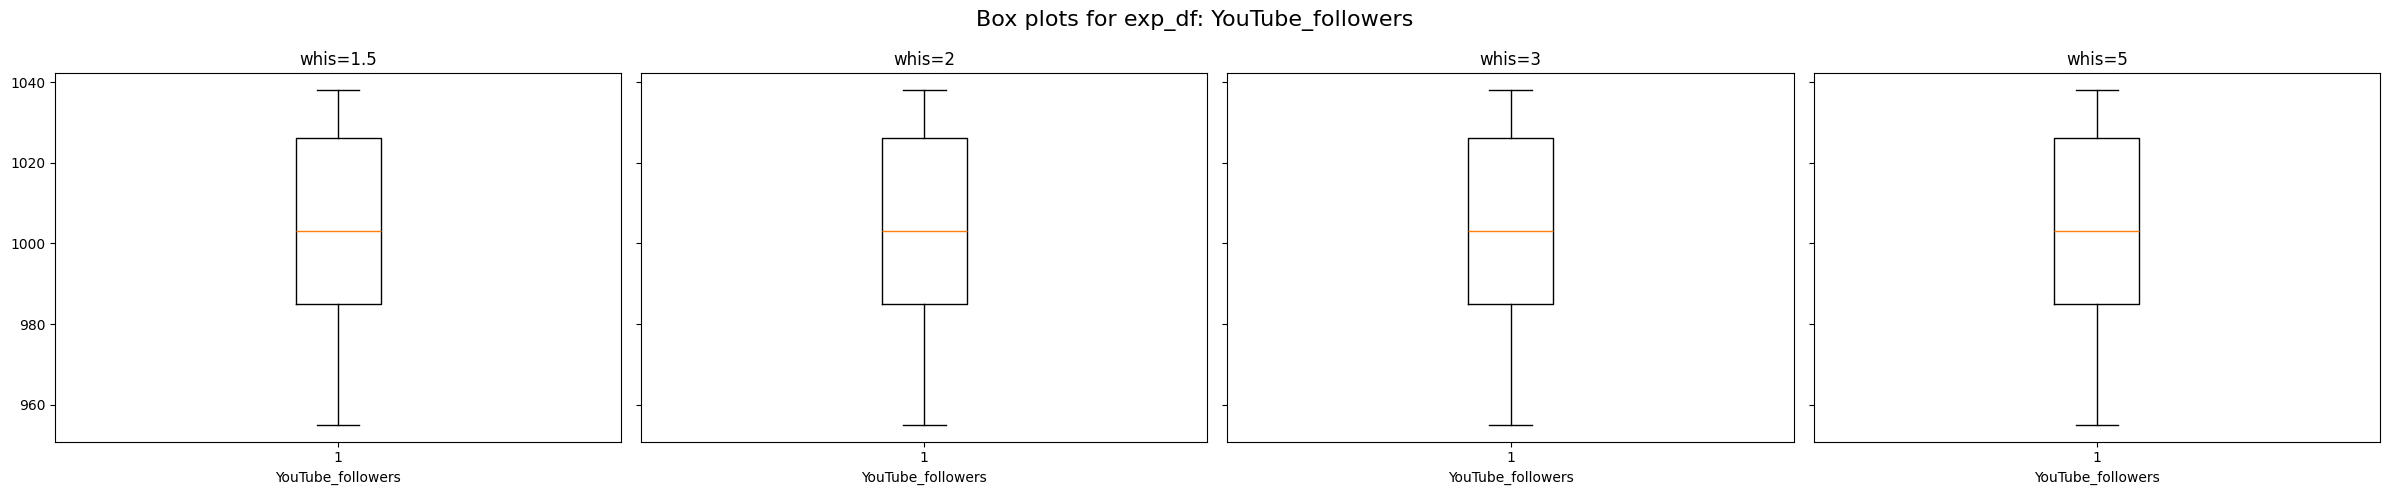

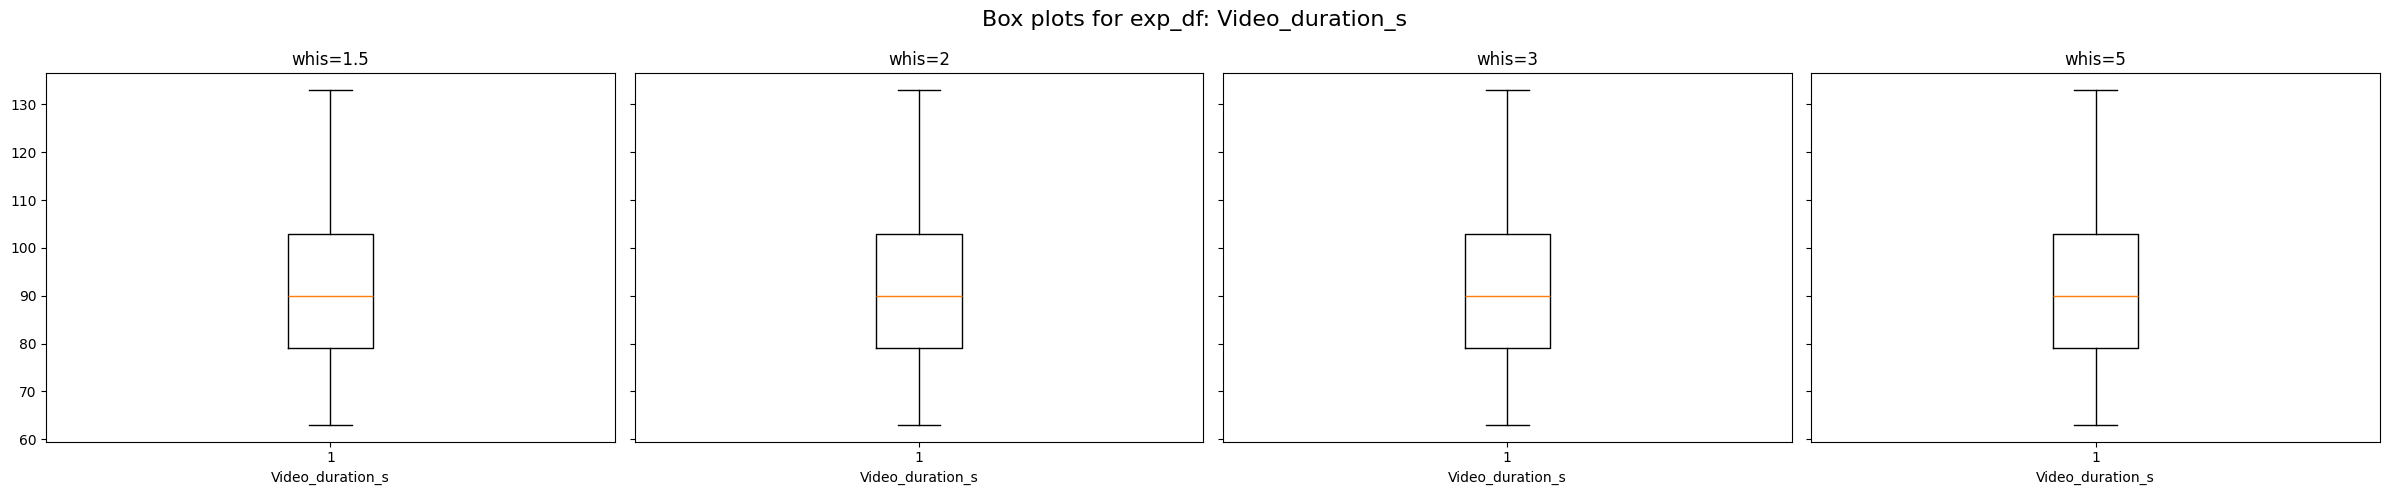

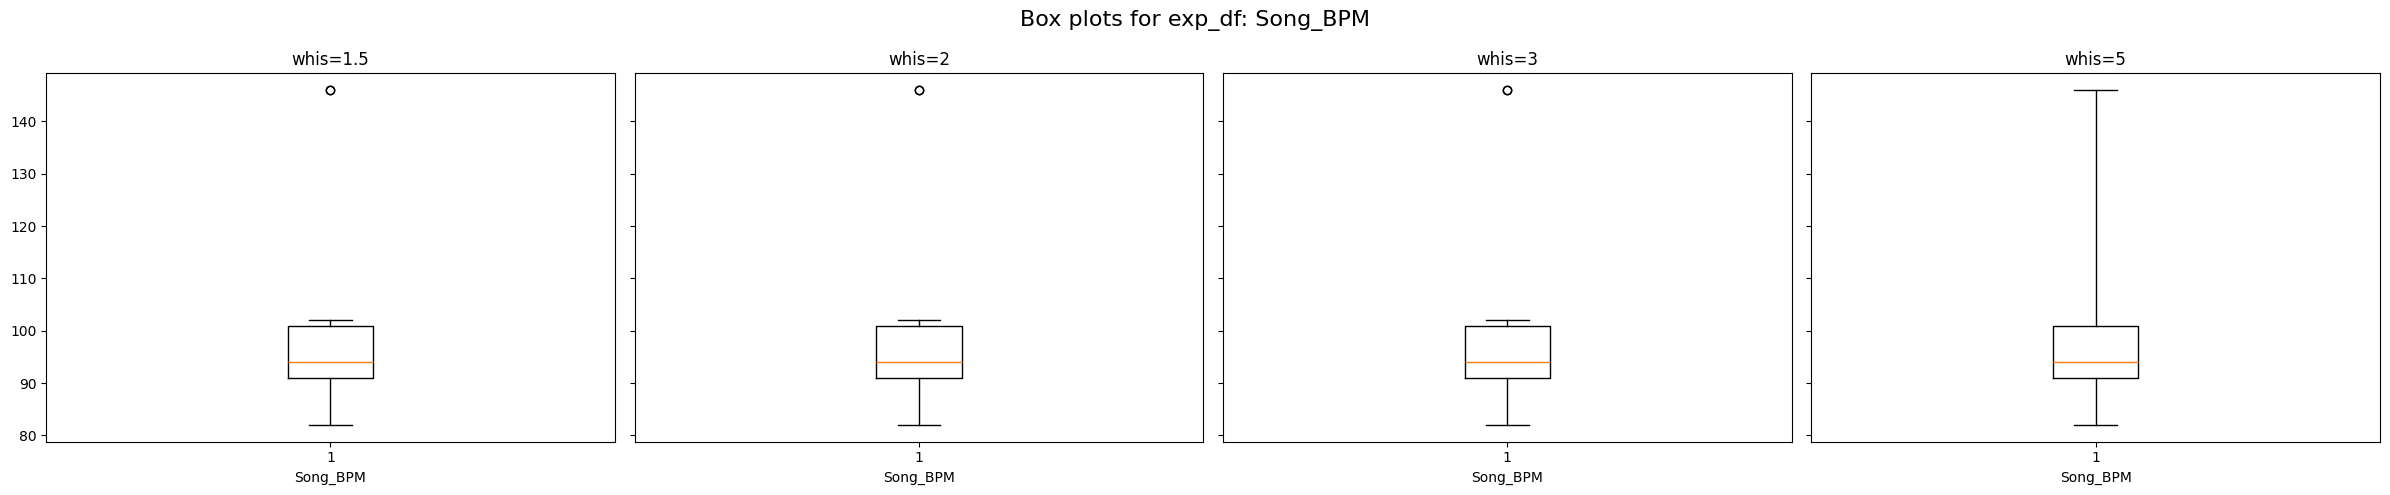

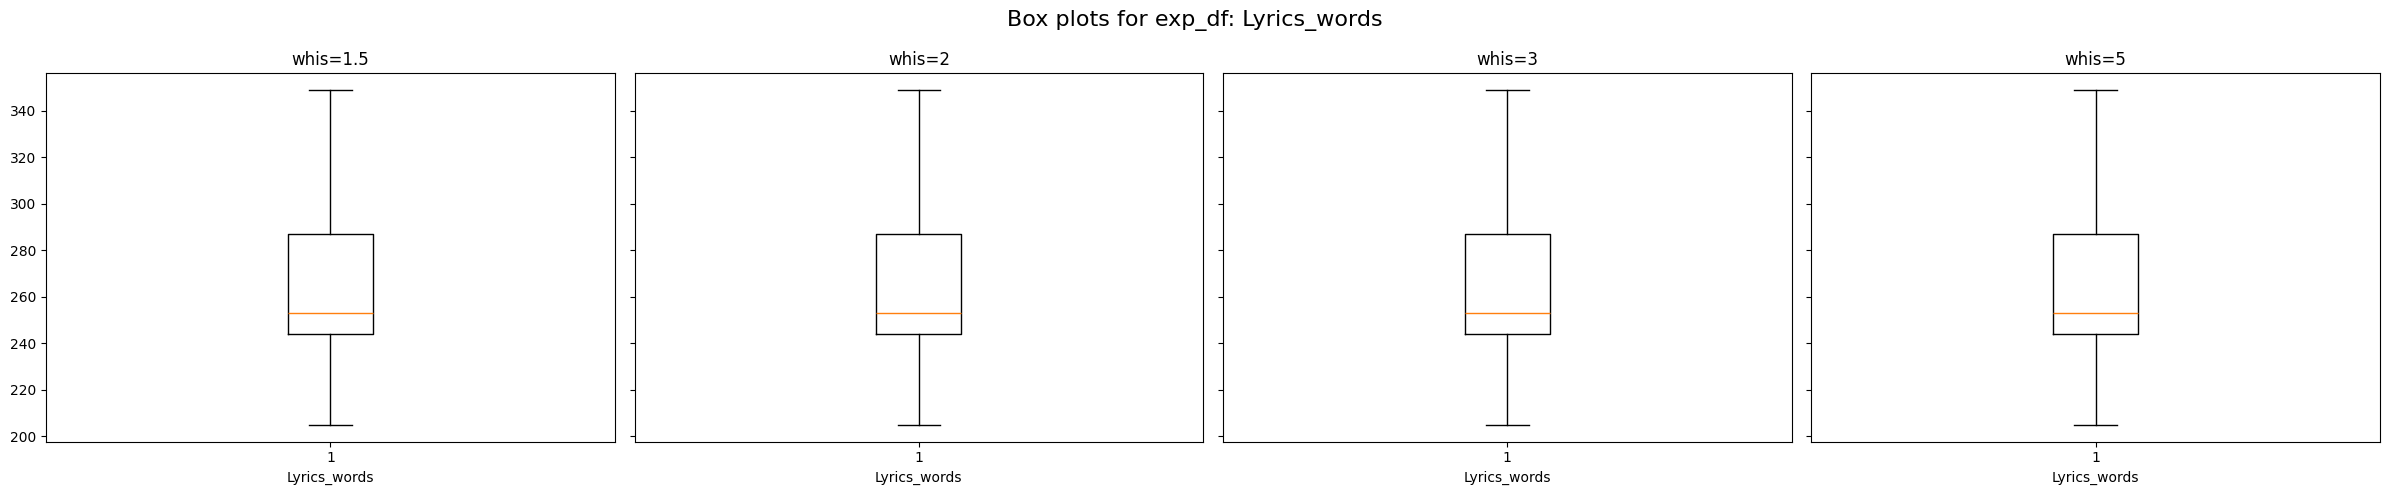

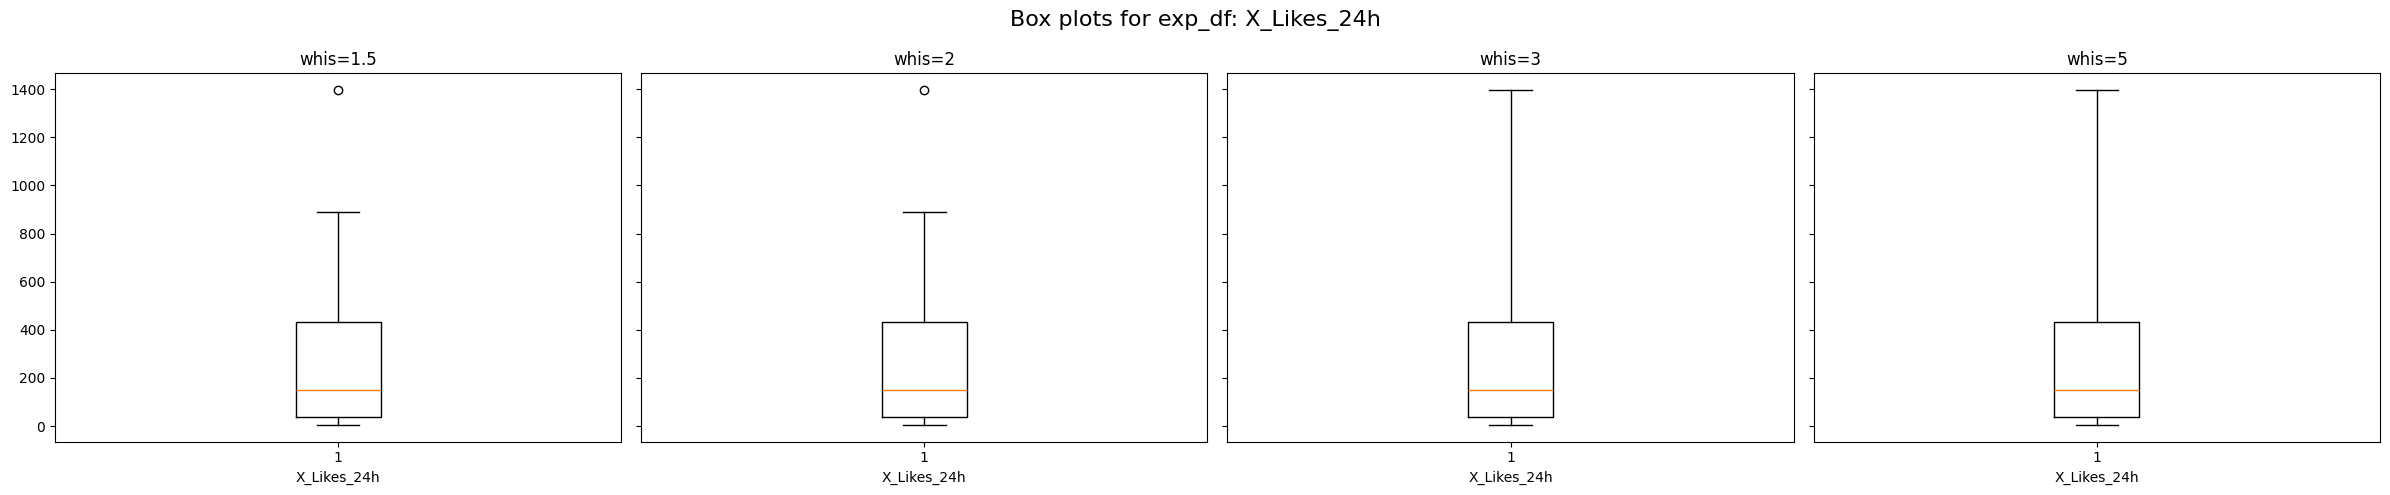

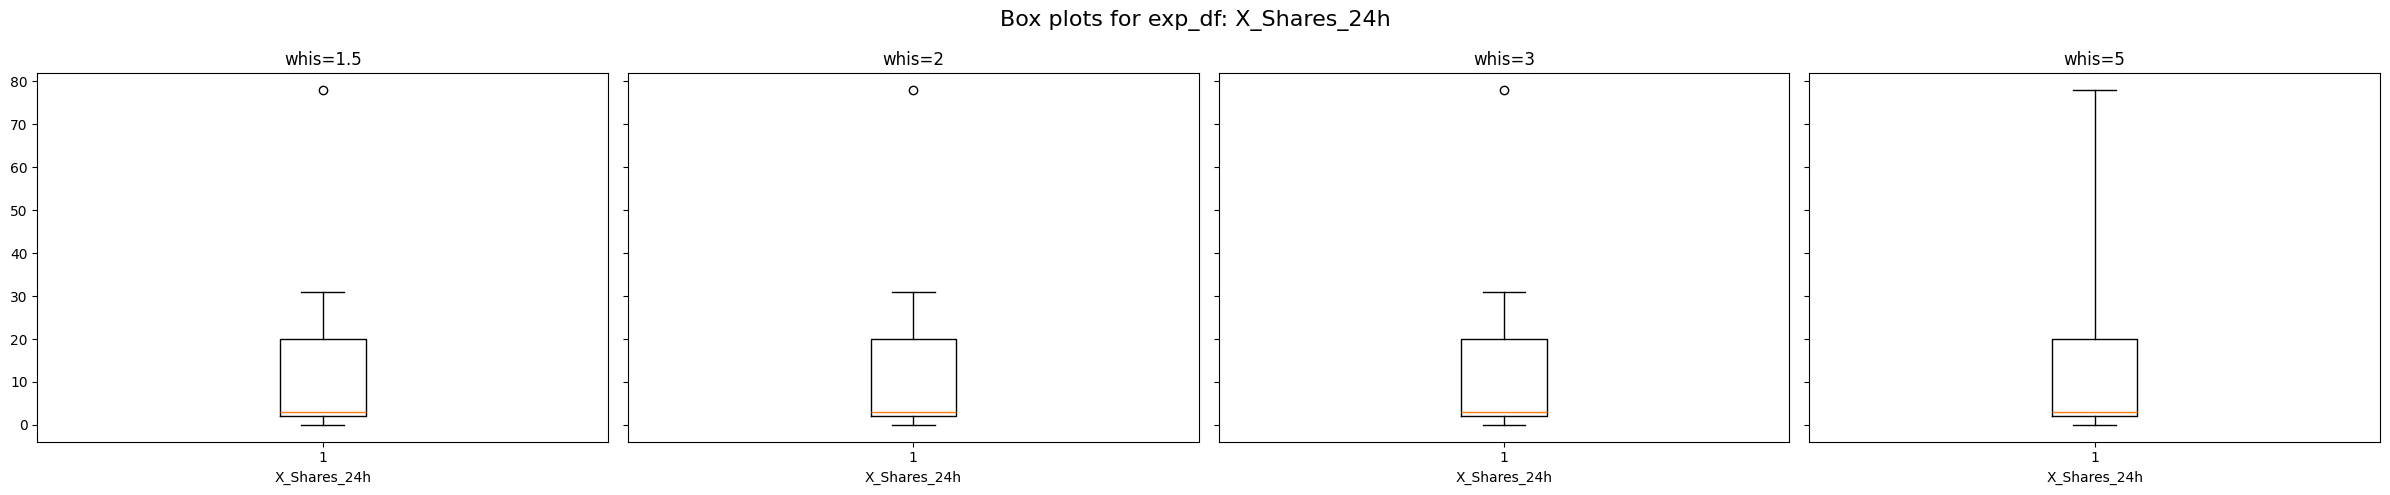

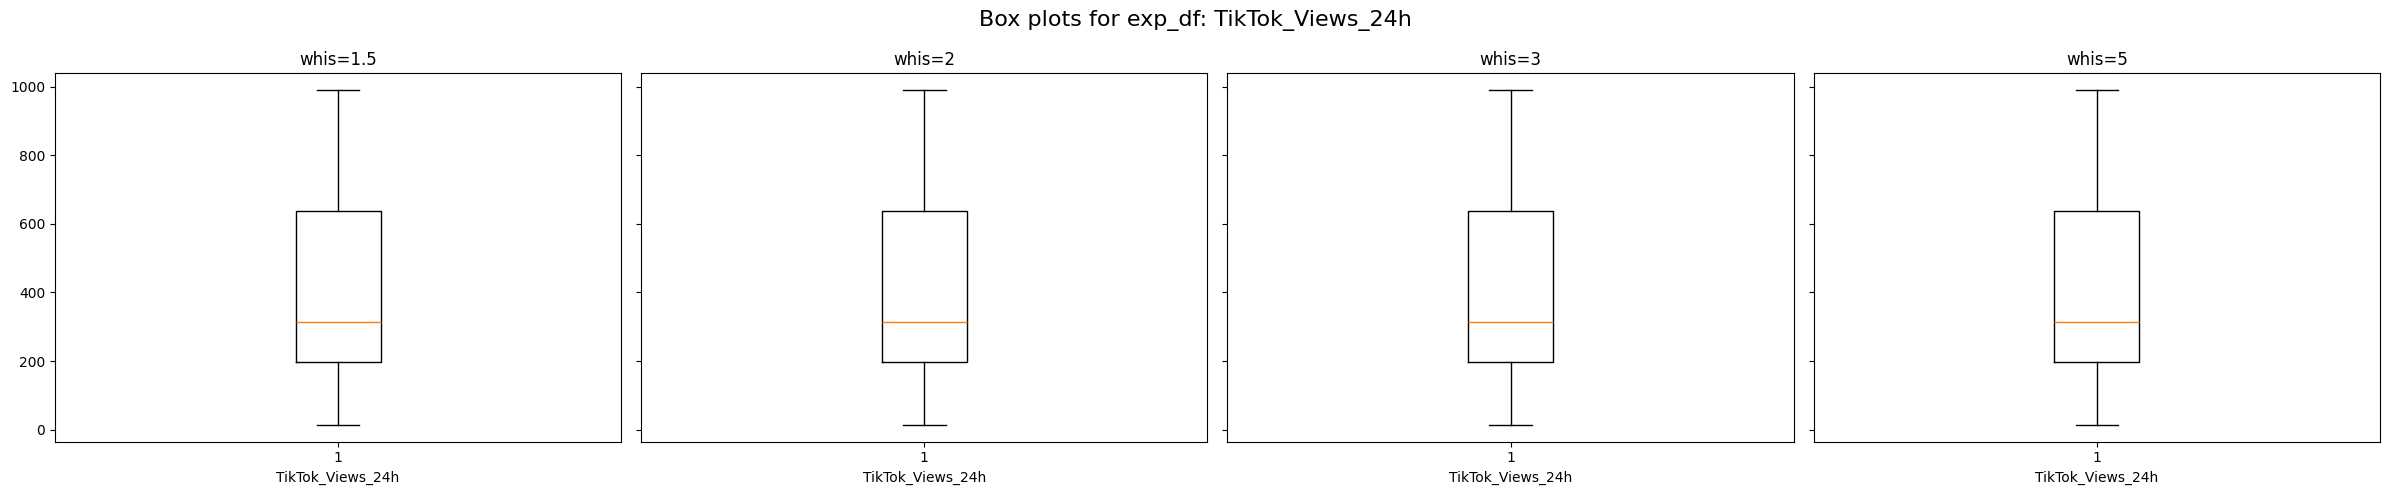

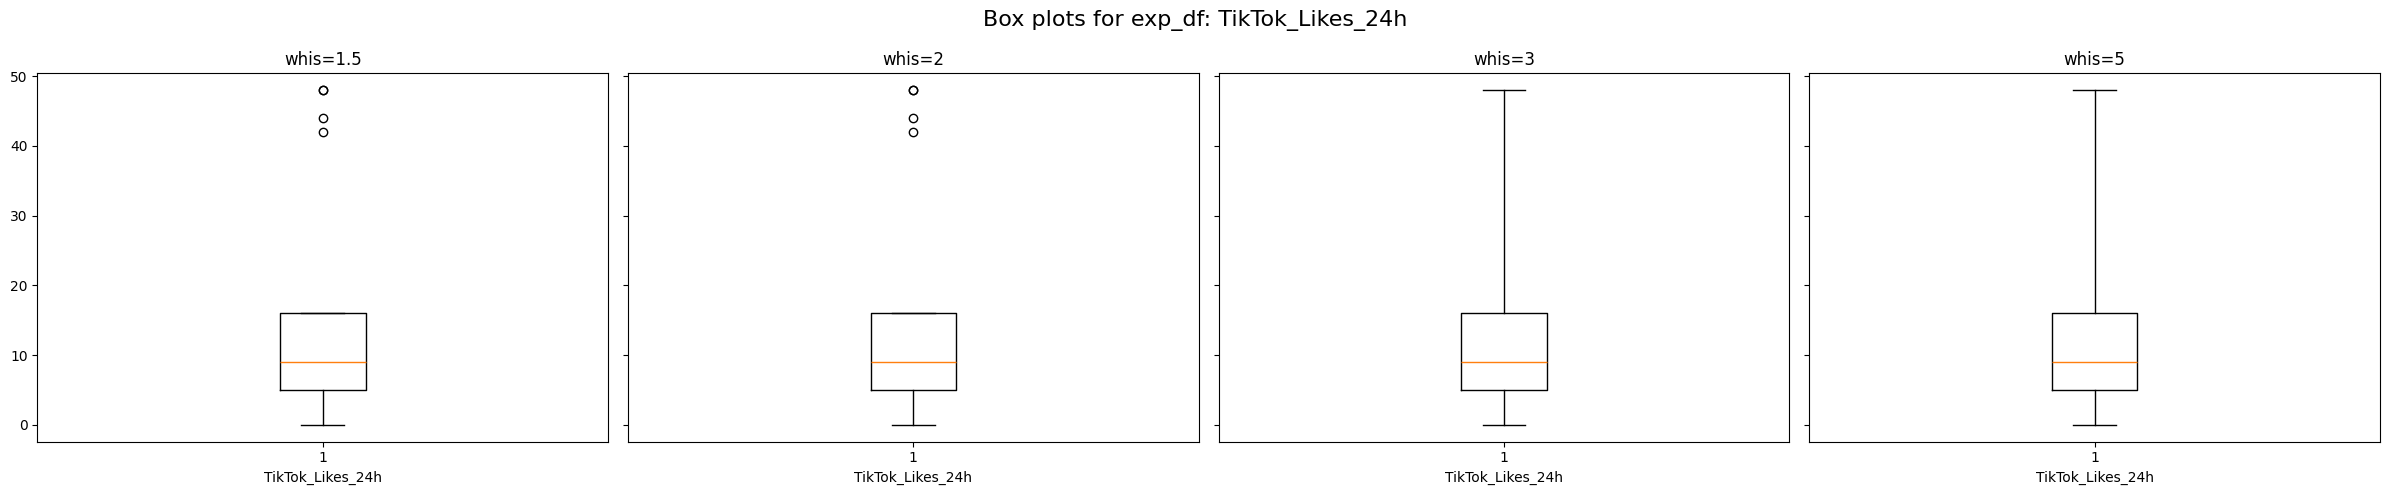

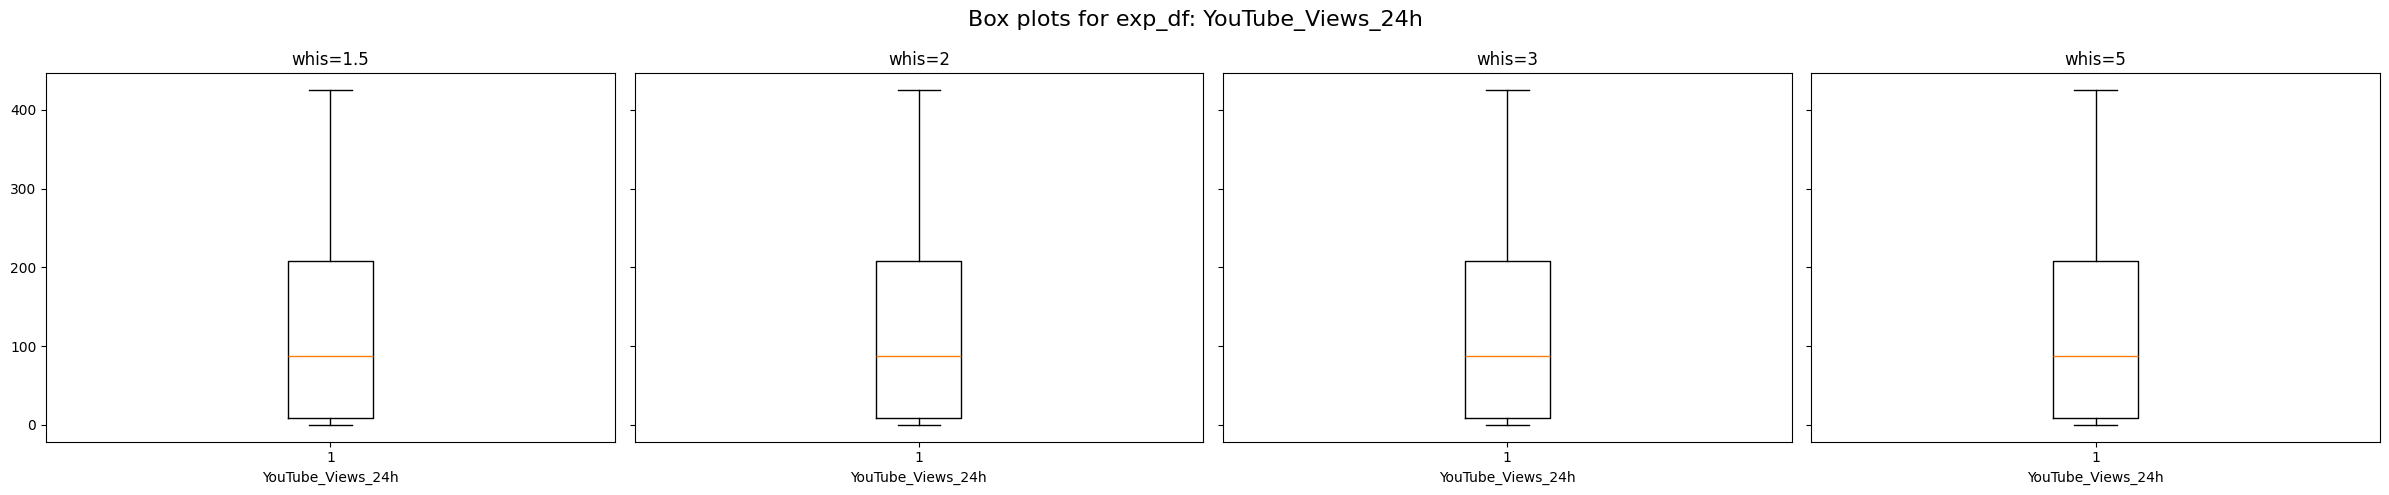

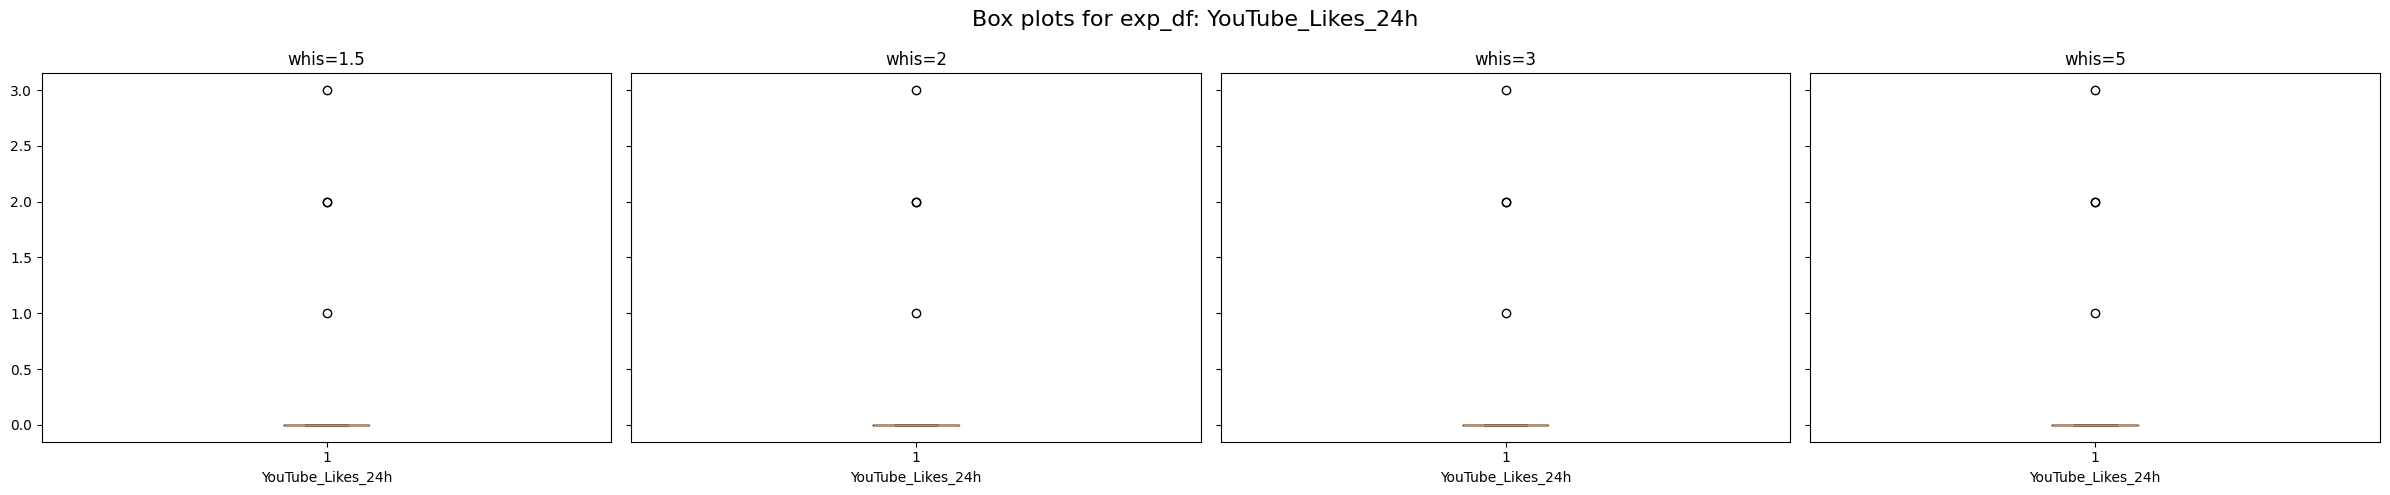

In [86]:


# Only model-level numeric cols (only experiment-level metrics)
numeric_cols_exp = [
    'X_Impressions_24h',
    'Input_Word_Count',
    'X_followers',
    'TikTok_followers',
    'YouTube_followers',
    'Video_duration_s',
    'Song_BPM',
    'Lyrics_words',
    'X_Likes_24h',
    'X_Shares_24h',
    'TikTok_Views_24h',
    'TikTok_Likes_24h',
    'YouTube_Views_24h',
    'YouTube_Likes_24h'
]

# Keep only columns that actually exist in df
numerical_cols = [c for c in numeric_cols_exp if c in exp_df.columns]
missing = [c for c in numeric_cols_exp if c not in exp_df.columns]
if missing:
    print("Missing columns in df (skipped):")
    for c in missing:
        print(" -", c)

# Whisker values to test
whis_values = [1.5, 2, 3, 5]

for col in numerical_cols:
    fig, axes = plt.subplots(1, len(whis_values), figsize=(24, 5), sharey=True)

    for ax, whis in zip(axes, whis_values):
        ax.boxplot(exp_df[col].dropna(), whis=whis)
        ax.set_title(f"whis={whis}", fontsize=12)
        ax.set_xlabel(col, fontsize=10)
        ax.tick_params(labelsize=10)

    fig.suptitle(f"Box plots for exp_df: {col}", fontsize=16)
    plt.tight_layout()
    plt.show()

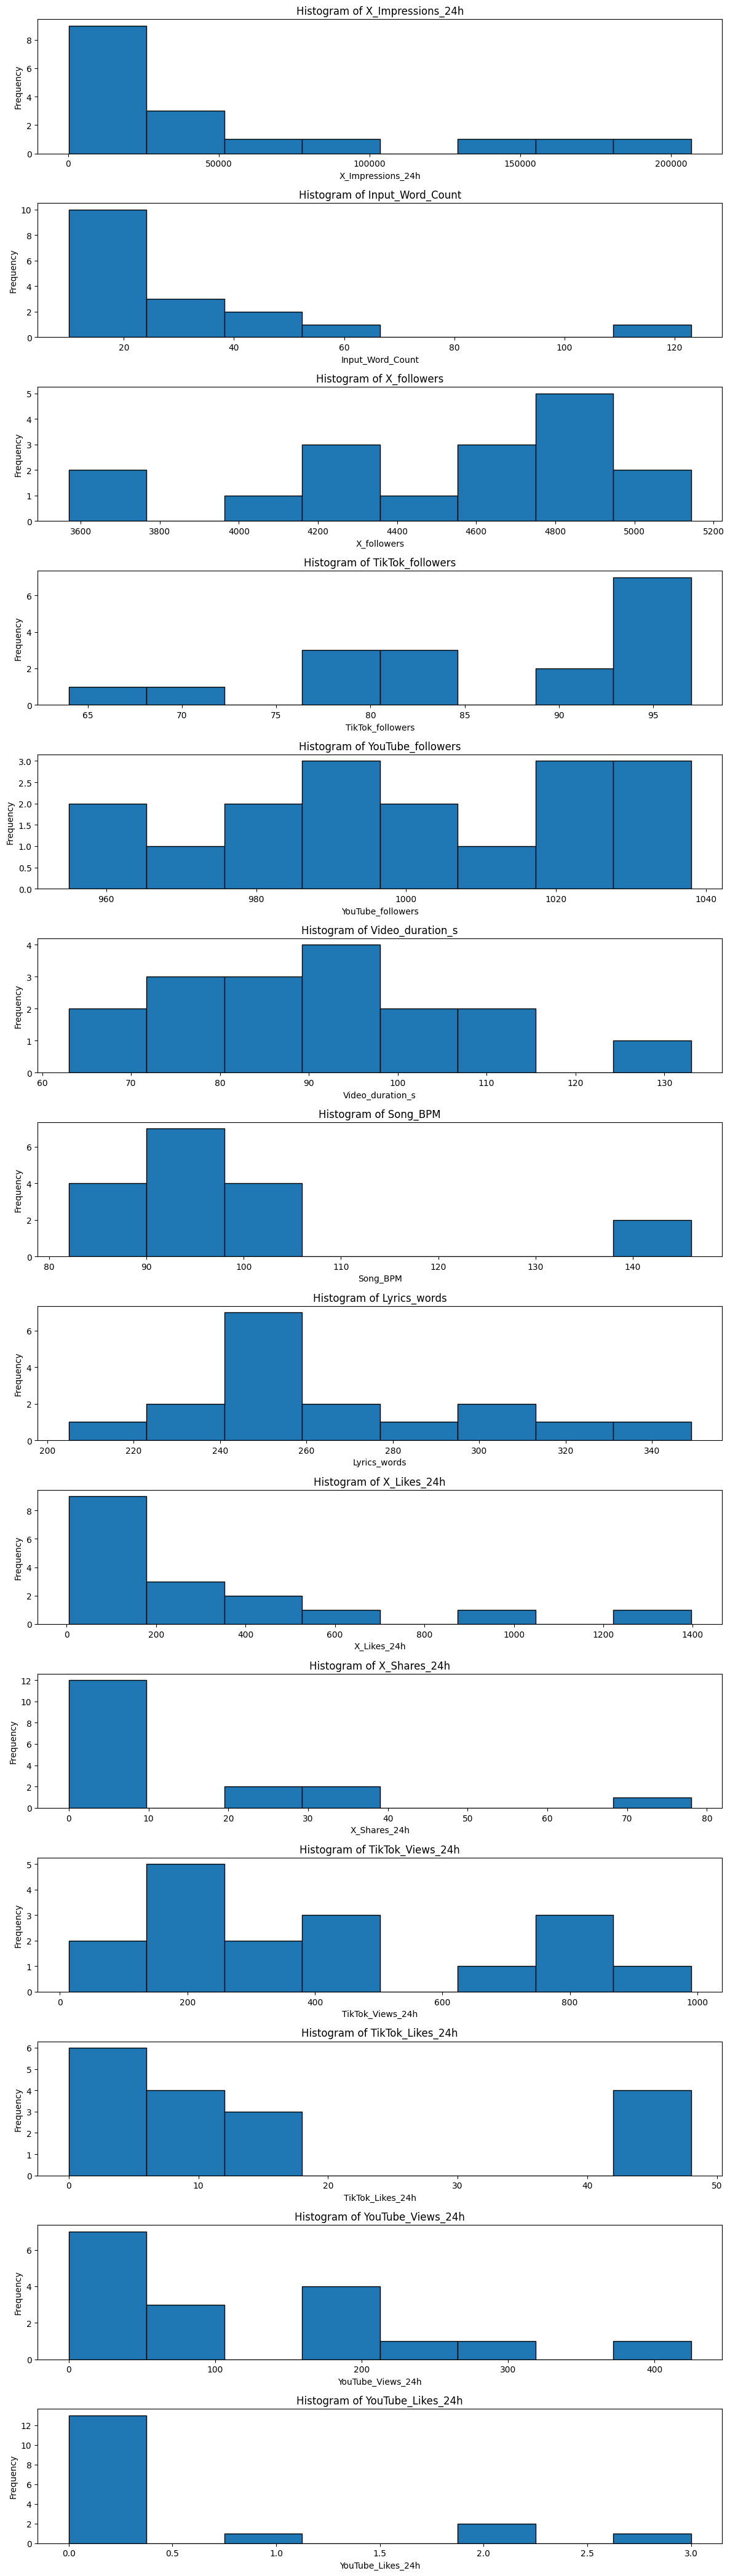

In [87]:


if len(numerical_cols) == 0:
    print("No numeric columns found to plot.")
else:
    n = len(numerical_cols)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3 * n))

    # If there's only 1 column, axes is not a list, normalize it
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numerical_cols):
        s = exp_df[col].dropna()

        # With only ~5 rows, keep bins small but safe
        bins = min(30, max(5, int(np.sqrt(len(s)) * 2)))

        ax.hist(s, bins=bins, edgecolor='black')
        ax.set_title(f"Histogram of {col}")
        ax.set_ylabel("Frequency")
        ax.set_xlabel(col)

    plt.tight_layout()
    plt.show()


In [96]:
# Get basic statistics for numerical columns
pd.set_option("display.max_columns", None)
print(exp_df.describe())

# Get statistics for categorical columns
print(exp_df.describe(include=['object']))

       X_Impressions_24h  Experiment_Type  Visual_Type  Input_Word_Count  \
count          17.000000             17.0         17.0         17.000000   
mean        50188.176471         0.235294     0.764706         31.294118   
min           214.000000              0.0          0.0         10.000000   
25%          5502.000000              0.0          1.0         18.000000   
50%         24987.000000              0.0          1.0         20.000000   
75%         75948.000000              0.0          1.0         36.000000   
max        206661.000000              1.0          1.0        123.000000   
std         63804.350549         0.437237     0.437237         26.881138   

                      Date_Generated                    Date_posted  \
count                             17                             17   
mean   2026-01-03 07:03:31.764705792  2026-01-06 18:21:10.588235264   
min              2025-12-10 00:00:00            2025-12-10 00:00:00   
25%              2025-12-18 00:

df

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     object        
 1   LLM Model                            68 non-null     object        
 2   Prompt                               68 non-null     object        
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[ns]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total 

In [95]:
# Get basic statistics for numerical columns
pd.set_option("display.max_columns", None)
print(df.describe())

# Get statistics for categorical columns
print(df.describe(include=['object']))

       Experiment Type  Visual type  LLM Reasoning Time (s)  \
count             68.0         68.0               68.000000   
mean          0.235294     0.764706               58.926471   
min                0.0          0.0                3.000000   
25%                0.0          1.0               12.000000   
50%                0.0          1.0               22.000000   
75%                0.0          1.0               71.250000   
max                1.0          1.0              466.000000   
std           0.427336     0.427336               81.005862   

       LLM Response Time (s)                 Date Generated  \
count              68.000000                             68   
mean              138.500000  2026-01-03 07:03:31.764705792   
min                 7.000000            2025-12-10 00:00:00   
25%                51.000000            2025-12-18 00:00:00   
50%               112.000000            2025-12-30 00:00:00   
75%               176.250000            2026-01-20 00:

<a name='1.3'></a>
## 1.3 - Data Exploration (EDA)

### Model Dataframe

In [102]:
df.head()

,Experiment ID,LLM Model,Prompt,Experiment Type,Visual type,LLM Reasoning Time (s),LLM Response Time (s),Date Generated,Time ET of the Generation,Reasoning Total words,Reasoning Total characters,Reasoning Total sentences,Reasoning top keyword,Reasoning top keyword repetitions,Input Word Count,Lines of HTML,Model Family,Platform,Code in Reasoning?,prompt_adherence_score (0-10),gemini_pa (0-10),functional_correctness_score (0-10),gemini_fc (0-10),ui_score (0-10),gemini_ui (0-10),Performance Score (0-10),gemini perf (0-10),Male / Female Song's Voice,Song Key,Song BPM,Song style,Lyrics number of words,LLM used for song,Suno version,Date posted,Day of the week posted,Time ET posted on X,X Followers posted,Tik Tok Followers posted,Youtube Followers posted,Video Duration (s),X Impressions (24 h),X Likes (24h),X Shares (24h),Tik Tok Views (24 h),Tik Tok Likes (24h),Youtube short views (24 h),Youtube short Likes (24h),Time ET of the Generation_hour,Time ET of the Generation_minute,Time ET posted on X_hour,Time ET posted on X_minute
0,flappy_bird_1210,gpt-5.1-extended-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,44,106,2025-12-10,17:01:00,326,2010,23,Game,12,13,427,GPT,1,0,10.0,10.0,9.5,10.0,7.5,9.0,9.20,9.75,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,1,20,19
1,flappy_bird_1210,gemini-3-pro,Make a game like flappy bird using HTML/CSS/JS...,1,1,17,44,2025-12-10,16:54:00,261,1534,19,I'm,9,13,324,Gemini,1,0,10.0,10.0,9.0,10.0,6.0,8.0,8.65,9.50,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,16,54,20,19
2,flappy_bird_1210,grok-4.1-thinking,Make a game like flappy bird using HTML/CSS/JS...,1,1,11,19,2025-12-10,17:50:00,114,704,6,Game,6,13,201,Grok,1,0,10.0,10.0,9.0,10.0,6.0,8.0,8.65,9.50,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,50,20,19
3,flappy_bird_1210,opus-4.5-thinking-32k,Make a game like flappy bird using HTML/CSS/JS...,1,1,61,124,2025-12-10,17:36:00,1363,12726,23,Pipes,18,13,503,Opus,0,1,10.0,10.0,9.5,10.0,8.0,10.0,9.33,10.00,1,G Major,102,"hip hop, pop",312,gemini-3-pro,1,2025-12-10,1,20:19:00,3570,64,955,133,135606,433,22,259,9,265,3,17,36,20,19
4,drifting_car_1213,gpt-5.2-extended-thinking,Create a 3D simulation of a formula 1 car perf...,0,1,23,102,2025-12-11,19:33:00,229,1374,16,Will,8,24,640,GPT,1,0,0.0,2.0,0.0,1.0,1.0,5.0,0.25,2.40,0,G minor,94,"hip hop, pop",205,gemini-3-pro,1,2025-12-13,0,07:55:00,3760,70,959,63,206661,1396,78,14,0,106,0,19,33,7,55


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Experiment ID                        68 non-null     object        
 1   LLM Model                            68 non-null     object        
 2   Prompt                               68 non-null     object        
 3   Experiment Type                      68 non-null     Int64         
 4   Visual type                          68 non-null     Int64         
 5   LLM Reasoning Time (s)               68 non-null     int64         
 6   LLM Response Time (s)                68 non-null     int64         
 7   Date Generated                       68 non-null     datetime64[ns]
 8   Time ET of the Generation            68 non-null     object        
 9   Reasoning Total words                68 non-null     int64         
 10  Reasoning Total 

#### Does prompt length correlate with model quality outcomes?

In [99]:
target_cols = [
    "prompt_adherence_score (0-10)",
    "gemini_pa (0-10)",
    "functional_correctness_score (0-10)",
    "gemini_fc (0-10)",
    "ui_score (0-10)",
    "gemini_ui (0-10)",
    "Performance Score (0-10)",
    "gemini perf (0-10)"
]

cols = ["Input Word Count"] + target_cols
eda_df = df[cols].copy()

eda_df.describe()


,Input Word Count,prompt_adherence_score (0-10),gemini_pa (0-10),functional_correctness_score (0-10),gemini_fc (0-10),ui_score (0-10),gemini_ui (0-10),Performance Score (0-10),gemini perf (0-10)
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,31.294118,7.780882,8.308824,7.583824,8.367647,7.429412,7.720588,7.625882,8.182353
std,26.272430,2.667788,2.819216,2.673117,2.591055,2.383592,2.291096,2.510267,2.341191
min,10.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,18.000000,7.000000,7.000000,7.000000,8.000000,6.875000,6.000000,7.267500,7.475000
50%,20.000000,9.000000,10.000000,8.950000,10.000000,8.000000,8.500000,8.605000,9.150000
75%,36.000000,9.500000,10.000000,9.275000,10.000000,9.000000,9.000000,9.200000,9.750000
max,123.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


                                     Input Word Count
ui_score (0-10)                              0.174228
functional_correctness_score (0-10)          0.171958
gemini_fc (0-10)                             0.148796
Performance Score (0-10)                     0.103182
gemini_ui (0-10)                             0.094867
prompt_adherence_score (0-10)               -0.005519
gemini perf (0-10)                          -0.021280
gemini_pa (0-10)                            -0.212024


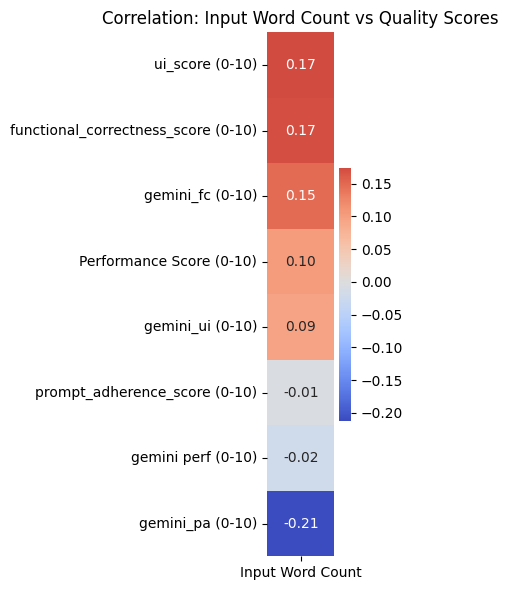

In [100]:
import seaborn as sns

# Correlation coefficients
corr = eda_df.corr()[['Input Word Count']].drop('Input Word Count').sort_values('Input Word Count', ascending=False)
print(corr)

# Heatmap for visual clarity
plt.figure(figsize=(4, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: Input Word Count vs Quality Scores')
plt.tight_layout()
plt.show()

#### Does prompt length correlate with X Impressions (24h)?

                  Input_Word_Count  X_Impressions
Input_Word_Count          1.000000      -0.269172
X_Impressions            -0.269172       1.000000


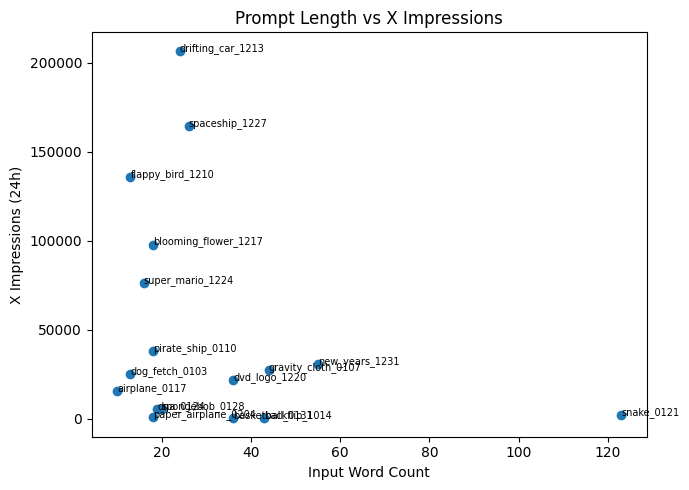

In [101]:
# Aggregate to experiment level first
exp_df = df.groupby('Experiment ID').agg(
    Input_Word_Count=('Input Word Count', 'first'),
    X_Impressions=('X Impressions (24 h)', 'first')
).reset_index()

# Correlation
corr = exp_df[['Input_Word_Count', 'X_Impressions']].corr()
print(corr)

# Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(exp_df['Input_Word_Count'], exp_df['X_Impressions'])
for _, row in exp_df.iterrows():
    plt.annotate(row['Experiment ID'], (row['Input_Word_Count'], row['X_Impressions']), fontsize=7)
plt.xlabel('Input Word Count')
plt.ylabel('X Impressions (24h)')
plt.title('Prompt Length vs X Impressions')
plt.tight_layout()
plt.show()

#### Does gemini score himself better?

Gemini scoring itself:
gemini_pa (0-10)      9.118
gemini_fc (0-10)      8.706
gemini_ui (0-10)      7.647
gemini perf (0-10)    8.606
dtype: float64

Gemini scoring others:
gemini_pa (0-10)      8.039
gemini_fc (0-10)      8.255
gemini_ui (0-10)      7.745
gemini perf (0-10)    8.041
dtype: float64

Difference (self - others):
gemini_pa (0-10)      1.078
gemini_fc (0-10)      0.451
gemini_ui (0-10)     -0.098
gemini perf (0-10)    0.565
dtype: float64


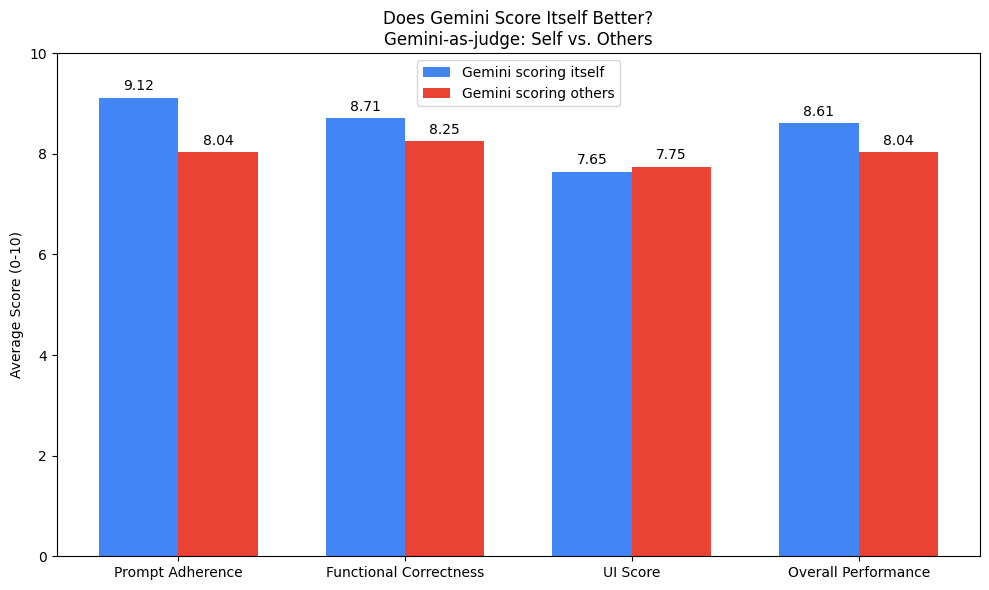

In [105]:
import numpy as np

gemini_self = df[df['Model Family'] == 'Gemini'][['gemini_pa (0-10)', 'gemini_fc (0-10)', 'gemini_ui (0-10)', 'gemini perf (0-10)']].mean()
gemini_others = df[df['Model Family'] != 'Gemini'][['gemini_pa (0-10)', 'gemini_fc (0-10)', 'gemini_ui (0-10)', 'gemini perf (0-10)']].mean()

print("Gemini scoring itself:")
print(gemini_self.round(3))
print("\nGemini scoring others:")
print(gemini_others.round(3))
print("\nDifference (self - others):")
print((gemini_self - gemini_others).round(3))

metrics = ['Prompt Adherence', 'Functional Correctness', 'UI Score', 'Overall Performance']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, gemini_self.values, width, label='Gemini scoring itself', color='#4285F4')
bars2 = ax.bar(x + width/2, gemini_others.values, width, label='Gemini scoring others', color='#EA4335')

ax.set_ylim(0, 10)
ax.set_ylabel('Average Score (0-10)')
ax.set_title('Does Gemini Score Itself Better?\nGemini-as-judge: Self vs. Others')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [106]:
from scipy.stats import wilcoxon

gemini_rows = df[df['Model Family'] == 'Gemini']

for metric, human_col, gemini_col in [
    ('Prompt Adherence', 'prompt_adherence_score (0-10)', 'gemini_pa (0-10)'),
    ('Functional Correctness', 'functional_correctness_score (0-10)', 'gemini_fc (0-10)'),
    ('UI Score', 'ui_score (0-10)', 'gemini_ui (0-10)'),
    ('Overall Performance', 'Performance Score (0-10)', 'gemini perf (0-10)')
]:
    human_scores = gemini_rows[human_col]
    gemini_scores = gemini_rows[gemini_col]

    stat, p = wilcoxon(gemini_scores, human_scores)
    diff = (gemini_scores - human_scores).mean()

    print(f"{metric}")
    print(f"  Gemini mean: {gemini_scores.mean():.3f} | Human mean: {human_scores.mean():.3f} | Diff: {diff:+.3f}")
    print(f"  Wilcoxon stat: {stat:.3f} | p-value: {p:.4f} {'*** SIGNIFICANT' if p < 0.05 else '(not significant)'}")
    print()

Prompt Adherence
  Gemini mean: 9.118 | Human mean: 8.176 | Diff: +0.941
  Wilcoxon stat: 28.000 | p-value: 0.1205 (not significant)

Functional Correctness
  Gemini mean: 8.706 | Human mean: 7.959 | Diff: +0.747
  Wilcoxon stat: 19.500 | p-value: 0.0372 *** SIGNIFICANT

UI Score
  Gemini mean: 7.647 | Human mean: 7.647 | Diff: +0.000
  Wilcoxon stat: 60.500 | p-value: 0.6944 (not significant)

Overall Performance
  Gemini mean: 8.606 | Human mean: 7.969 | Diff: +0.636
  Wilcoxon stat: 51.000 | p-value: 0.2273 (not significant)



#### % reasoning vs total

Reasoning Time as % of Total Inference Time:
               mean  median    std
Model Family                      
GPT           25.55   17.05  19.17
Gemini        31.31   32.26   8.45
Grok          73.37   84.15  19.31
Opus          31.21   38.41  19.15

Mean Reasoning Time (s) vs Mean Response Time (s):
              LLM Reasoning Time (s)  LLM Response Time (s)
Model Family                                               
GPT                            80.71                 247.18
Gemini                         14.65                  46.24
Grok                           91.88                 112.24
Opus                           48.47                 148.35


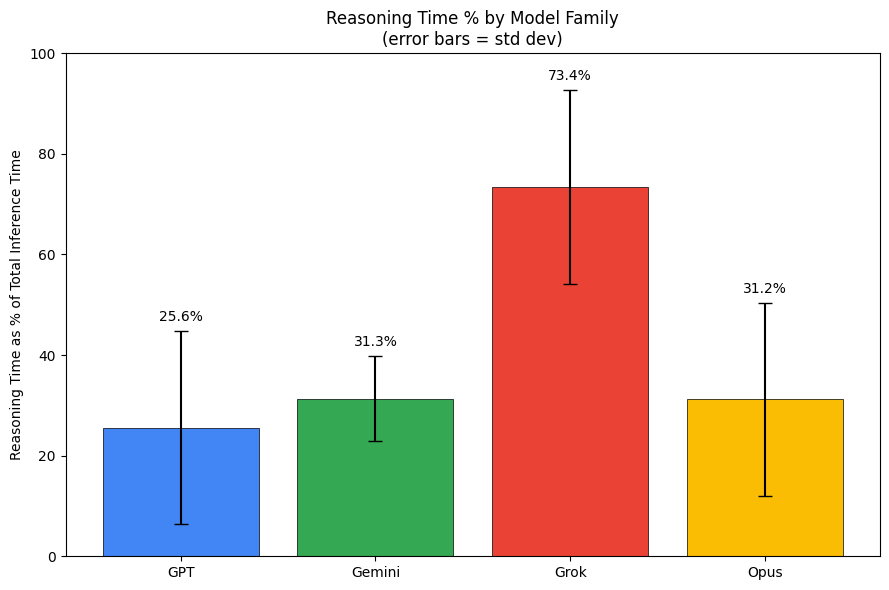

In [107]:
# Calculate reasoning percentage per row
df['reasoning_pct'] = (df['LLM Reasoning Time (s)'] / df['LLM Response Time (s)']) * 100

# Aggregate by model family
reasoning_stats = df.groupby('Model Family')['reasoning_pct'].agg(['mean', 'median', 'std']).round(2)
print("Reasoning Time as % of Total Inference Time:")
print(reasoning_stats)

# Also print raw means for context
print("\nMean Reasoning Time (s) vs Mean Response Time (s):")
print(df.groupby('Model Family')[['LLM Reasoning Time (s)', 'LLM Response Time (s)']].mean().round(2))

# Plot
families = reasoning_stats.index
means = reasoning_stats['mean']
stds = reasoning_stats['std']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(families, means, yerr=stds, capsize=5,
              color=['#4285F4', '#34A853', '#EA4335', '#FBBC04'],
              edgecolor='black', linewidth=0.5)

ax.set_ylabel('Reasoning Time as % of Total Inference Time')
ax.set_title('Reasoning Time % by Model Family\n(error bars = std dev)')
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt='%.1f%%', padding=5)

plt.tight_layout()
plt.show()

#### Is reasoning time related to performance?

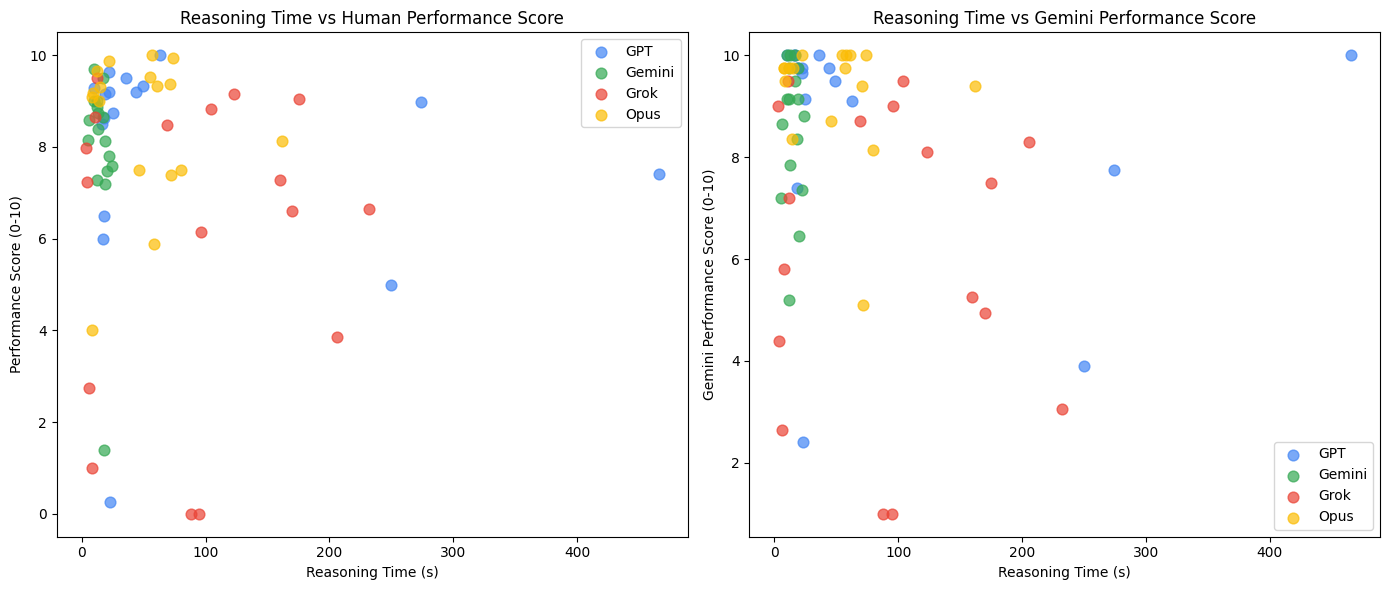

Correlations: Reasoning Time vs Performance

GPT | Pearson: r=-0.104 p=0.692 | Spearman: r=0.107 p=0.682
Gemini | Pearson: r=-0.326 p=0.201 | Spearman: r=-0.540 p=0.025
Grok | Pearson: r=0.058 p=0.826 | Spearman: r=0.067 p=0.797
Opus | Pearson: r=-0.026 p=0.922 | Spearman: r=0.021 p=0.937



(np.float64(0.020858895705521473), np.float64(0.9366663108546955))

In [108]:

# Scatter plot: reasoning time vs performance score, colored by model family
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Opus': '#FBBC04'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model, group in df.groupby('Model Family'):
    axes[0].scatter(group['LLM Reasoning Time (s)'], group['Performance Score (0-10)'],
                    label=model, color=colors[model], alpha=0.7, s=60)
    axes[1].scatter(group['LLM Reasoning Time (s)'], group['gemini perf (0-10)'],
                    label=model, color=colors[model], alpha=0.7, s=60)

axes[0].set_xlabel('Reasoning Time (s)')
axes[0].set_ylabel('Performance Score (0-10)')
axes[0].set_title('Reasoning Time vs Human Performance Score')
axes[0].legend()

axes[1].set_xlabel('Reasoning Time (s)')
axes[1].set_ylabel('Gemini Performance Score (0-10)')
axes[1].set_title('Reasoning Time vs Gemini Performance Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation
from scipy.stats import pearsonr, spearmanr

print("Correlations: Reasoning Time vs Performance\n")
for model in df['Model Family'].unique():
    subset = df[df['Model Family'] == model]
    pr, pp = pearsonr(subset['LLM Reasoning Time (s)'], subset['Performance Score (0-10)'])
    sr, sp = spearmanr(subset['LLM Reasoning Time (s)'], subset['Performance Score (0-10)'])
    print(f"{model} | Pearson: r={pr:.3f} p={pp:.3f} | Spearman: r={sr:.3f} p={sp:.3f}")

print()
# Overall correlation
pr, pp = pearsonr(df['LLM Reasoning Time (s)'], df['Performance Score (0-10)'])
sr, sp

#### Is total inference time related to performance?

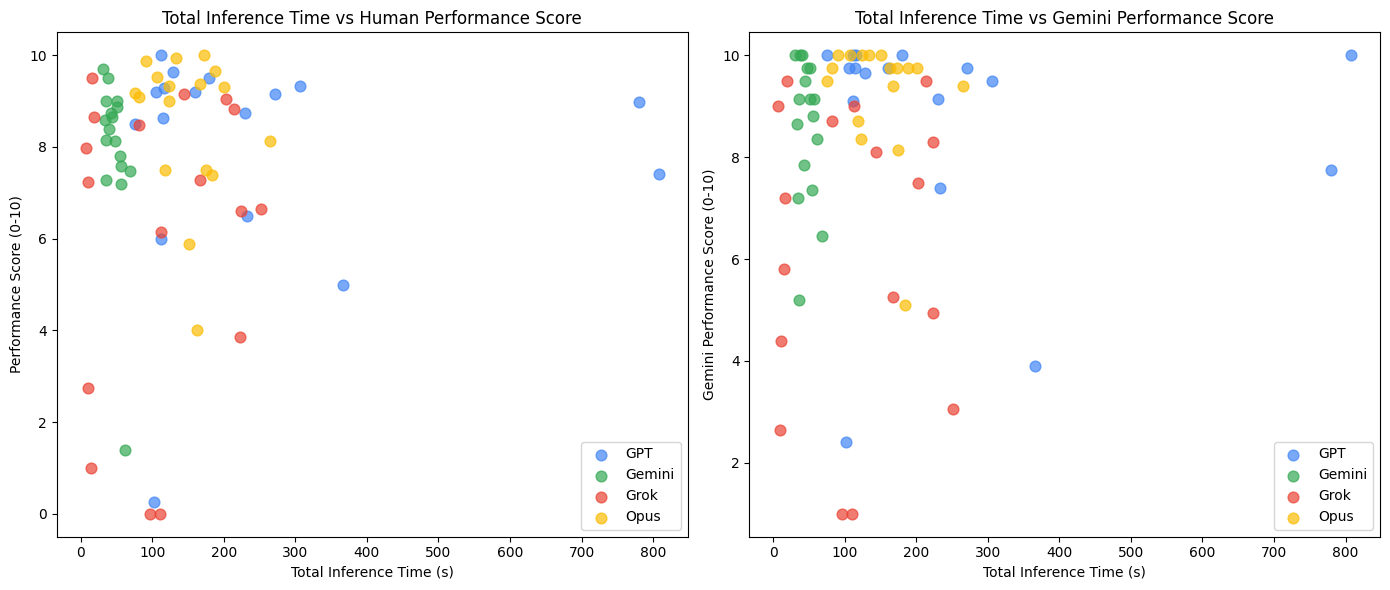

Correlations: Total Inference Time vs Performance

GPT | Pearson: r=0.019 p=0.942 | Spearman: r=-0.022 p=0.933
Gemini | Pearson: r=-0.545 p=0.024 | Spearman: r=-0.577 p=0.015
Grok | Pearson: r=0.124 p=0.636 | Spearman: r=0.058 p=0.826
Opus | Pearson: r=-0.215 p=0.406 | Spearman: r=-0.120 p=0.646

Overall | Pearson: r=0.052 p=0.676 | Spearman: r=0.056 p=0.650


In [109]:
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Opus': '#FBBC04'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model, group in df.groupby('Model Family'):
    axes[0].scatter(group['LLM Response Time (s)'], group['Performance Score (0-10)'],
                    label=model, color=colors[model], alpha=0.7, s=60)
    axes[1].scatter(group['LLM Response Time (s)'], group['gemini perf (0-10)'],
                    label=model, color=colors[model], alpha=0.7, s=60)

axes[0].set_xlabel('Total Inference Time (s)')
axes[0].set_ylabel('Performance Score (0-10)')
axes[0].set_title('Total Inference Time vs Human Performance Score')
axes[0].legend()

axes[1].set_xlabel('Total Inference Time (s)')
axes[1].set_ylabel('Gemini Performance Score (0-10)')
axes[1].set_title('Total Inference Time vs Gemini Performance Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Correlations: Total Inference Time vs Performance\n")
for model in df['Model Family'].unique():
    subset = df[df['Model Family'] == model]
    pr, pp = pearsonr(subset['LLM Response Time (s)'], subset['Performance Score (0-10)'])
    sr, sp = spearmanr(subset['LLM Response Time (s)'], subset['Performance Score (0-10)'])
    print(f"{model} | Pearson: r={pr:.3f} p={pp:.3f} | Spearman: r={sr:.3f} p={sp:.3f}")

print()
pr, pp = pearsonr(df['LLM Response Time (s)'], df['Performance Score (0-10)'])
sr, sp = spearmanr(df['LLM Response Time (s)'], df['Performance Score (0-10)'])
print(f"Overall | Pearson: r={pr:.3f} p={pp:.3f} | Spearman: r={sr:.3f} p={sp:.3f}")

#### Analisis per model

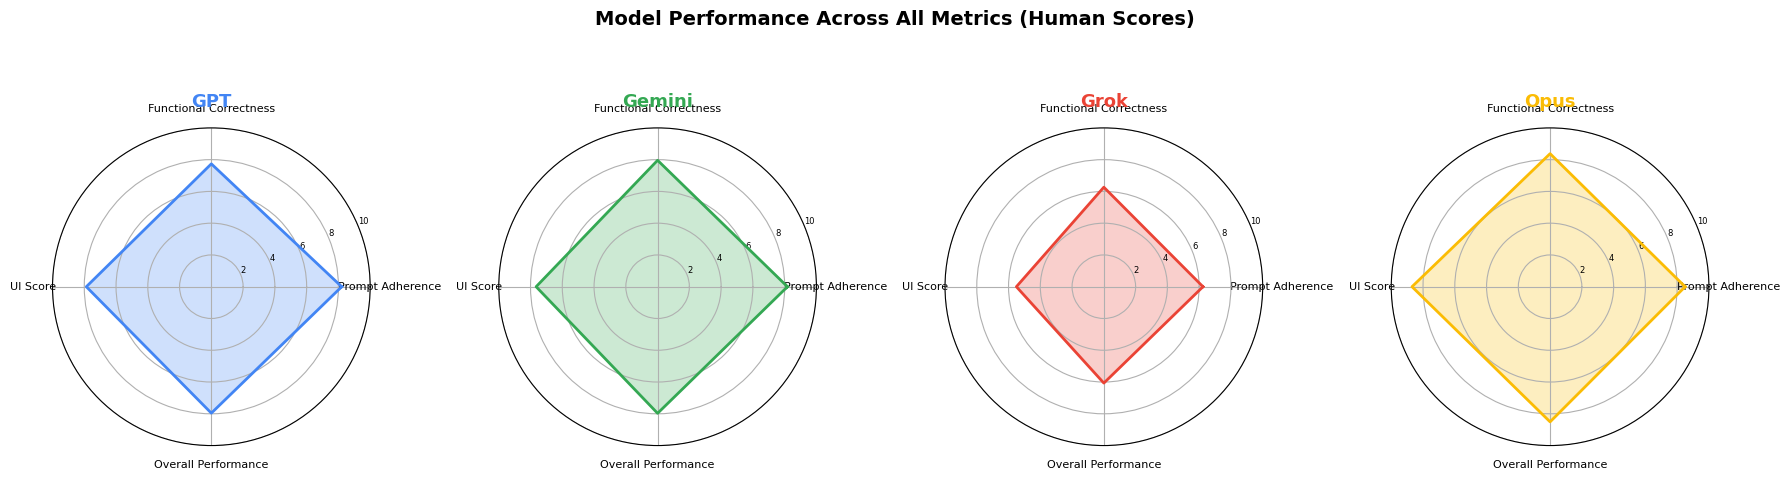

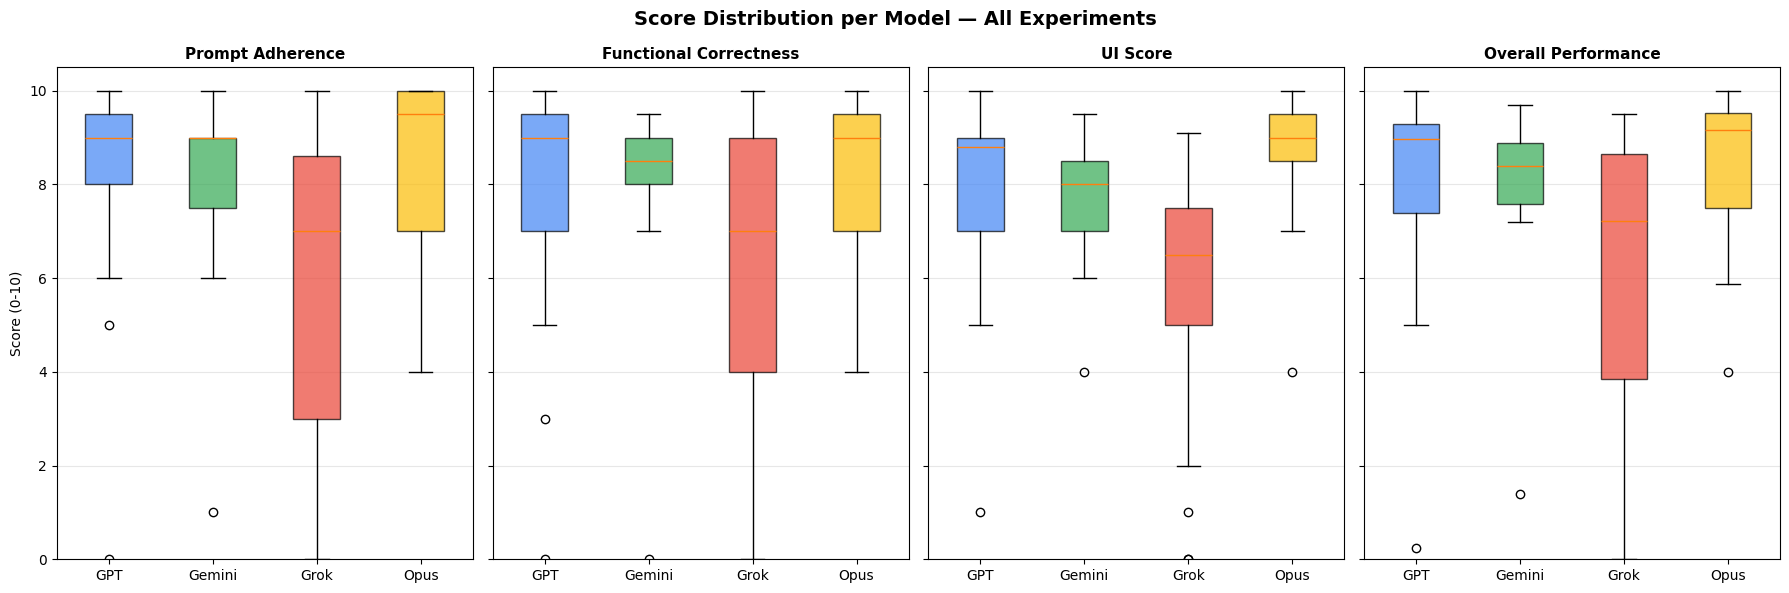


Mean Scores per Model Family:
              Prompt Adherence  Functional Correctness  UI Score  \
Model Family                                                       
GPT                       8.21                    7.74      7.87   
Gemini                    8.18                    7.96      7.65   
Grok                      6.24                    6.26      5.51   
Opus                      8.50                    8.38      8.69   

              Overall Performance  
Model Family                       
GPT                          7.96  
Gemini                       7.97  
Grok                         6.07  
Opus                         8.51  


In [110]:
metrics = [
    'prompt_adherence_score (0-10)',
    'functional_correctness_score (0-10)',
    'ui_score (0-10)',
    'Performance Score (0-10)'
]
metric_labels = ['Prompt Adherence', 'Functional Correctness', 'UI Score', 'Overall Performance']
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Opus': '#FBBC04'}
models = ['GPT', 'Gemini', 'Grok', 'Opus']

# --- Plot 1: Radar / Spider Chart per model ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for ax, model in zip(axes, models):
    subset = df[df['Model Family'] == model]
    means = [subset[m].mean() for m in metrics]
    means += means[:1]

    ax.plot(angles, means, color=colors[model], linewidth=2)
    ax.fill(angles, means, color=colors[model], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, size=8)
    ax.set_ylim(0, 10)
    ax.set_title(model, size=13, fontweight='bold', pad=15, color=colors[model])
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_yticklabels(['2', '4', '6', '8', '10'], size=6)

plt.suptitle('Model Performance Across All Metrics (Human Scores)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Box plot per model per metric ---
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for ax, metric, label in zip(axes, metrics, metric_labels):
    data = [df[df['Model Family'] == m][metric].values for m in models]
    bp = ax.boxplot(data, patch_artist=True, notch=False)
    for patch, model in zip(bp['boxes'], models):
        patch.set_facecolor(colors[model])
        patch.set_alpha(0.7)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 10.5)
    ax.set_ylabel('Score (0-10)' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Score Distribution per Model — All Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\nMean Scores per Model Family:")
print(df.groupby('Model Family')[metrics].mean().round(2).rename(columns=dict(zip(metrics, metric_labels))))

#### What exp took each model the longest inference and reasoning time?

In [123]:
# Find the index of the max reasoning time for each model family
idx_max_reasoning = df.groupby('Model Family')['LLM Reasoning Time (s)'].idxmax()
longest_reasoning = df.loc[idx_max_reasoning, [
    'Model Family', 'Experiment ID', 'LLM Reasoning Time (s)', 'LLM Response Time (s)'
]].sort_values(by='LLM Reasoning Time (s)', ascending=False)

# Find the index of the max total inference (response) time for each model family
idx_max_inference = df.groupby('Model Family')['LLM Response Time (s)'].idxmax()
longest_inference = df.loc[idx_max_inference, [
    'Model Family', 'Experiment ID', 'LLM Response Time (s)', 'LLM Reasoning Time (s)'
]].sort_values(by='LLM Response Time (s)', ascending=False)

print("--- Longest Reasoning Time per Model Family ---")
print(longest_reasoning.to_string(index=False))

print("\n--- Longest Total Inference Time per Model Family ---")
print(longest_inference.to_string(index=False))

--- Longest Reasoning Time per Model Family ---
Model Family   Experiment ID  LLM Reasoning Time (s)  LLM Response Time (s)
         GPT   backflip_1014                     466                    808
        Grok basketball_0131                     232                    252
        Opus   backflip_1014                     162                    265
      Gemini basketball_0131                      24                     56

--- Longest Total Inference Time per Model Family ---
Model Family   Experiment ID  LLM Response Time (s)  LLM Reasoning Time (s)
         GPT   backflip_1014                    808                     466
        Opus   backflip_1014                    265                     162
        Grok basketball_0131                    252                     232
      Gemini      snake_0121                     69                      20


#### What exp took each model the longest code? (HTML lines)

--- Longest HTML Output per Model Family ---
Model Family       Experiment ID  Lines of HTML
         GPT          snake_0121           1422
        Opus       airplane_0117           1254
      Gemini paper_airplane_0204            509
        Grok          snake_0121            366


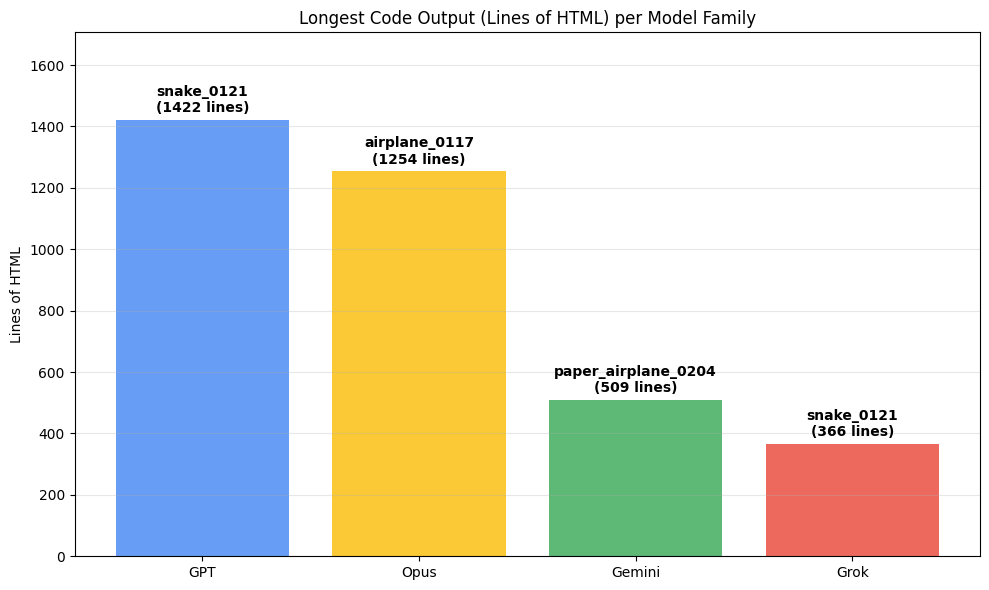

In [125]:
# Find the index of the max HTML lines for each model family
idx_max_html = df.groupby('Model Family')['Lines of HTML'].idxmax()
longest_html = df.loc[idx_max_html, [
    'Model Family', 'Experiment ID', 'Lines of HTML'
]].sort_values(by='Lines of HTML', ascending=False)

print("--- Longest HTML Output per Model Family ---")
print(longest_html.to_string(index=False))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Opus': '#FBBC04'}
bar_colors = [colors.get(model, '#888888') for model in longest_html['Model Family']]

bars = ax.bar(longest_html['Model Family'], longest_html['Lines of HTML'], color=bar_colors, alpha=0.8)

# Add the experiment ID and line count on top of each bar
for bar, exp_id, lines in zip(bars, longest_html['Experiment ID'], longest_html['Lines of HTML']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15,
            f"{exp_id}\n({lines} lines)",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Lines of HTML')
ax.set_title('Longest Code Output (Lines of HTML) per Model Family')
# Add some headroom so the text doesn't get cut off
ax.set_ylim(0, longest_html['Lines of HTML'].max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Correlation of lengh of code vs performance?

Correlation: Lines of HTML vs Performance
Pearson:  r=0.185, p=0.131
Spearman: r=0.243, p=0.046


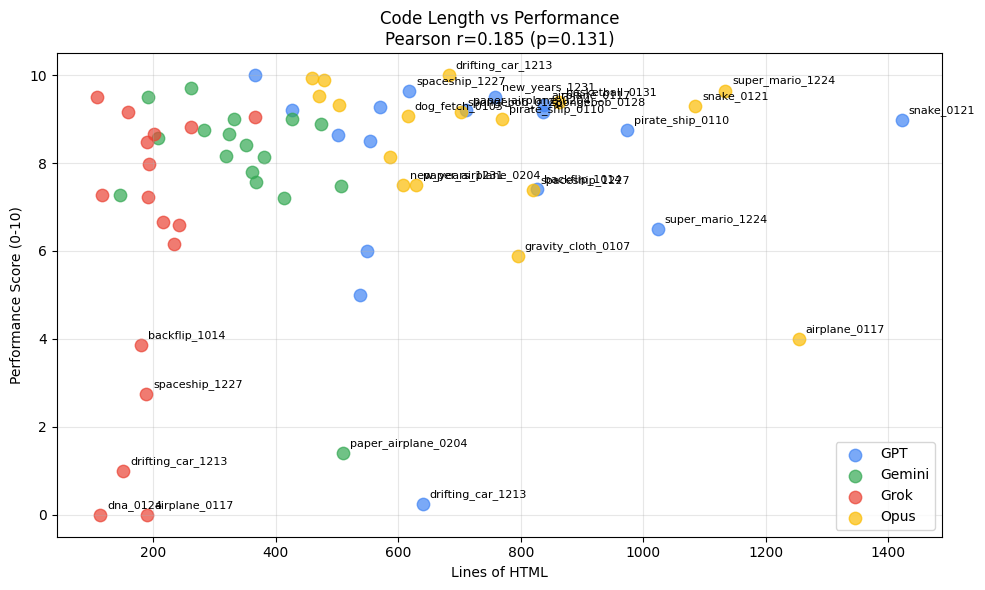

In [126]:
# Calculate correlations
pr, pp = pearsonr(df['Lines of HTML'], df['Performance Score (0-10)'])
sr, sp = spearmanr(df['Lines of HTML'], df['Performance Score (0-10)'])

print(f"Correlation: Lines of HTML vs Performance")
print(f"Pearson:  r={pr:.3f}, p={pp:.3f}")
print(f"Spearman: r={sr:.3f}, p={sp:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'GPT': '#4285F4', 'Gemini': '#34A853', 'Grok': '#EA4335', 'Opus': '#FBBC04'}

for model, group in df.groupby('Model Family'):
    ax.scatter(group['Lines of HTML'], group['Performance Score (0-10)'],
               label=model, color=colors[model], alpha=0.7, s=80)

# Annotate a few outliers or high leverage points (optional, or all)
for _, row in df.iterrows():
    # Annotate only if lines > 800 or performance < 4 to keep it clean, or annotate all:
    if row['Lines of HTML'] > 600 or row['Performance Score (0-10)'] < 5:
        ax.annotate(row['Experiment ID'], (row['Lines of HTML'], row['Performance Score (0-10)']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Lines of HTML')
ax.set_ylabel('Performance Score (0-10)')
ax.set_title(f'Code Length vs Performance\nPearson r={pr:.3f} (p={pp:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Experiment Dataframe

In [116]:
exp_df.head()

,Experiment ID,X_Impressions_24h,Prompt,Experiment_Type,Visual_Type,Input_Word_Count,Date_Generated,Date_posted,Day_of_week_posted,Time_posted_X_hour,Time_posted_X_minute,X_followers,TikTok_followers,YouTube_followers,Video_duration_s,MaleFemale_song_voice,Song_Key,Song_BPM,Song_style,Lyrics_words,LLM_used_for_song,Suno_version,Perf_mean,Perf_max,Perf_min,PA_mean,FC_mean,UI_mean,LinesHTML_mean,LinesHTML_max,ReasonTime_mean,RespTime_mean,Reason_words_mean,Reason_chars_mean,Reason_sentences_mean,Reason_topkw_rep_mean,gemini_pa_mean,gemini_fc_mean,gemini_ui_mean,gemini_perf_mean,X_Likes_24h,X_Shares_24h,TikTok_Views_24h,TikTok_Likes_24h,YouTube_Views_24h,YouTube_Likes_24h,Code_in_Reasoning_unique
0,airplane_0117,15636,Create a 3D simulation of an airplane landing ...,0,1,10,2026-01-15,2026-01-17,0,9,11,4787,95,1022,93,0,D♯ minor,96,"hip hop, pop",244,gpt-5.2-extended-thinking,0,5.4775,9.33,0.00,5.625,5.375,5.375,622.50,1254,39.50,153.50,225.25,1445.50,13.25,6.50,7.75,7.50,6.00,7.2250,128,3,990,44,188,1,0
1,backflip_1014,214,Create a slow-motion simulation of a stick-fig...,0,1,43,2026-01-10,2026-01-14,1,12,27,4755,94,1016,92,1,D♯ minor,146,"Trap, Southern hip-hop, Atlanta rap, Melodic r...",241,opus-4.5-thinking-32k,0,6.6450,8.13,3.85,6.625,6.500,6.875,501.75,827,213.25,338.25,1084.25,7011.75,46.75,21.25,10.00,9.00,8.25,9.2125,5,1,197,8,20,0,not unique
2,basketball_0131,346,Create a simulation of a basketball free-throw...,1,0,36,2026-01-31,2026-01-31,0,11,49,4961,97,1034,112,1,D♯ minor,87,"hip hop, pop",251,gemini-3-pro,1,7.1525,9.38,5.00,7.250,6.875,7.375,495.25,862,144.25,210.25,1282.00,9642.00,47.25,23.00,6.75,5.25,7.00,6.2875,8,0,197,3,165,0,not unique
3,blooming_flower_1217,97813,Create an animation of a single flower bloomin...,0,1,18,2025-12-12,2025-12-17,1,16,12,4082,77,974,93,1,A major,91,"hip hop, pop",304,gpt-5.2-extended-thinking,1,9.0275,9.93,7.98,9.250,9.375,8.175,366.50,554,25.75,62.00,375.75,2715.75,11.00,8.50,10.00,10.00,9.00,9.7500,650,20,180,5,284,0,not unique
4,dna_0124,5502,Create a rotating 3D animation of a Double Hel...,0,1,19,2026-01-22,2026-01-24,0,9,10,4836,96,1026,77,1,B minor,97,"hip hop, pop",229,opus-4.5-thinking-32k,0,6.2575,9.53,0.00,6.250,6.250,6.275,331.00,549,44.25,88.50,558.50,3976.75,23.25,10.00,7.75,7.75,7.75,7.7500,39,2,835,48,208,2,not unique


In [117]:
exp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Experiment ID             17 non-null     object        
 1   X_Impressions_24h         17 non-null     int64         
 2   Prompt                    17 non-null     object        
 3   Experiment_Type           17 non-null     Int64         
 4   Visual_Type               17 non-null     Int64         
 5   Input_Word_Count          17 non-null     int64         
 6   Date_Generated            17 non-null     datetime64[ns]
 7   Date_posted               17 non-null     datetime64[ns]
 8   Day_of_week_posted        17 non-null     Int64         
 9   Time_posted_X_hour        17 non-null     int32         
 10  Time_posted_X_minute      17 non-null     int32         
 11  X_followers               17 non-null     int64         
 12  TikTok_followers        

#### Is the song bpm related to impressions?

Pearson:  r=-0.257, p=0.319
Spearman: r=-0.163, p=0.533


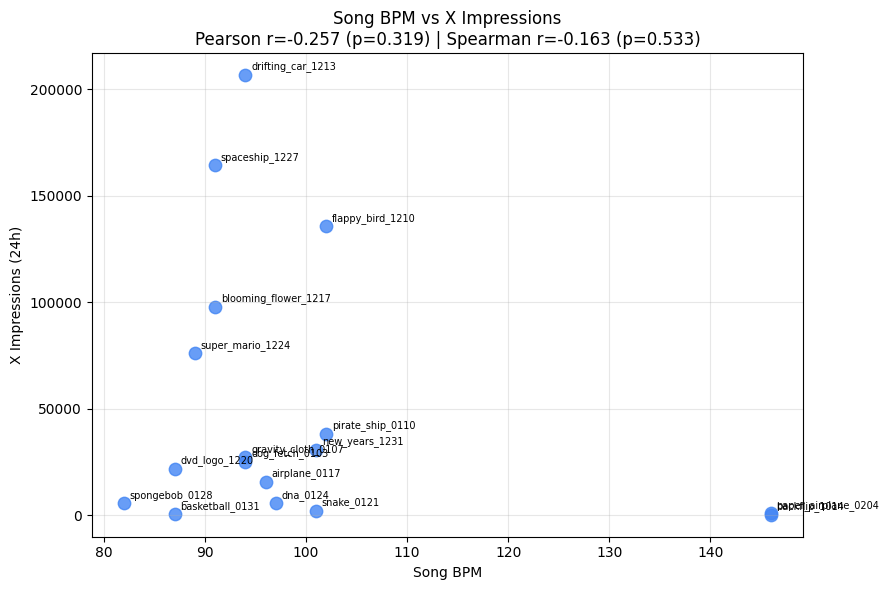

In [114]:
# Use Song_BPM and X_Impressions_24h from your rich exp_df
pr, pp = pearsonr(exp_df['Song_BPM'], exp_df['X_Impressions_24h'])
sr, sp = spearmanr(exp_df['Song_BPM'], exp_df['X_Impressions_24h'])
print(f"Pearson:  r={pr:.3f}, p={pp:.3f}")
print(f"Spearman: r={sr:.3f}, p={sp:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(exp_df['Song_BPM'], exp_df['X_Impressions_24h'], color='#4285F4', s=80, alpha=0.8)

for _, row in exp_df.iterrows():
    ax.annotate(row['Experiment ID'], (row['Song_BPM'], row['X_Impressions_24h']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Song BPM')
ax.set_ylabel('X Impressions (24h)')
ax.set_title(f'Song BPM vs X Impressions\nPearson r={pr:.3f} (p={pp:.3f}) | Spearman r={sr:.3f} (p={sp:.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Is the time of the day generated influencing performance?

In [120]:
# Pull directly from original df
gen_hour = df.groupby('Experiment ID')['Time ET of the Generation_hour'].first()
exp_df['Generation_Hour'] = exp_df['Experiment ID'].map(gen_hour)

print(exp_df['Generation_Hour'].value_counts())

Generation_Hour
18    3
16    3
10    2
19    2
17    2
14    2
12    1
13    1
11    1
Name: count, dtype: int64


Human Performance  | Pearson: r=-0.359 p=0.158 | Spearman: r=-0.343 p=0.177
Gemini Performance | Pearson: r=0.031 p=0.907 | Spearman: r=-0.091 p=0.727


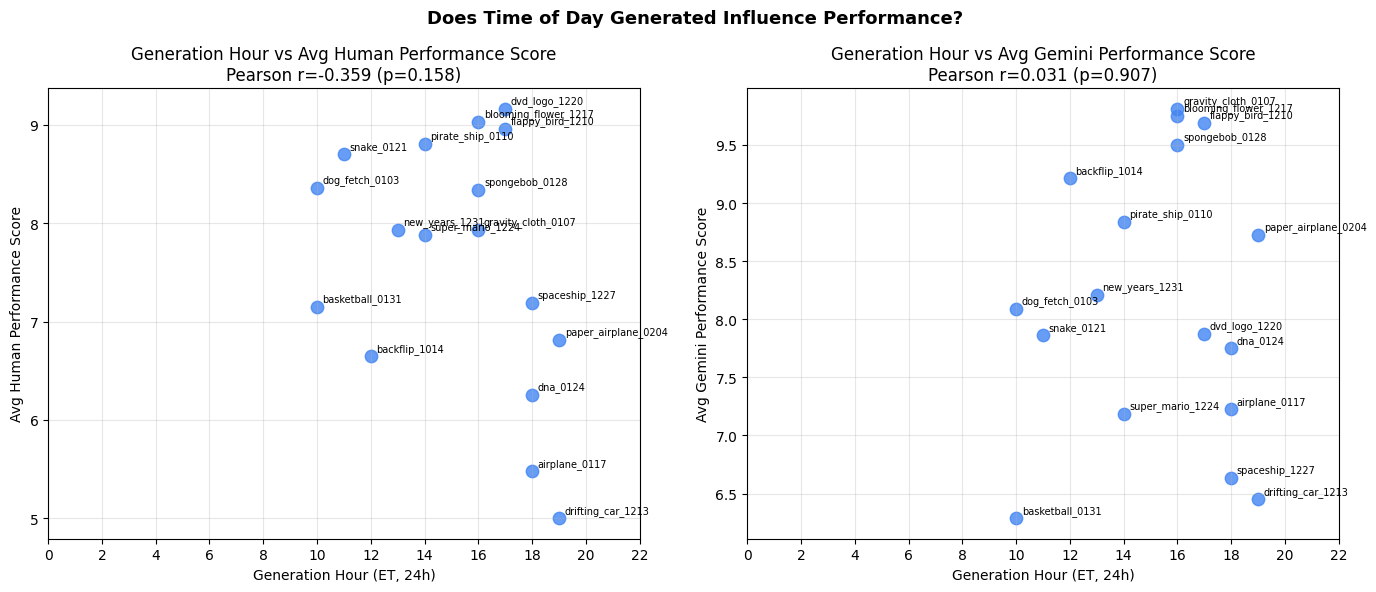

In [121]:
pr, pp = pearsonr(exp_df['Generation_Hour'], exp_df['Perf_mean'])
sr, sp = spearmanr(exp_df['Generation_Hour'], exp_df['Perf_mean'])
print(f"Human Performance  | Pearson: r={pr:.3f} p={pp:.3f} | Spearman: r={sr:.3f} p={sp:.3f}")

pr2, pp2 = pearsonr(exp_df['Generation_Hour'], exp_df['gemini_perf_mean'])
sr2, sp2 = spearmanr(exp_df['Generation_Hour'], exp_df['gemini_perf_mean'])
print(f"Gemini Performance | Pearson: r={pr2:.3f} p={pp2:.3f} | Spearman: r={sr2:.3f} p={sp2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_col, label, r, p in zip(
    axes,
    ['Perf_mean', 'gemini_perf_mean'],
    ['Avg Human Performance Score', 'Avg Gemini Performance Score'],
    [pr, pr2], [pp, pp2]
):
    ax.scatter(exp_df['Generation_Hour'], exp_df[y_col], color='#4285F4', s=80, alpha=0.8)
    for _, row in exp_df.iterrows():
        ax.annotate(row['Experiment ID'], (row['Generation_Hour'], row[y_col]),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel('Generation Hour (ET, 24h)')
    ax.set_ylabel(label)
    ax.set_title(f'Generation Hour vs {label}\nPearson r={r:.3f} (p={p:.3f})')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

plt.suptitle('Does Time of Day Generated Influence Performance?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Is the song male female influencing impressions?

Male   | n=10 | mean=48420 | median=24462
Female | n=7 | mean=52713 | median=24987
Mann-Whitney U=30.5, p=0.6961 (not significant)


/tmp/ipython-input-2645135105.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([male, female], labels=['Male', 'Female'], patch_artist=True,


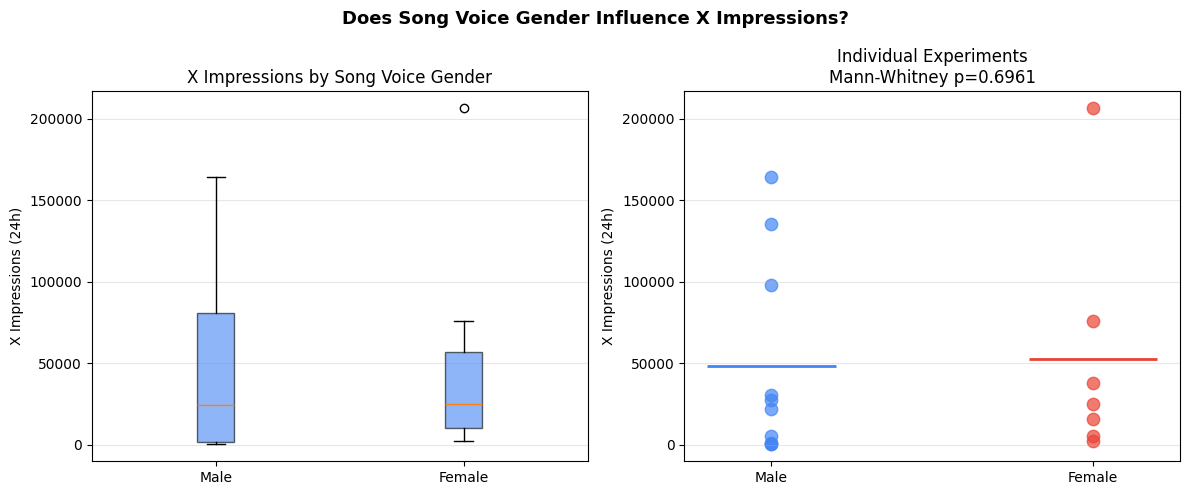

In [122]:
from scipy.stats import mannwhitneyu

# MaleFemale_song_voice is already binary encoded (1=m, 0=f)
male = exp_df[exp_df['MaleFemale_song_voice'] == 1]['X_Impressions_24h']
female = exp_df[exp_df['MaleFemale_song_voice'] == 0]['X_Impressions_24h']

stat, p = mannwhitneyu(male, female, alternative='two-sided')
print(f"Male   | n={len(male)} | mean={male.mean():.0f} | median={male.median():.0f}")
print(f"Female | n={len(female)} | mean={female.mean():.0f} | median={female.median():.0f}")
print(f"Mann-Whitney U={stat:.1f}, p={p:.4f} {'*** SIGNIFICANT' if p < 0.05 else '(not significant)'}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
axes[0].boxplot([male, female], labels=['Male', 'Female'], patch_artist=True,
                boxprops=dict(facecolor='#4285F4', alpha=0.6))
axes[0].set_ylabel('X Impressions (24h)')
axes[0].set_title('X Impressions by Song Voice Gender')
axes[0].grid(axis='y', alpha=0.3)

# Strip plot
for vals, x, color, label in [(male, 1, '#4285F4', 'Male'), (female, 2, '#EA4335', 'Female')]:
    axes[1].scatter([x] * len(vals), vals, alpha=0.7, s=80, color=color, label=label)
    axes[1].hlines(vals.mean(), x - 0.2, x + 0.2, color=color, linewidth=2)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].set_ylabel('X Impressions (24h)')
axes[1].set_title(f'Individual Experiments\nMann-Whitney p={p:.4f}')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Does Song Voice Gender Influence X Impressions?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Is the Day of the week and time the experiment is posted on X correlated with X impressions?

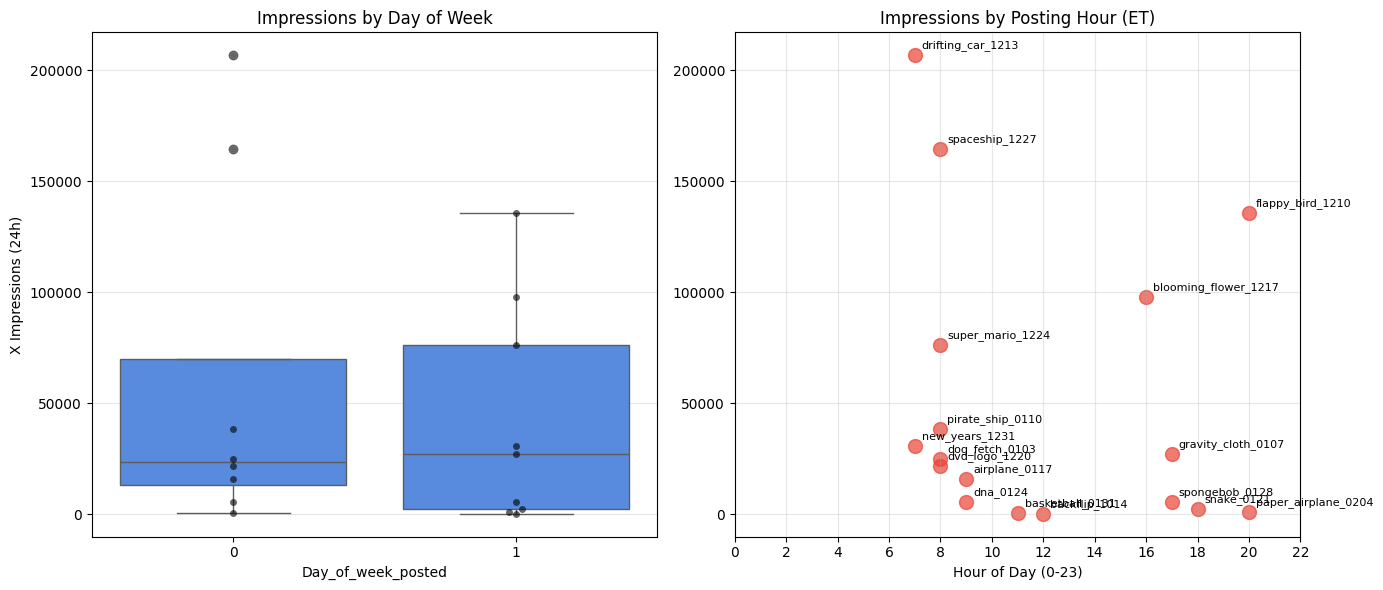

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Day of Week vs Impressions (Box Plot)
# Assuming 0=Monday, 6=Sunday. Adjust labels if your encoding differs.
sns.boxplot(x='Day_of_week_posted', y='X_Impressions_24h', data=exp_df, ax=axes[0], color='#4285F4')
sns.swarmplot(x='Day_of_week_posted', y='X_Impressions_24h', data=exp_df, ax=axes[0], color='black', alpha=0.6)
axes[0].set_title('Impressions by Day of Week')
axes[0].set_ylabel('X Impressions (24h)')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Posting Hour vs Impressions (Scatter Plot)
axes[1].scatter(exp_df['Time_posted_X_hour'], exp_df['X_Impressions_24h'], color='#EA4335', s=100, alpha=0.7)
# Annotate points to see which experiments are the outliers
for i, txt in enumerate(exp_df['Experiment ID']):
    axes[1].annotate(txt, (exp_df['Time_posted_X_hour'].iloc[i], exp_df['X_Impressions_24h'].iloc[i]),
                     fontsize=8, xytext=(5,5), textcoords='offset points')
axes[1].set_title('Impressions by Posting Hour (ET)')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Is the song style correlated with X impressions?

--- Song Style Frequency ---
Song_style
hip hop, pop                                                                                                                                        15
Trap, Southern hip-hop, Atlanta rap, Melodic rap, Gangsta rap, Modern hip-hop, Street rap, Drill-influenced rap, Bass-heavy rap, Minimalist trap     2
Name: count, dtype: int64

--- Kruskal-Wallis H-test ---
H = 4.361, p = 0.0368
*** SIGNIFICANT difference between styles ***



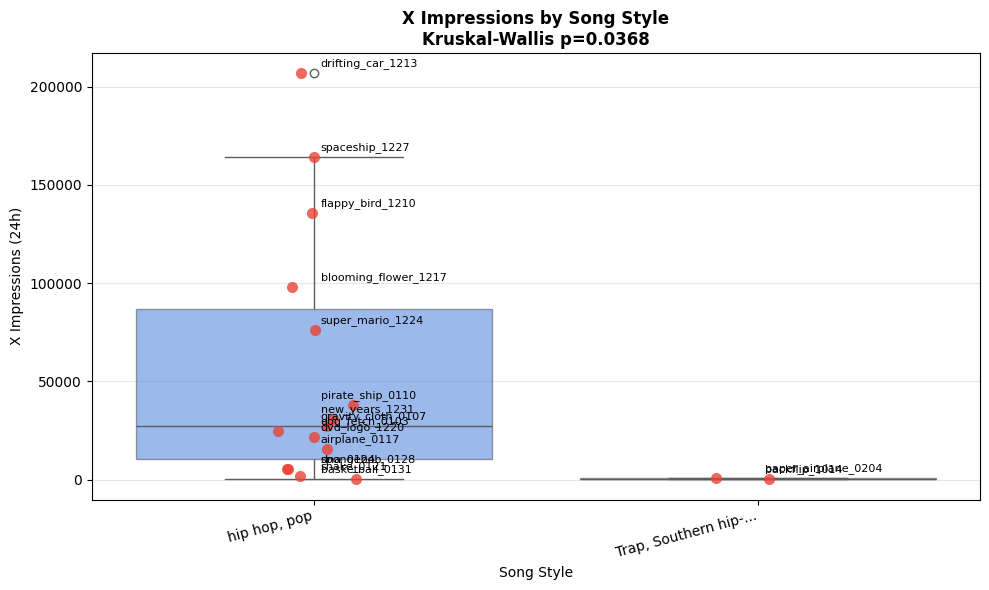

In [130]:
from scipy.stats import kruskal
import textwrap

# Print the value counts to see how many experiments use each style
print("--- Song Style Frequency ---")
print(exp_df['Song_style'].value_counts())

# Shorten the labels for a cleaner plot (some descriptions are very long)
exp_df['Song_style_short'] = exp_df['Song_style'].apply(
    lambda x: textwrap.shorten(str(x), width=25, placeholder="...")
)

# Extract groups for the statistical test
styles = exp_df['Song_style'].unique()
groups = [exp_df[exp_df['Song_style'] == style]['X_Impressions_24h'].values for style in styles]

# Run Kruskal-Wallis test (non-parametric ANOVA)
if len(groups) > 1:
    stat, p = kruskal(*groups)
    print(f"\n--- Kruskal-Wallis H-test ---\nH = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("*** SIGNIFICANT difference between styles ***\n")
    else:
        print("(Not significant - styles perform similarly)\n")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Create box plot and overlay individual points
sns.boxplot(x='Song_style_short', y='X_Impressions_24h', data=exp_df, ax=ax, color='#4285F4', boxprops=dict(alpha=0.6))
sns.stripplot(x='Song_style_short', y='X_Impressions_24h', data=exp_df, ax=ax, color='#EA4335', size=8, alpha=0.8)

# Annotate points with the experiment ID
unique_shorts = exp_df['Song_style_short'].unique().tolist()
for i, row in exp_df.iterrows():
    x_pos = unique_shorts.index(row['Song_style_short'])
    ax.annotate(row['Experiment ID'], (x_pos, row['X_Impressions_24h']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_title(f'X Impressions by Song Style\nKruskal-Wallis p={p:.4f}', fontweight='bold')
ax.set_ylabel('X Impressions (24h)')
ax.set_xlabel('Song Style')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

The amound of experiments with that song style and the tendency of the number of impressions at the end of the experiment lifecycle, might make the findings irrelevant

#### Visual and Experiment tipe correlated to X impressions?

--- Statistical Analysis ---

Visual Type vs Impressions:
  Point-Biserial r: 0.213 (p=0.411)
  Mann-Whitney U:   33.0 (p=0.461)
  Mean (1=Simple): 57,510
  Mean (0=Complex): 26,392

Experiment Type vs Impressions:
  Point-Biserial r: 0.030 (p=0.910)
  Mann-Whitney U:   24.0 (p=0.865)
  Mean (1=Game): 53,498
  Mean (0=Simulation): 49,170


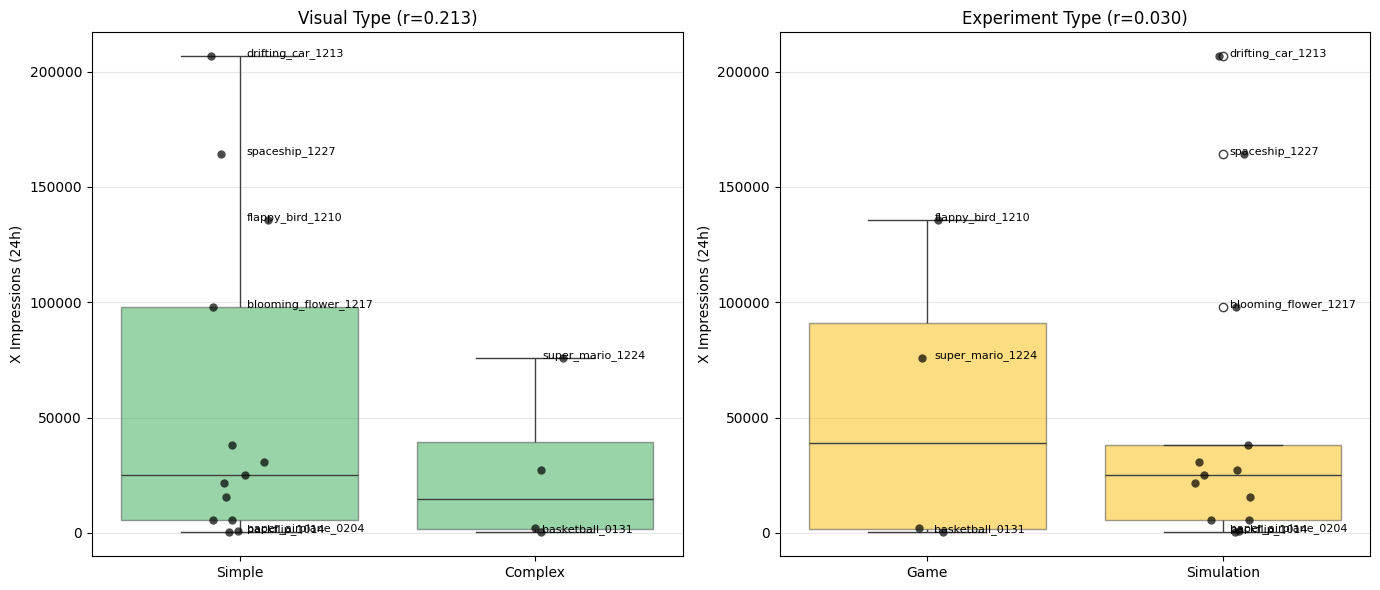

In [132]:
from scipy.stats import pointbiserialr, mannwhitneyu

# Configuration for the analysis
analyses = [
    {
        'col': 'Visual_Type',
        'label': 'Visual Type',
        'mapping': {1: 'Simple', 0: 'Complex'},
        'color': '#34A853'
    },
    {
        'col': 'Experiment_Type',
        'label': 'Experiment Type',
        'mapping': {1: 'Game', 0: 'Simulation'},
        'color': '#FBBC04'
    }
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

print("--- Statistical Analysis ---")

for ax, analysis in zip(axes, analyses):
    col = analysis['col']

    # 1. Calculate Correlation (Point-Biserial)
    # We drop NA just in case, though your info says non-null
    clean_data = exp_df[[col, 'X_Impressions_24h']].dropna()
    r, p_corr = pointbiserialr(clean_data[col], clean_data['X_Impressions_24h'])

    # 2. Compare Groups (Mann-Whitney U Test)
    group1 = clean_data[clean_data[col] == 1]['X_Impressions_24h']
    group0 = clean_data[clean_data[col] == 0]['X_Impressions_24h']
    u_stat, p_mann = mannwhitneyu(group1, group0)

    # Print Stats
    print(f"\n{analysis['label']} vs Impressions:")
    print(f"  Point-Biserial r: {r:.3f} (p={p_corr:.3f})")
    print(f"  Mann-Whitney U:   {u_stat:.1f} (p={p_mann:.3f})")
    print(f"  Mean (1={analysis['mapping'][1]}): {group1.mean():,.0f}")
    print(f"  Mean (0={analysis['mapping'][0]}): {group0.mean():,.0f}")

    # 3. Plotting
    # Create a temporary column for readable labels
    plot_df = exp_df.copy()
    plot_df['Label'] = plot_df[col].map(analysis['mapping'])

    sns.boxplot(x='Label', y='X_Impressions_24h', data=plot_df, ax=ax,
                order=[analysis['mapping'][1], analysis['mapping'][0]],
                boxprops=dict(alpha=0.5, facecolor=analysis['color']))

    sns.stripplot(x='Label', y='X_Impressions_24h', data=plot_df, ax=ax,
                  order=[analysis['mapping'][1], analysis['mapping'][0]],
                  color='black', size=6, alpha=0.7)

    # Annotate outliers/points
    for i, row in plot_df.iterrows():
        # strict matching for annotation placement
        label = row['Label']
        x_idx = 0 if label == analysis['mapping'][1] else 1

        # Only annotate if it's an outlier or high value to keep plot clean
        if row['X_Impressions_24h'] > 50000 or row['X_Impressions_24h'] < 1000:
            ax.annotate(row['Experiment ID'], (x_idx, row['X_Impressions_24h']),
                        fontsize=8, xytext=(5, 0), textcoords='offset points')

    ax.set_title(f"{analysis['label']} (r={r:.3f})")
    ax.set_ylabel('X Impressions (24h)')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Correlation with target variable

--- Linear Correlation (Pearson) with X_Impressions_24h ---
                       X_Impressions_24h
X_Likes_24h                        0.955
X_Shares_24h                       0.909
Perf_max                           0.501
Generation_Hour                    0.437
Time_posted_X_minute               0.430
Suno_version                       0.272
Visual_Type                        0.213
YouTube_Likes_24h                  0.045
Experiment_Type                    0.030
Lyrics_words                       0.021
YouTube_Views_24h                  0.005
MaleFemale_song_voice             -0.034
Video_duration_s                  -0.058
PA_mean                           -0.075
Perf_min                          -0.084
Reason_chars_mean                 -0.103
FC_mean                           -0.114
Reason_topkw_rep_mean             -0.121
gemini_fc_mean                    -0.127
Day_of_week_posted                -0.144
Perf_mean                         -0.154
Time_posted_X_hour                -0.1

/tmp/ipython-input-582874259.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[target_col], y=correlations.index, palette=colors)


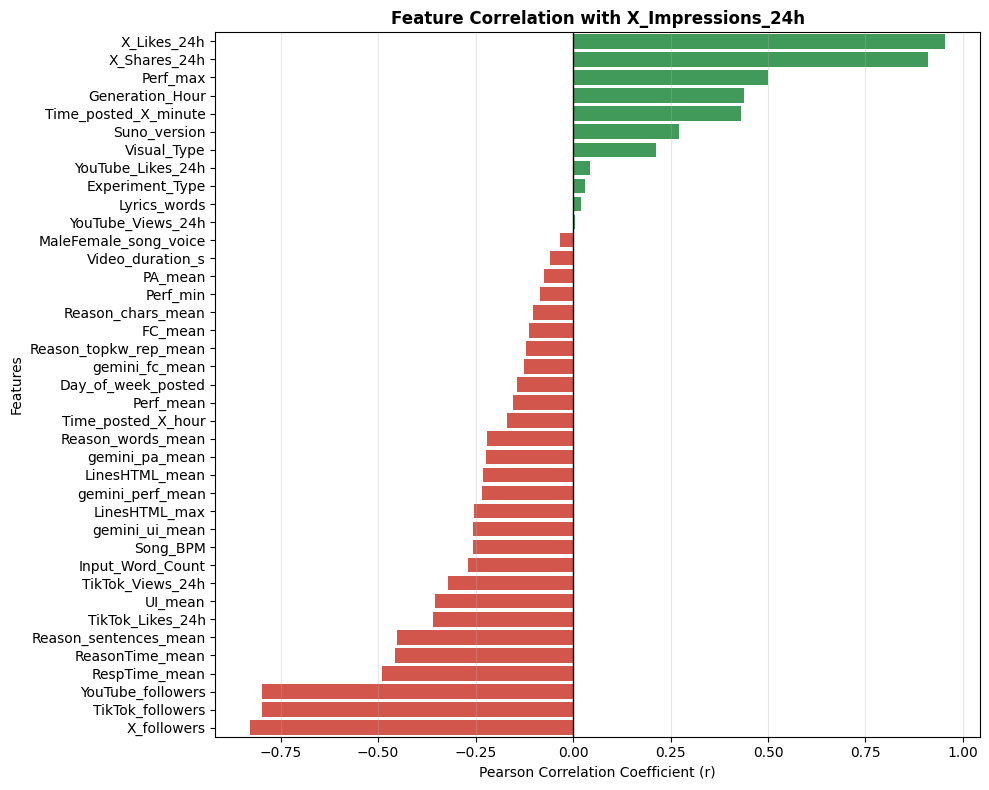

In [127]:
# Define target
target_col = 'X_Impressions_24h'

# Select only numeric columns to avoid Pandas errors during correlation
numeric_df = exp_df.select_dtypes(include=[np.number])

# Calculate correlations against the target, drop the target itself from the index, and sort
correlations = numeric_df.corr()[[target_col]].drop(target_col).sort_values(by=target_col, ascending=False)

# Print the exact values
print(f"--- Linear Correlation (Pearson) with {target_col} ---")
print(correlations.round(3))

# Plotting as a horizontal bar chart for scannability
plt.figure(figsize=(10, 8))
colors = ['#34A853' if val > 0 else '#EA4335' for val in correlations[target_col]]

# Create barplot
sns.barplot(x=correlations[target_col], y=correlations.index, palette=colors)

plt.axvline(x=0, color='black', linewidth=1)
plt.title(f'Feature Correlation with {target_col}', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<a name='1.4'></a>
## 1.4 - Feature Engineering (EDA)

--- Model Results (n=17) ---
R² Score: 0.978
Optimal Alpha (Regularization Strength): 0.0680
Intercept: 9.559

--- Top Features Selected by Lasso ---
YouTube_followers      -0.964820
ReasonTime_mean        -0.830241
Suno_version           -0.395772
TikTok_followers       -0.271233
Reasoning_Ratio_mean   -0.268841
Song_BPM               -0.218119
Video_duration_s       -0.053082
Time_posted_X_minute    0.041469
dtype: float64


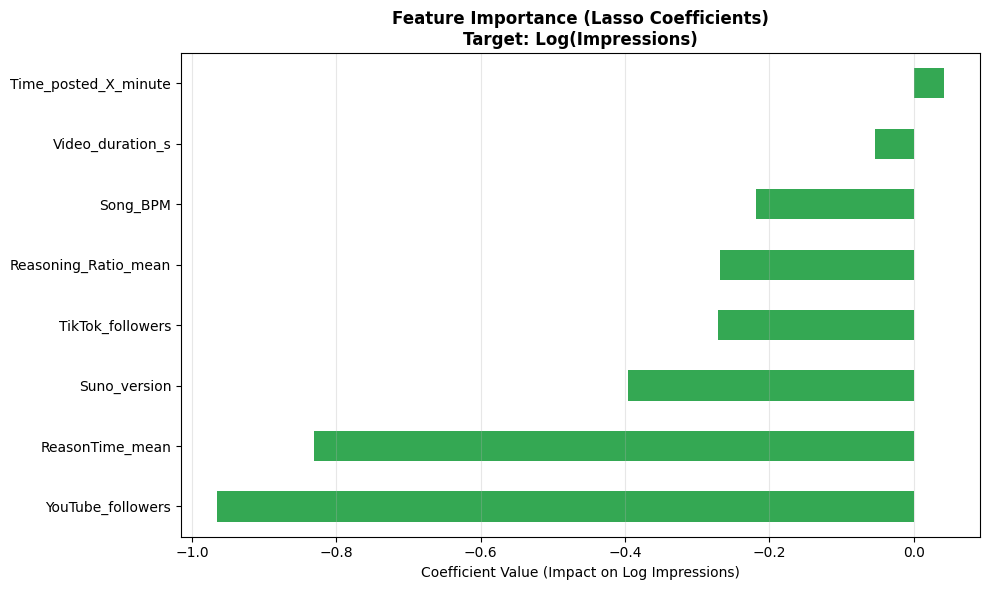

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. Prepare the Machine Learning DataFrame (ml_df) ---

# Define columns that would cause data leakage (post-publication metrics)
leaky_cols = [
    'X_Likes_24h', 'X_Shares_24h',
    'TikTok_Views_24h', 'TikTok_Likes_24h',
    'YouTube_Views_24h', 'YouTube_Likes_24h',
    'Date_Generated', 'Date_posted',
    'Experiment ID', 'Prompt', 'Code_in_Reasoning_unique',
    'Song_style_short' # Text helper column we made earlier
]

# Create ml_df by dropping leaky columns from exp_df
ml_df = exp_df.drop(columns=leaky_cols, errors='ignore').copy()

# --- 2. Feature Engineering ---

# Performance Variance: High max - Low min (Polarizing experiments)
ml_df['Perf_Variance'] = ml_df['Perf_max'] - ml_df['Perf_min']

# Reasoning Ratio: How much time was spent thinking relative to total time?
ml_df['Reasoning_Ratio_mean'] = ml_df['ReasonTime_mean'] / ml_df['RespTime_mean']

# Code Verbosity Ratio: Lines of code per word of prompt
ml_df['Prompt_to_Code_Ratio'] = ml_df['LinesHTML_mean'] / ml_df['Input_Word_Count']

# Drop remaining text/string columns (Song_Key, Song_style, etc.)
string_cols = ml_df.select_dtypes(include=['object']).columns
ml_df = ml_df.drop(columns=string_cols)

# --- 3. Log Transformation of Target ---

# Use log1p to handle the heavy-tailed distribution
ml_df['Log_Impressions'] = np.log1p(ml_df['X_Impressions_24h'])
ml_df = ml_df.drop(columns=['X_Impressions_24h']) # Drop original target

# --- 4. Lasso Regression with LOOCV ---

# Separate X (features) and y (target)
X = ml_df.drop(columns=['Log_Impressions'])
y = ml_df['Log_Impressions']

# Handle any NaN values (fill with median to be safe, though there shouldn't be any)
X = X.fillna(X.median())

# Standardize features (CRITICAL for Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize LassoCV with Leave-One-Out Cross-Validation
# LassoCV automatically tests multiple alphas (regularization strengths)
lasso = LassoCV(cv=LeaveOneOut(), random_state=42, max_iter=10000)

# Fit the model
lasso.fit(X_scaled, y)

# --- 5. Evaluation & Visualization ---

# Predict on the same set (for R2 check) - Note: In LOOCV, the 'score' is the average validation score
y_pred = lasso.predict(X_scaled)
r2 = r2_score(y, y_pred)

print(f"--- Model Results (n={len(ml_df)}) ---")
print(f"R² Score: {r2:.3f}")
print(f"Optimal Alpha (Regularization Strength): {lasso.alpha_:.4f}")
print(f"Intercept: {lasso.intercept_:.3f}")

# Extract Coefficients
coefs = pd.Series(lasso.coef_, index=X.columns)
# Filter out zero coefficients (features the model dropped)
important_coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False)

print("\n--- Top Features Selected by Lasso ---")
print(important_coefs)

# Plot
plt.figure(figsize=(10, 6))
important_coefs.plot(kind='barh', color='#34A853')
plt.title(f'Feature Importance (Lasso Coefficients)\nTarget: Log(Impressions)', fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Log Impressions)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [140]:
# 1. Drop leaky post-publication features and non-predictive metadata
leaky_cols = [
    'X_Likes_24h', 'X_Shares_24h',
    'TikTok_Views_24h', 'TikTok_Likes_24h',
    'YouTube_Views_24h', 'YouTube_Likes_24h',
    'Date_Generated', 'Date_posted',
    'Experiment ID', 'Prompt', 'Code_in_Reasoning_unique',
    'Song_style_short'
]
ml_df = exp_df.drop(columns=leaky_cols, errors='ignore').copy()

# 2. Feature Engineering: Meaningful Ratios and Deltas
ml_df['Perf_Variance'] = ml_df['Perf_max'] - ml_df['Perf_min']
ml_df['Reasoning_Ratio_mean'] = ml_df['ReasonTime_mean'] / ml_df['RespTime_mean']
ml_df['Prompt_to_Code_Ratio'] = ml_df['LinesHTML_mean'] / ml_df['Input_Word_Count']

# 3. Target Definition (Log Transformation)
# We apply log1p to handle the heavy-tailed distribution, then drop the original to prevent leakage
ml_df['Log_Impressions'] = np.log1p(ml_df['X_Impressions_24h'])
ml_df = ml_df.drop(columns=['X_Impressions_24h'])

# 4. Drop remaining string categoricals (models need numbers, not text)
string_cols = ml_df.select_dtypes(include=['object']).columns
ml_df = ml_df.drop(columns=string_cols)

# --- Define what is what for the printout ---
target_col = 'Log_Impressions'
feature_cols = [col for col in ml_df.columns if col != target_col]

print("Feature engineering complete. Target logged.\n")
print("-" * 40)
print(f" TARGET VARIABLE: '{target_col}'")
print(f"   (This represents the log-transformed 24h X Impressions)\n")
print(f" TOTAL CANDIDATE FEATURES: {len(feature_cols)}\n")
print(" FEATURE COLUMNS POOL:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")
print("-" * 40)

Feature engineering complete. Target logged.

----------------------------------------
 TARGET VARIABLE: 'Log_Impressions'
   (This represents the log-transformed 24h X Impressions)

 TOTAL CANDIDATE FEATURES: 36

 FEATURE COLUMNS POOL:
  1. Experiment_Type
  2. Visual_Type
  3. Input_Word_Count
  4. Day_of_week_posted
  5. Time_posted_X_hour
  6. Time_posted_X_minute
  7. X_followers
  8. TikTok_followers
  9. YouTube_followers
  10. Video_duration_s
  11. MaleFemale_song_voice
  12. Song_BPM
  13. Lyrics_words
  14. Suno_version
  15. Perf_mean
  16. Perf_max
  17. Perf_min
  18. PA_mean
  19. FC_mean
  20. UI_mean
  21. LinesHTML_mean
  22. LinesHTML_max
  23. ReasonTime_mean
  24. RespTime_mean
  25. Reason_words_mean
  26. Reason_chars_mean
  27. Reason_sentences_mean
  28. Reason_topkw_rep_mean
  29. gemini_pa_mean
  30. gemini_fc_mean
  31. gemini_ui_mean
  32. gemini_perf_mean
  33. Generation_Hour
  34. Perf_Variance
  35. Reasoning_Ratio_mean
  36. Prompt_to_Code_Ratio
------

<a name='2'></a>
# 2 - Modeling

In [141]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define our final chosen features
features = ['ReasonTime_mean', 'Suno_version', 'Song_BPM', 'Reasoning_Ratio_mean']

X = ml_df[features].fillna(ml_df[features].median())
y = ml_df['Log_Impressions']

# 2. Scale the features (CRITICAL for Ridge regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train and Evaluate using LOOCV
model = Ridge(alpha=1.0, random_state=42)

# Generate out-of-sample predictions for all 17 rows
log_predictions = cross_val_predict(model, X_scaled, y, cv=LeaveOneOut())

# Convert logged predictions and actuals BACK to real impression numbers for evaluation
actual_impressions = np.expm1(y)
predicted_impressions = np.expm1(log_predictions)

# Calculate real-world error
mae = mean_absolute_error(actual_impressions, predicted_impressions)
r2_real = r2_score(actual_impressions, predicted_impressions)

print("--- Model Evaluation (Out-of-Sample) ---")
print(f"Mean Absolute Error: +/- {mae:,.0f} impressions")
print(f"R-squared (Original Scale): {r2_real:.3f}")

# Train the final model on ALL 17 rows for future predictions
final_model = Ridge(alpha=1.0, random_state=42)
final_model.fit(X_scaled, y)

print("\n--- Final Model is Trained and Ready ---")

--- Model Evaluation (Out-of-Sample) ---
Mean Absolute Error: +/- 46,221 impressions
R-squared (Original Scale): -0.331

--- Final Model is Trained and Ready ---


<a name='3'></a>
# 3 - Predictions Playground

In [143]:
# 1. Define the Prediction Function
def predict_impressions(reason_time, suno_ver, bpm, reason_ratio):
    new_data = pd.DataFrame({
        'ReasonTime_mean': [reason_time],
        'Suno_version': [suno_ver],
        'Song_BPM': [bpm],
        'Reasoning_Ratio_mean': [reason_ratio]
    })

    new_scaled = scaler.transform(new_data)
    pred_log = final_model.predict(new_scaled)[0]
    pred_actual = np.expm1(pred_log)

    print("-" * 40)
    print("🔮 IMPRESSION FORECAST")
    print("-" * 40)
    print("INPUT FEATURES:")
    print(f" - Avg Reason Time: {reason_time}s")
    print(f" - Suno Version: {'v4.5' if suno_ver == 1 else 'v5'}")
    print(f" - Song BPM: {bpm}")
    print(f" - Reason Time Ratio: {reason_ratio*100}% of total time")
    print("-" * 40)
    print(f"🎯 PREDICTED X IMPRESSIONS: {pred_actual:,.0f}")
    print(f"   (Model Error Margin: +/- 46,221)")
    print("-" * 40)

# --- Test the Prediction Engine ---
predict_impressions(reason_time=20, suno_ver=0, bpm=100, reason_ratio=0.2)

----------------------------------------
🔮 IMPRESSION FORECAST
----------------------------------------
INPUT FEATURES:
 - Avg Reason Time: 20s
 - Suno Version: v5
 - Song BPM: 100
 - Reason Time Ratio: 20.0% of total time
----------------------------------------
🎯 PREDICTED X IMPRESSIONS: 61,480
   (Model Error Margin: +/- 46,221)
----------------------------------------


In [144]:
import gradio as gr

# 1. Prediction and Visualization Function
def predict_and_visualize(reason_time, suno_ver_str, bpm, reason_ratio):
    # Map the dropdown string back to the binary feature the model expects
    suno_ver = 1 if suno_ver_str == "v4.5" else 0

    # Create the dataframe for scaling
    new_data = pd.DataFrame({
        'ReasonTime_mean': [reason_time],
        'Suno_version': [suno_ver],
        'Song_BPM': [bpm],
        'Reasoning_Ratio_mean': [reason_ratio]
    })

    # Scale and Predict
    new_scaled = scaler.transform(new_data)
    pred_log = final_model.predict(new_scaled)[0]
    pred_actual = np.expm1(pred_log)

    # Floor at 0 just in case the model outputs a massive negative log
    pred_actual = max(0, pred_actual)

    # Create dynamic visual element (Matplotlib plot)
    fig, ax = plt.subplots(figsize=(6, 4))
    categories = ['Historical Median', 'Predicted Impressions']
    values = [25000, pred_actual]
    colors = ['#888888', '#4285F4']

    bars = ax.bar(categories, values, color=colors)
    ax.set_ylabel('X Impressions (24h)')
    ax.set_title('Forecast vs Historical Baseline')

    # Add values on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(values)*0.02),
                f"{height:,.0f}", ha='center', va='bottom', fontweight='bold')

    # Scale y-axis dynamically to fit the text
    ax.set_ylim(0, max(max(values) * 1.2, 35000))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    # Format the text output
    forecast_text = f"{pred_actual:,.0f} Impressions"

    return forecast_text, fig

# 2. Gradio Interface Layout
with gr.Blocks(theme=gr.themes.Soft()) as interface:
    gr.Markdown("# HTML AI Battle: Virality Predictor")

    gr.Markdown("""
    **Algorithm:** Ridge Regression (L2 Penalty)

    **Accuracy (For Dummies):** This model is highly experimental. Because social media algorithms are chaotic and rely heavily on the visual hook and your base follower count (which we removed to test pure model metrics), this predictor will be off by about +/- 46,000 impressions on average. Use this to see how technical stats (like reasoning time) pull the numbers up or down, rather than expecting a perfect forecast.
    """)

    with gr.Row():
        with gr.Column():
            reason_time_input = gr.Slider(minimum=0, maximum=300, value=20, label="Avg Reasoning Time (seconds)")
            suno_ver_input = gr.Dropdown(choices=["v5", "v4.5"], value="v5", label="Suno Version")
            bpm_input = gr.Slider(minimum=60, maximum=180, value=100, label="Song BPM")
            reason_ratio_input = gr.Slider(minimum=0.0, maximum=1.0, value=0.20, label="Reasoning Time Ratio (0 to 1)")

            predict_btn = gr.Button("Predict Impressions", variant="primary")

        with gr.Column():
            output_number = gr.Textbox(label="Predicted Target")
            output_plot = gr.Plot(label="Dynamic Comparison")

    # Link the button to the function
    predict_btn.click(
        fn=predict_and_visualize,
        inputs=[reason_time_input, suno_ver_input, bpm_input, reason_ratio_input],
        outputs=[output_number, output_plot]
    )

# 3. Launch the app inside the notebook
interface.launch(inline=True)

/tmp/ipython-input-1467826258.py:51: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3996e1452edbf9cdf6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<a name='4'></a>
# 4 - Conclusion

**Why AI Compute Doesn't Predict Social Media Reach**

This study analyzed 17 "HTML AI Battle" experiments across five LLMs to see if technical generation metrics, like reasoning time and code length, actually drive views on X, TikTok, and YouTube.

Here is what the data shows about how these models work and what audiences actually watch.

1. **More Compute Does Not Equal Better Quality**
The data shows a clear gap between how long a model thinks and how well it performs.

* The Reasoning Myth: Spending more time reasoning does not lead to better code. For most models, there is no connection between thinking time and the final human score.
* The Gemini Struggle Signal: When Gemini takes longer to think and generate, its scores actually drop (Spearman r = -0.58, p = 0.015). For Gemini, taking a long time is a sign of confusion, not deep thought.
* Model Differences: Grok spent 73.4% of its total time just reasoning, but consistently got the lowest quality scores. GPT went the other way, spending only 25.6% of its time thinking while generating the longest outputs, hitting up to 1,422 lines of code.

2. **AI Judges Are Biased**
Using Gemini as a blind judge showed real problems with having AI grade AI.

* Self-Bias: Gemini consistently scored its own code higher than human judges did (Wilcoxon p=0.037 for Functional Correctness). It preferred its own style even without knowing which model wrote the code.
* Easy Grading: Gemini was much more lenient than humans. It often gave high scores to code that technically worked but completely missed the creative point of the prompt.

3. **Algorithms Do Not Care About Tech Specs**
Trying to predict 24-hour impressions with machine learning models showed how unpredictable social media algorithms are.

* Good Code Does Not Guarantee Views: The models confirmed that social media reach has nothing to do with generation metrics. A perfect 10/10 code execution has the exact same viral potential as a buggy 6/10 output.
* The Timeline Factor: The strongest predictor of virality was actually a negative correlation with the starting follower count (r = -0.828). The massive viral hits, like drifting_car_1213 with 206k impressions, happened early in the project, likely driven by the novelty of the account.
* The Visual Hook Wins: Variables like posting time, day of the week, song BPM, and prompt length had zero impact on predictions. Virality was driven entirely by the visual concept itself and having at least one model generate a standout result.

**Final Takeaway**
We can measure how long an LLM thinks and how much code it writes, but social media algorithms do not care about the underlying compute. They only care about the final visual output. If you want engagement, optimize your prompts for clear, interesting visuals. Making prompts more complex or forcing the AI to reason longer will not help you go viral.

# Appendix: Mathematical Formulations from the Paper

## 1. Weighted Performance Score (Sperf)
$$
S_{\text{perf}} = 0.40 \cdot PA + 0.35 \cdot FC + 0.25 \cdot UI
$$

## 2. Reasoning Efficiency (Er)
$$
E_r = \frac{S_{\text{perf}}}{t_{\text{reason}}}
$$

## 3. Score Vector & Cosine Similarity
Each evaluation is a vector $\mathbf{s}_i = [PA_i, FC_i, UI_i]^\top$.  
Directional agreement between two evaluations:
$$
\cos(\theta) = \frac{\mathbf{s}_a^\top \mathbf{s}_b}{\|\mathbf{s}_a\| \|\mathbf{s}_b\|}
$$

## 4. Eigen-analysis of Metric Alignment
Let $S$ be the centered score matrix (rows = evaluations, columns = PA/FC/UI).  
Covariance matrix:
$$
C = \frac{1}{n-1} S^\top S
$$
Eigendecomposition $C\mathbf{v}_k = \lambda_k \mathbf{v}_k$. The leading eigenvector $\mathbf{v}_1$ and eigenvalue $\lambda_1$ show the dominant quality axis.

In [145]:
from scipy.spatial.distance import cosine

# Use ml_df
df = ml_df if 'ml_df' in globals() else exp_df.copy()

# 1. Weighted Performance Score (Sperf)
df['Sperf'] = (0.40 * df['PA_mean'] +
               0.35 * df['FC_mean'] +
               0.25 * df['UI_mean'])

# 2. Reasoning Efficiency (Er)
df['Reasoning_Efficiency'] = df['Sperf'] / df['ReasonTime_mean']

print("✅ Weighted Sperf and Reasoning Efficiency (Er) calculated.\n")
print(df[['Sperf', 'Reasoning_Efficiency']].describe().round(3))

# 3. Score Vectors & Cosine Similarity Example
score_cols = ['PA_mean', 'FC_mean', 'UI_mean']
score_matrix = df[score_cols].values

# Example: Cosine similarity between first two rows
if len(score_matrix) >= 2:
    vec1 = score_matrix[0]
    vec2 = score_matrix[1]
    cos_sim = 1 - cosine(vec1, vec2)  # scipy cosine returns distance
    print(f"\n📐 Example Cosine Similarity (row 0 vs row 1): {cos_sim:.4f}")

# 4. Eigen-analysis of Covariance (Metric Alignment)
centered = score_matrix - score_matrix.mean(axis=0)
cov_matrix = np.cov(centered.T)  # shape (3,3)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = eigenvalues.argsort()[::-1]  # sort descending
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n🔬 Eigen-analysis of PA/FC/UI covariance:")
for i in range(3):
    print(f"  λ{i+1} = {eigenvalues[i]:.4f} | "
          f"Leading eigenvector v{i+1} = [{eigenvectors[:,i][0]:.3f}, "
          f"{eigenvectors[:,i][1]:.3f}, {eigenvectors[:,i][2]:.3f}]")

print(f"\nDominant quality axis explains {eigenvalues[0]/eigenvalues.sum()*100:.1f}% "
      f"of score variance (λ1 = {eigenvalues[0]:.4f})")

✅ Weighted Sperf and Reasoning Efficiency (Er) calculated.

        Sperf  Reasoning_Efficiency
count  17.000                17.000
mean    7.624                 0.221
std     1.259                 0.179
min     5.000                 0.031
25%     6.811                 0.130
50%     7.931                 0.167
75%     8.698                 0.269
max     9.162                 0.808

📐 Example Cosine Similarity (row 0 vs row 1): 0.9994

🔬 Eigen-analysis of PA/FC/UI covariance:
  λ1 = 4.6228 | Leading eigenvector v1 = [-0.629, -0.655, -0.419]
  λ2 = 0.4097 | Leading eigenvector v2 = [-0.483, -0.092, 0.871]
  λ3 = 0.1971 | Leading eigenvector v3 = [-0.609, 0.750, -0.258]

Dominant quality axis explains 88.4% of score variance (λ1 = 4.6228)


* Overall performance is solid: Sperf averages 7.62/10 across 17 experiments (moderate spread, std 1.26).

* Efficiency varies a lot: Reasoning Efficiency averages 0.22 (best case 0.81, worst 0.03), so some runs deliver much more quality per second than others.

* Score “shape” is almost identical: Cosine similarity 0.9994 means rows 0 and 1 trade off PA, FC, and UI in nearly the same proportions.

* One main quality factor dominates: The top eigen-direction explains 88.4% of variance, so PA, FC, and UI mostly rise and fall together.

* UI contributes, but less than PA/FC: PC1 loads strongest on PA and FC, with a smaller (but still meaningful) UI component.

* Eigenvector signs do not matter: Only the relative magnitudes matter, because flipping the sign represents the same direction.
